# Predicción diaria del riesgo de ignición forestal en Galicia

## Modelado y evaluación

Este notebook desarrolla un sistema de estimación del riesgo diario de ignición forestal en Galicia sobre una rejilla espacial de 1 km de resolución.

La unidad de observación es una combinación **celda–día**. Para cada fecha, el modelo genera una puntuación de riesgo para cada celda situada dentro de Galicia.

El estudio sigue las siguientes fases:

1. Auditoría y análisis exploratorio del datacubo.
2. Selección de variables.
3. Construcción de modelos baseline.
4. Entrenamiento de modelos clásicos de aprendizaje automático.
5. Entrenamiento de redes neuronales espaciales y espaciotemporales.
6. Generación de mapas diarios de riesgo.
7. Evaluación final sobre un periodo temporal no utilizado durante el desarrollo.

## División temporal

Para evitar que información futura influya en el entrenamiento, se adopta una división estrictamente temporal:

- **Entrenamiento:** 1 de enero de 2019 – 31 de diciembre de 2021.
- **Validación:** 1 de enero de 2022 – 31 de diciembre de 2022.
- **Test final:** 1 de enero de 2023 – 26 de noviembre de 2023.

El año 2022 se utiliza para seleccionar variables, modelos e hiperparámetros. El año 2023 permanece excluido hasta que la metodología quede completamente fijada.

## Target

La variable objetivo es `target_ignicion`:

- `1`: se registró al menos una ignición oficial en la celda durante el día.
- `0`: no se registró ninguna ignición.

## Contrato predictivo

Se utiliza la meteorología correspondiente al día T para estimar el riesgo del propio día T. Las acumulaciones meteorológicas incluyen información disponible hasta el día T.

Las puntuaciones generadas por los modelos se interpretan inicialmente como **índices relativos de riesgo**, no como probabilidades calibradas.

## Prevención de fuga de información

Quedan excluidas de los predictores:

- `target_ignicion`
- `burned_area_ha`
- `large_fire_500ha`
- `is_near_ignition_25x25_10d`
- `is_galicia`
- identificadores y variables derivadas directamente del target

En particular, `is_near_ignition_25x25_10d` deriva espacial y temporalmente de las igniciones observadas y, por tanto, no puede utilizarse para realizar predicciones.

## Métricas principales

Debido al fuerte desequilibrio entre igniciones y no igniciones, la exactitud no es una métrica adecuada. Se utilizarán principalmente:

- Average Precision.
- Lift respecto a un clasificador aleatorio.
- ROC-AUC como métrica complementaria.
- Recall dentro del 0,1%, 1% y 5% de las celdas con mayor riesgo.
- Average Precision diaria.
- Porcentaje de días con igniciones correctamente detectados.

In [1]:
# =============================================================================
# 0. CONFIGURACIÓN GENERAL Y CARGA DEL DATACUBO DEFINITIVO
# =============================================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import hashlib
import json
import platform
import shutil
import sys
import time
import warnings

import numpy as np
import pandas as pd
import xarray as xr

warnings.filterwarnings("ignore", category=FutureWarning)

# -----------------------------------------------------------------------------
# 0.1. Configuración reproducible
# -----------------------------------------------------------------------------

SEED = 42

TRAIN_START = "2019-01-01"
TRAIN_END = "2021-12-31"

VALIDATION_START = "2022-01-01"
VALIDATION_END = "2022-12-31"

TEST_START = "2023-01-01"
TEST_END = "2023-11-26"

TARGET = "target_ignicion"
MASK_VARIABLE = "is_galicia"

FORBIDDEN_PREDICTORS = [
    "target_ignicion",
    "burned_area_ha",
    "large_fire_500ha",
    "is_near_ignition_25x25_10d",
    "is_galicia",
    "year",
]

# -----------------------------------------------------------------------------
# 0.2. Rutas
# -----------------------------------------------------------------------------

DRIVE_ROOT = Path("/content/drive/MyDrive/TFM")

DATACUBE_DRIVE = (
    DRIVE_ROOT /
    "Datacube/galicia_1km.nc"
)

DATACUBE_LOCAL = Path(
    "/content/galicia_1km.nc"
)

FINAL_RESULTS_DIR = (
    DRIVE_ROOT /
    "ModelingResults/FinalNotebook"
)

DIRECTORIES = {
    "configuration": FINAL_RESULTS_DIR / "00_configuration",
    "exploration": FINAL_RESULTS_DIR / "01_exploration",
    "feature_selection": FINAL_RESULTS_DIR / "02_feature_selection",
    "baselines": FINAL_RESULTS_DIR / "03_baselines",
    "classical_models": FINAL_RESULTS_DIR / "04_classical_models",
    "cnn_2d": FINAL_RESULTS_DIR / "05_cnn_2d",
    "cnn_3d": FINAL_RESULTS_DIR / "06_cnn_3d",
    "ensembles": FINAL_RESULTS_DIR / "07_ensembles",
    "final_test": FINAL_RESULTS_DIR / "08_final_test_2023",
    "figures": FINAL_RESULTS_DIR / "figures",
    "tables": FINAL_RESULTS_DIR / "tables",
}

for directory in DIRECTORIES.values():
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("=" * 80)
print("CONFIGURACIÓN DEL PROYECTO")
print("=" * 80)

print(f"Datacubo en Drive: {DATACUBE_DRIVE}")
print(f"Resultados finales: {FINAL_RESULTS_DIR}")

if not DATACUBE_DRIVE.exists():
    raise FileNotFoundError(
        "No se ha encontrado el datacubo definitivo en:\n"
        f"{DATACUBE_DRIVE}"
    )

# -----------------------------------------------------------------------------
# 0.3. Copia local
# -----------------------------------------------------------------------------

drive_size = DATACUBE_DRIVE.stat().st_size

copy_required = (
    not DATACUBE_LOCAL.exists()
    or DATACUBE_LOCAL.stat().st_size != drive_size
)

print("\n" + "=" * 80)
print("COPIA LOCAL DEL DATACUBO")
print("=" * 80)

if copy_required:
    print(f"Origen:  {DATACUBE_DRIVE}")
    print(f"Destino: {DATACUBE_LOCAL}")
    print(f"Tamaño:  {drive_size / 1024**3:.2f} GB")
    print("\nCopiando al almacenamiento local...")

    start = time.time()

    shutil.copy2(
        DATACUBE_DRIVE,
        DATACUBE_LOCAL,
    )

    elapsed = (time.time() - start) / 60

    print(
        f"✓ Copia terminada en "
        f"{elapsed:.2f} minutos."
    )
else:
    print("✓ Ya existe una copia local completa.")
    print(f"Ruta:   {DATACUBE_LOCAL}")
    print(f"Tamaño: {drive_size / 1024**3:.2f} GB")

if DATACUBE_LOCAL.stat().st_size != drive_size:
    raise IOError(
        "La copia local no coincide en tamaño con "
        "el archivo almacenado en Drive."
    )

# -----------------------------------------------------------------------------
# 0.4. Huella del archivo
# -----------------------------------------------------------------------------

def calculate_sha256(path, block_size=8 * 1024 * 1024):
    file_hash = hashlib.sha256()

    with open(path, "rb") as file:
        while True:
            block = file.read(block_size)

            if not block:
                break

            file_hash.update(block)

    return file_hash.hexdigest()


print("\nCalculando la huella SHA-256 del datacubo...")
hash_start = time.time()

DATACUBE_SHA256 = calculate_sha256(
    DATACUBE_LOCAL
)

print(f"SHA-256: {DATACUBE_SHA256}")
print(
    f"Tiempo:  {time.time() - hash_start:.1f} s"
)

# -----------------------------------------------------------------------------
# 0.5. Apertura del NetCDF
# -----------------------------------------------------------------------------

if "datacube" in globals():
    try:
        datacube.close()
    except Exception:
        pass

datacube = xr.open_dataset(
    DATACUBE_LOCAL,
    engine="h5netcdf",
    chunks={},
    decode_timedelta=False,
)

# -----------------------------------------------------------------------------
# 0.6. Comprobaciones estructurales
# -----------------------------------------------------------------------------

required_dimensions = {
    "time",
    "y",
    "x",
}

missing_dimensions = (
    required_dimensions
    - set(datacube.dims)
)

if missing_dimensions:
    raise ValueError(
        "Faltan dimensiones obligatorias: "
        f"{sorted(missing_dimensions)}"
    )

required_variables = {
    TARGET,
    MASK_VARIABLE,
}

missing_variables = (
    required_variables
    - set(datacube.data_vars)
)

if missing_variables:
    raise ValueError(
        "Faltan variables obligatorias: "
        f"{sorted(missing_variables)}"
    )

time_index = pd.DatetimeIndex(
    datacube.time.values
)

if not time_index.is_monotonic_increasing:
    raise ValueError(
        "La coordenada temporal no está ordenada."
    )

if time_index.has_duplicates:
    raise ValueError(
        "La coordenada temporal contiene fechas duplicadas."
    )

# Solo se carga la máscara territorial.
# En esta celda no se consulta el target de 2023.
galicia_mask = (
    datacube[MASK_VARIABLE]
    .load()
    .values
    .astype(bool)
)

number_galicia_cells = int(
    galicia_mask.sum()
)

# -----------------------------------------------------------------------------
# 0.7. Inventario de variables
# -----------------------------------------------------------------------------

inventory_rows = []

for variable_name, data_array in datacube.data_vars.items():
    dimensions = tuple(data_array.dims)

    if dimensions == ("y", "x"):
        variable_type = "static"
    elif dimensions == ("time",):
        variable_type = "temporal"
    elif set(dimensions) == {"time", "y", "x"}:
        variable_type = "spatiotemporal"
    else:
        variable_type = "other"

    if variable_name in FORBIDDEN_PREDICTORS:
        modeling_role = "excluded"
    else:
        modeling_role = "candidate_predictor"

    inventory_rows.append({
        "variable": variable_name,
        "dimensions": str(dimensions),
        "dtype": str(data_array.dtype),
        "variable_type": variable_type,
        "modeling_role": modeling_role,
        "units": data_array.attrs.get("units", ""),
        "long_name": data_array.attrs.get("long_name", ""),
        "description": data_array.attrs.get("description", ""),
    })

variable_inventory = (
    pd.DataFrame(inventory_rows)
    .sort_values(
        ["variable_type", "variable"]
    )
    .reset_index(drop=True)
)

INVENTORY_PATH = (
    DIRECTORIES["configuration"] /
    "datacube_variable_inventory.csv"
)

variable_inventory.to_csv(
    INVENTORY_PATH,
    index=False,
)

# -----------------------------------------------------------------------------
# 0.8. Guardar configuración inicial
# -----------------------------------------------------------------------------

project_configuration = {
    "project":
        "Daily wildfire ignition risk in Galicia",
    "datacube_drive_path":
        str(DATACUBE_DRIVE),
    "datacube_local_path":
        str(DATACUBE_LOCAL),
    "datacube_size_bytes":
        int(drive_size),
    "datacube_sha256":
        DATACUBE_SHA256,
    "target":
        TARGET,
    "mask_variable":
        MASK_VARIABLE,
    "training_period": {
        "start": TRAIN_START,
        "end": TRAIN_END,
    },
    "validation_period": {
        "start": VALIDATION_START,
        "end": VALIDATION_END,
    },
    "test_period": {
        "start": TEST_START,
        "end": TEST_END,
    },
    "test_2023_used":
        False,
    "seed":
        SEED,
    "forbidden_predictors":
        FORBIDDEN_PREDICTORS,
    "primary_metric":
        "average_precision",
    "primary_operational_metric":
        "daily pooled recall at top 1 percent",
    "score_interpretation":
        "Relative risk score; not initially calibrated",
    "software": {
        "python": sys.version,
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "xarray": xr.__version__,
    },
}

CONFIGURATION_PATH = (
    DIRECTORIES["configuration"] /
    "project_configuration.json"
)

with open(
    CONFIGURATION_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        project_configuration,
        file,
        ensure_ascii=False,
        indent=2,
    )

# -----------------------------------------------------------------------------
# 0.9. Resumen
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("ESTRUCTURA DEL DATACUBO DEFINITIVO")
print("=" * 80)

print(f"\nDimensiones:")
for dimension, size in datacube.sizes.items():
    print(f"  {dimension:<10}: {size:,}")

print(f"\nPeriodo completo:")
print(
    f"  {time_index.min().date()} → "
    f"{time_index.max().date()}"
)

print(f"\nCeldas de Galicia: {number_galicia_cells:,}")
print(f"Variables de datos: {len(datacube.data_vars):,}")
print(f"Coordenadas: {len(datacube.coords):,}")

type_summary = (
    variable_inventory
    .groupby(
        ["variable_type", "modeling_role"]
    )
    .size()
    .rename("number_of_variables")
    .reset_index()
)

print("\nResumen de variables:")
display(type_summary)

print("\nInventario completo:")
display(
    variable_inventory[[
        "variable",
        "variable_type",
        "dimensions",
        "dtype",
        "units",
        "modeling_role",
    ]]
)

print("\nArchivos guardados:")
print(f"  Configuración: {CONFIGURATION_PATH}")
print(f"  Inventario:    {INVENTORY_PATH}")

print("\n✓ Datacubo definitivo abierto correctamente.")
print("✓ Configuración inicial guardada en Drive.")
print("✓ El target de 2023 todavía no se ha analizado.")

Mounted at /content/drive
CONFIGURACIÓN DEL PROYECTO
Datacubo en Drive: /content/drive/MyDrive/TFM/Datacube/galicia_1km.nc
Resultados finales: /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook

COPIA LOCAL DEL DATACUBO
Origen:  /content/drive/MyDrive/TFM/Datacube/galicia_1km.nc
Destino: /content/galicia_1km.nc
Tamaño:  2.28 GB

Copiando al almacenamiento local...
✓ Copia terminada en 0.66 minutos.

Calculando la huella SHA-256 del datacubo...
SHA-256: 969dc060b3b9f646e5c68ff9a1cd945c47a7160e1a1a1e7e39511def3629f300
Tiempo:  11.6 s

ESTRUCTURA DEL DATACUBO DEFINITIVO

Dimensiones:
  y         : 225
  x         : 203
  time      : 1,791

Periodo completo:
  2019-01-01 → 2023-11-26

Celdas de Galicia: 29,601
Variables de datos: 52
Coordenadas: 3

Resumen de variables:


,variable_type,modeling_role,number_of_variables
0,spatiotemporal,candidate_predictor,19
1,spatiotemporal,excluded,4
2,static,candidate_predictor,28
3,static,excluded,1



Inventario completo:


,variable,variable_type,dimensions,dtype,units,modeling_role
0,burned_area_ha,spatiotemporal,"('time', 'y', 'x')",float32,ha,excluded
1,is_near_ignition_25x25_10d,spatiotemporal,"('time', 'y', 'x')",uint8,1,excluded
2,large_fire_500ha,spatiotemporal,"('time', 'y', 'x')",float32,1,excluded
3,precipitation_sum,spatiotemporal,"('time', 'y', 'x')",float32,mm,candidate_predictor
4,precipitation_sum_14d,spatiotemporal,"('time', 'y', 'x')",float32,mm,candidate_predictor
5,precipitation_sum_30d,spatiotemporal,"('time', 'y', 'x')",float32,mm,candidate_predictor
6,precipitation_sum_3d,spatiotemporal,"('time', 'y', 'x')",float32,mm,candidate_predictor
7,precipitation_sum_7d,spatiotemporal,"('time', 'y', 'x')",float32,mm,candidate_predictor
8,relative_humidity_mean,spatiotemporal,"('time', 'y', 'x')",float32,%,candidate_predictor
9,relative_humidity_mean_7d,spatiotemporal,"('time', 'y', 'x')",float32,%,candidate_predictor



Archivos guardados:
  Configuración: /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/00_configuration/project_configuration.json
  Inventario:    /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/00_configuration/datacube_variable_inventory.csv

✓ Datacubo definitivo abierto correctamente.
✓ Configuración inicial guardada en Drive.
✓ El target de 2023 todavía no se ha analizado.


## Resultado de la carga inicial

El datacubo se copia desde Google Drive al almacenamiento local de Colab para evitar interrupciones durante lecturas intensivas del archivo NetCDF.

La huella SHA-256 permite identificar de forma inequívoca la versión del datacubo empleada en el análisis. Esto mejora la reproducibilidad y evita mezclar resultados procedentes de distintas versiones del archivo.

En esta primera fase únicamente se inspecciona la estructura del datacubo y se carga la máscara territorial. No se analiza todavía la distribución del target y no se consulta el resultado correspondiente a 2023.

El inventario de variables y la configuración experimental quedan guardados permanentemente en Google Drive. Las siguientes secciones utilizarán estos archivos como punto de referencia.

# 1. Auditoría de calidad del datacubo

Antes de realizar el análisis exploratorio y entrenar los modelos, se comprueba la integridad de las variables incluidas en el datacubo.

La auditoría comprende:

- identificación formal de predictores estáticos y dinámicos;
- detección de valores ausentes o infinitos;
- comprobación de rangos y varianza;
- validación de las fracciones de orientación y cobertura del suelo;
- comprobación de la descomposición de la red viaria;
- revisión de relaciones físicas básicas entre variables meteorológicas;
- validación del carácter binario y completo del target;
- recuento de igniciones en entrenamiento y validación.

Para preservar el carácter independiente del test final, las variables dinámicas y el target se auditan únicamente durante 2019–2022. No se analiza todavía la distribución correspondiente a 2023.

In [2]:
# =============================================================================
# 1. AUDITORÍA DE CALIDAD DEL DATACUBO
# =============================================================================

import gc
import json
import time

import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 1.1. Clasificación formal de variables
# -----------------------------------------------------------------------------

STATIC_PREDICTORS = [
    variable
    for variable in datacube.data_vars
    if datacube[variable].dims == ("y", "x")
    and variable not in FORBIDDEN_PREDICTORS
]

DYNAMIC_PREDICTORS = [
    variable
    for variable in datacube.data_vars
    if set(datacube[variable].dims) == {"time", "y", "x"}
    and variable not in FORBIDDEN_PREDICTORS
]

CANDIDATE_PREDICTORS = (
    STATIC_PREDICTORS
    + DYNAMIC_PREDICTORS
)

DEVELOPMENT_END = VALIDATION_END

development_cube = datacube.sel(
    time=slice(TRAIN_START, DEVELOPMENT_END)
)

development_dates = pd.DatetimeIndex(
    development_cube.time.values
)

print("=" * 80)
print("PREDICTORES CANDIDATOS")
print("=" * 80)

print(f"\nPeriodo auditado:       "
      f"{development_dates.min().date()} → "
      f"{development_dates.max().date()}")
print(f"Días auditados:         {len(development_dates):,}")
print(f"Predictores estáticos:  {len(STATIC_PREDICTORS)}")
print(f"Predictores dinámicos:  {len(DYNAMIC_PREDICTORS)}")
print(f"Predictores totales:    {len(CANDIDATE_PREDICTORS)}")

print("\nPredictores estáticos:")
for number, feature in enumerate(
    STATIC_PREDICTORS,
    start=1,
):
    print(f"{number:2d}. {feature}")

print("\nPredictores dinámicos:")
for number, feature in enumerate(
    DYNAMIC_PREDICTORS,
    start=1,
):
    print(f"{number:2d}. {feature}")

# -----------------------------------------------------------------------------
# 1.2. Estadísticos de calidad
# -----------------------------------------------------------------------------

quality_rows = []

print("\n" + "=" * 80)
print("AUDITORÍA NUMÉRICA")
print("=" * 80)

print("\nVariables estáticas...")

for number, feature in enumerate(
    STATIC_PREDICTORS,
    start=1,
):
    values = (
        datacube[feature]
        .load()
        .values[galicia_mask]
    )

    finite_mask = np.isfinite(values)
    finite_values = values[finite_mask]

    quality_rows.append({
        "feature": feature,
        "feature_type": "static",
        "audited_period": "constant",
        "number_of_values": values.size,
        "missing_values": int(np.isnan(values).sum()),
        "infinite_values": int(np.isinf(values).sum()),
        "minimum": (
            float(finite_values.min())
            if finite_values.size else np.nan
        ),
        "maximum": (
            float(finite_values.max())
            if finite_values.size else np.nan
        ),
        "mean": (
            float(finite_values.mean())
            if finite_values.size else np.nan
        ),
        "standard_deviation": (
            float(finite_values.std())
            if finite_values.size else np.nan
        ),
        "zero_fraction": (
            float(np.mean(finite_values == 0))
            if finite_values.size else np.nan
        ),
    })

    print(
        f"[{number:2d}/{len(STATIC_PREDICTORS)}] "
        f"{feature:<40} ✓"
    )

    del values, finite_mask, finite_values

print("\nVariables dinámicas de 2019–2022...")

for number, feature in enumerate(
    DYNAMIC_PREDICTORS,
    start=1,
):
    start = time.time()

    values = (
        development_cube[feature]
        .transpose("time", "y", "x")
        .load()
        .values[:, galicia_mask]
    )

    finite_mask = np.isfinite(values)
    finite_values = values[finite_mask]

    quality_rows.append({
        "feature": feature,
        "feature_type": "dynamic",
        "audited_period": "2019-01-01 to 2022-12-31",
        "number_of_values": values.size,
        "missing_values": int(np.isnan(values).sum()),
        "infinite_values": int(np.isinf(values).sum()),
        "minimum": (
            float(finite_values.min())
            if finite_values.size else np.nan
        ),
        "maximum": (
            float(finite_values.max())
            if finite_values.size else np.nan
        ),
        "mean": (
            float(finite_values.mean())
            if finite_values.size else np.nan
        ),
        "standard_deviation": (
            float(finite_values.std())
            if finite_values.size else np.nan
        ),
        "zero_fraction": (
            float(np.mean(finite_values == 0))
            if finite_values.size else np.nan
        ),
    })

    elapsed = time.time() - start

    print(
        f"[{number:2d}/{len(DYNAMIC_PREDICTORS)}] "
        f"{feature:<40} {elapsed:6.1f} s"
    )

    del values, finite_mask, finite_values
    gc.collect()

quality_summary = pd.DataFrame(quality_rows)

QUALITY_PATH = (
    DIRECTORIES["configuration"] /
    "predictor_quality_2019_2022.csv"
)

quality_summary.to_csv(
    QUALITY_PATH,
    index=False,
)

# -----------------------------------------------------------------------------
# 1.3. Comprobaciones estructurales
# -----------------------------------------------------------------------------

check_rows = []


def register_check(
    check,
    passed,
    observed_value,
    criterion,
):
    check_rows.append({
        "check": check,
        "passed": bool(passed),
        "observed_value": float(observed_value),
        "criterion": criterion,
    })


# Orientaciones: deben sumar aproximadamente uno.
aspect_features = [
    feature
    for feature in STATIC_PREDICTORS
    if feature.startswith("aspect_")
]

aspect_sum = np.zeros(
    number_galicia_cells,
    dtype=np.float64,
)

for feature in aspect_features:
    aspect_sum += (
        datacube[feature]
        .load()
        .values[galicia_mask]
    )

aspect_maximum_error = float(
    np.max(np.abs(aspect_sum - 1))
)

register_check(
    check="Aspect fractions sum to one",
    passed=aspect_maximum_error <= 1e-5,
    observed_value=aspect_maximum_error,
    criterion="maximum absolute error <= 1e-5",
)

del aspect_sum

# Coberturas: deben sumar aproximadamente uno.
landcover_features = [
    "artificial",
    "agriculture",
    "broadleaf_forest",
    "coniferous_forest",
    "mixed_forest",
    "scrub",
    "open_spaces",
    "wetlands",
    "water",
]

landcover_sum = np.zeros(
    number_galicia_cells,
    dtype=np.float64,
)

for feature in landcover_features:
    landcover_sum += (
        datacube[feature]
        .load()
        .values[galicia_mask]
    )

landcover_maximum_error = float(
    np.max(np.abs(landcover_sum - 1))
)

register_check(
    check="Land-cover fractions sum to one",
    passed=landcover_maximum_error <= 1e-5,
    observed_value=landcover_maximum_error,
    criterion="maximum absolute error <= 1e-5",
)

del landcover_sum

# La longitud total de vías debe coincidir con sus componentes.
road_components = [
    "road_length_main_km",
    "road_length_local_km",
    "road_length_track_km",
    "road_length_other_km",
]

road_total = (
    datacube["road_length_km"]
    .load()
    .values[galicia_mask]
    .astype(np.float64)
)

road_component_sum = np.zeros_like(
    road_total
)

for feature in road_components:
    road_component_sum += (
        datacube[feature]
        .load()
        .values[galicia_mask]
    )

road_maximum_error = float(
    np.max(
        np.abs(
            road_total
            - road_component_sum
        )
    )
)

register_check(
    check="Road components sum to total road length",
    passed=road_maximum_error <= 1e-4,
    observed_value=road_maximum_error,
    criterion="maximum absolute error <= 1e-4 km",
)

del road_total, road_component_sum

# Todas las fracciones deben encontrarse entre cero y uno.
fraction_features = (
    aspect_features
    + landcover_features
    + [
        "building_area_fraction",
        "residential_area_fraction",
    ]
)

fraction_violations = 0

for feature in fraction_features:
    values = (
        datacube[feature]
        .load()
        .values[galicia_mask]
    )

    fraction_violations += int(
        ((values < -1e-6) | (values > 1 + 1e-6)).sum()
    )

    del values

register_check(
    check="All fractions lie within zero and one",
    passed=fraction_violations == 0,
    observed_value=fraction_violations,
    criterion="number of violations = 0",
)

# Las longitudes de vías no pueden ser negativas.
negative_road_values = 0

for feature in [
    "road_length_km",
    *road_components,
]:
    values = (
        datacube[feature]
        .load()
        .values[galicia_mask]
    )

    negative_road_values += int(
        (values < -1e-6).sum()
    )

    del values

register_check(
    check="Road lengths are non-negative",
    passed=negative_road_values == 0,
    observed_value=negative_road_values,
    criterion="number of negative values = 0",
)

# -----------------------------------------------------------------------------
# 1.4. Relaciones meteorológicas básicas
# -----------------------------------------------------------------------------

def load_development_variable(feature):
    return (
        development_cube[feature]
        .transpose("time", "y", "x")
        .load()
        .values[:, galicia_mask]
        .astype(np.float32)
    )


# Temperatura mínima <= media <= máxima.
temperature_min = load_development_variable(
    "temperature_min"
)
temperature_mean = load_development_variable(
    "temperature_mean"
)
temperature_max = load_development_variable(
    "temperature_max"
)

temperature_order_violations = int(
    (
        (temperature_min > temperature_mean + 1e-4)
        | (temperature_mean > temperature_max + 1e-4)
    ).sum()
)

register_check(
    check="Temperature minimum <= mean <= maximum",
    passed=temperature_order_violations == 0,
    observed_value=temperature_order_violations,
    criterion="number of violations = 0",
)

del temperature_min, temperature_mean

temperature_max_afternoon = load_development_variable(
    "temperature_max_12_18h"
)

afternoon_temperature_violations = int(
    (
        temperature_max_afternoon
        > temperature_max + 1e-4
    ).sum()
)

register_check(
    check="Afternoon maximum <= daily maximum temperature",
    passed=afternoon_temperature_violations == 0,
    observed_value=afternoon_temperature_violations,
    criterion="number of violations = 0",
)

del temperature_max, temperature_max_afternoon
gc.collect()

# Humedad relativa dentro de [0, 100].
humidity_features = [
    "relative_humidity_mean",
    "relative_humidity_min",
    "relative_humidity_min_12_18h",
    "relative_humidity_mean_7d",
]

humidity_violations = 0

for feature in humidity_features:
    values = load_development_variable(feature)

    humidity_violations += int(
        ((values < -1e-4) | (values > 100 + 1e-4)).sum()
    )

    del values
    gc.collect()

register_check(
    check="Relative humidity lies within zero and 100 percent",
    passed=humidity_violations == 0,
    observed_value=humidity_violations,
    criterion="number of violations = 0",
)

# VPD no negativo.
vpd_violations = 0

for feature in [
    "vpd_mean",
    "vpd_max_12_18h",
]:
    values = load_development_variable(feature)

    vpd_violations += int(
        (values < -1e-6).sum()
    )

    del values
    gc.collect()

register_check(
    check="Vapour-pressure deficit is non-negative",
    passed=vpd_violations == 0,
    observed_value=vpd_violations,
    criterion="number of negative values = 0",
)

# Las acumulaciones de precipitación deben ser crecientes.
precipitation_order = [
    "precipitation_sum",
    "precipitation_sum_3d",
    "precipitation_sum_7d",
    "precipitation_sum_14d",
    "precipitation_sum_30d",
]

precipitation_violations = 0

previous_values = load_development_variable(
    precipitation_order[0]
)

for feature in precipitation_order[1:]:
    current_values = load_development_variable(
        feature
    )

    precipitation_violations += int(
        (
            previous_values
            > current_values + 1e-4
        ).sum()
    )

    del previous_values
    previous_values = current_values
    gc.collect()

del previous_values

register_check(
    check="Precipitation accumulations are monotonically increasing",
    passed=precipitation_violations == 0,
    observed_value=precipitation_violations,
    criterion="number of violations = 0",
)

structural_checks = pd.DataFrame(
    check_rows
)

CHECKS_PATH = (
    DIRECTORIES["configuration"] /
    "datacube_structural_checks.csv"
)

structural_checks.to_csv(
    CHECKS_PATH,
    index=False,
)

# -----------------------------------------------------------------------------
# 1.5. Auditoría del target: solo entrenamiento y validación
# -----------------------------------------------------------------------------

target_rows = []

for period_name, start_date, end_date in [
    ("training", TRAIN_START, TRAIN_END),
    ("validation", VALIDATION_START, VALIDATION_END),
]:
    target_values = (
        datacube[TARGET]
        .sel(time=slice(start_date, end_date))
        .transpose("time", "y", "x")
        .load()
        .values[:, galicia_mask]
    )

    number_values = target_values.size
    missing_values = int(
        np.isnan(target_values).sum()
    )
    finite_values = target_values[
        np.isfinite(target_values)
    ]

    non_binary_values = int(
        (~np.isin(finite_values, [0, 1])).sum()
    )

    positive_values = int(
        (finite_values == 1).sum()
    )

    target_rows.append({
        "period": period_name,
        "start_date": start_date,
        "end_date": end_date,
        "number_of_days":
            datacube.sel(
                time=slice(start_date, end_date)
            ).sizes["time"],
        "number_of_cell_days": number_values,
        "missing_values": missing_values,
        "non_binary_values": non_binary_values,
        "positive_cell_days": positive_values,
        "negative_cell_days":
            int((finite_values == 0).sum()),
        "prevalence":
            positive_values / len(finite_values),
        "negative_positive_ratio":
            (
                int((finite_values == 0).sum())
                / positive_values
            ),
    })

    del target_values, finite_values
    gc.collect()

target_audit = pd.DataFrame(
    target_rows
)

TARGET_AUDIT_PATH = (
    DIRECTORIES["configuration"] /
    "target_audit_training_validation.csv"
)

target_audit.to_csv(
    TARGET_AUDIT_PATH,
    index=False,
)

# -----------------------------------------------------------------------------
# 1.6. Guardar listas de predictores
# -----------------------------------------------------------------------------

predictor_contract = {
    "static_predictors": STATIC_PREDICTORS,
    "dynamic_predictors": DYNAMIC_PREDICTORS,
    "candidate_predictors": CANDIDATE_PREDICTORS,
    "forbidden_predictors": FORBIDDEN_PREDICTORS,
    "number_static_predictors":
        len(STATIC_PREDICTORS),
    "number_dynamic_predictors":
        len(DYNAMIC_PREDICTORS),
    "number_candidate_predictors":
        len(CANDIDATE_PREDICTORS),
    "dynamic_audit_period":
        "2019-01-01 to 2022-12-31",
    "test_2023_used": False,
}

PREDICTOR_CONTRACT_PATH = (
    DIRECTORIES["configuration"] /
    "predictor_contract.json"
)

with open(
    PREDICTOR_CONTRACT_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        predictor_contract,
        file,
        ensure_ascii=False,
        indent=2,
    )

# -----------------------------------------------------------------------------
# 1.7. Resultados
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("RESULTADOS DE CALIDAD")
print("=" * 80)

problematic_features = quality_summary[
    (quality_summary["missing_values"] > 0)
    | (quality_summary["infinite_values"] > 0)
    | (quality_summary["standard_deviation"] == 0)
]

if problematic_features.empty:
    print(
        "\n✓ No se han detectado variables con ausencias, "
        "infinitos o varianza nula."
    )
else:
    print("\nVariables que requieren revisión:")
    display(problematic_features)

print("\nComprobaciones estructurales:")

display(
    structural_checks.style.applymap(
        lambda value: (
            "background-color: #d9ead3"
            if value is True
            else (
                "background-color: #f4cccc"
                if value is False
                else ""
            )
        ),
        subset=["passed"],
    )
)

print("\nAuditoría del target:")

display(
    target_audit.style.format({
        "number_of_cell_days": "{:,.0f}",
        "positive_cell_days": "{:,.0f}",
        "negative_cell_days": "{:,.0f}",
        "prevalence": "{:.8%}",
        "negative_positive_ratio": "{:,.1f}:1",
    })
)

print("\nArchivos guardados:")
print(f"  Calidad:       {QUALITY_PATH}")
print(f"  Comprobaciones:{CHECKS_PATH}")
print(f"  Target:        {TARGET_AUDIT_PATH}")
print(f"  Predictores:   {PREDICTOR_CONTRACT_PATH}")

all_checks_passed = bool(
    structural_checks["passed"].all()
)

print("\n" + "=" * 80)
print("AUDITORÍA TERMINADA")
print("=" * 80)

print(
    f"Comprobaciones superadas: "
    f"{structural_checks['passed'].sum()}/"
    f"{len(structural_checks)}"
)

if all_checks_passed and problematic_features.empty:
    print("✓ El datacubo supera la auditoría inicial.")
else:
    print(
        "⚠ Existen resultados que deben revisarse "
        "antes de continuar."
    )

print("✓ El target de 2023 no se ha consultado.")

PREDICTORES CANDIDATOS

Periodo auditado:       2019-01-01 → 2022-12-31
Días auditados:         1,461
Predictores estáticos:  28
Predictores dinámicos:  19
Predictores totales:    47

Predictores estáticos:
 1. elevation_mean
 2. elevation_std
 3. slope_mean
 4. slope_std
 5. aspect_000_045_fraction
 6. aspect_045_090_fraction
 7. aspect_090_135_fraction
 8. aspect_135_180_fraction
 9. aspect_180_225_fraction
10. aspect_225_270_fraction
11. aspect_270_315_fraction
12. aspect_315_360_fraction
13. artificial
14. agriculture
15. broadleaf_forest
16. coniferous_forest
17. mixed_forest
18. scrub
19. open_spaces
20. wetlands
21. water
22. road_length_km
23. road_length_main_km
24. road_length_local_km
25. road_length_track_km
26. road_length_other_km
27. residential_area_fraction
28. building_area_fraction

Predictores dinámicos:
 1. temperature_mean
 2. temperature_min
 3. temperature_max
 4. temperature_max_12_18h
 5. relative_humidity_mean
 6. relative_humidity_min
 7. relative_humidity_m

,feature,feature_type,audited_period,number_of_values,missing_values,infinite_values,minimum,maximum,mean,standard_deviation,zero_fraction
25,road_length_other_km,static,constant,29601,0,0,0.0,0.0,0.0,0.0,1.0



Comprobaciones estructurales:


,check,passed,observed_value,criterion
0,Aspect fractions sum to one,True,0.000000,maximum absolute error <= 1e-5
1,Land-cover fractions sum to one,True,0.000000,maximum absolute error <= 1e-5
2,Road components sum to total road length,True,0.000002,maximum absolute error <= 1e-4 km
3,All fractions lie within zero and one,True,0.000000,number of violations = 0
4,Road lengths are non-negative,True,0.000000,number of negative values = 0
5,Temperature minimum <= mean <= maximum,True,0.000000,number of violations = 0
6,Afternoon maximum <= daily maximum temperature,True,0.000000,number of violations = 0
7,Relative humidity lies within zero and 100 percent,True,0.000000,number of violations = 0
8,Vapour-pressure deficit is non-negative,True,0.000000,number of negative values = 0
9,Precipitation accumulations are monotonically increasing,True,0.000000,number of violations = 0



Auditoría del target:


,period,start_date,end_date,number_of_days,number_of_cell_days,missing_values,non_binary_values,positive_cell_days,negative_cell_days,prevalence,negative_positive_ratio
0,training,2019-01-01,2021-12-31,1096,"32,442,696",0,0,"4,000","32,438,696",0.01232943%,"8,109.7:1"
1,validation,2022-01-01,2022-12-31,365,"10,804,365",0,0,"1,659","10,802,706",0.01535491%,"6,511.6:1"



Archivos guardados:
  Calidad:       /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/00_configuration/predictor_quality_2019_2022.csv
  Comprobaciones:/content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/00_configuration/datacube_structural_checks.csv
  Target:        /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/00_configuration/target_audit_training_validation.csv
  Predictores:   /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/00_configuration/predictor_contract.json

AUDITORÍA TERMINADA
Comprobaciones superadas: 10/10
⚠ Existen resultados que deben revisarse antes de continuar.
✓ El target de 2023 no se ha consultado.


## Conclusiones de la auditoría de calidad

El datacubo definitivo contiene inicialmente 47 predictores candidatos: 28 variables estáticas y 19 variables espaciotemporales.

La auditoría se realizó sobre las 29.601 celdas situadas dentro de Galicia. Para las variables dinámicas se utilizó exclusivamente el periodo de desarrollo 2019–2022, manteniendo 2023 fuera del análisis.

Los resultados muestran que:

- no existen valores ausentes ni infinitos;
- las variables meteorológicas respetan las relaciones físicas comprobadas;
- las fracciones de orientación suman uno;
- las categorías de cobertura del suelo suman uno;
- todas las fracciones están comprendidas entre cero y uno;
- las longitudes de vías son no negativas;
- la suma de las categorías de vías coincide con la longitud viaria total;
- el target está completo y contiene exclusivamente valores binarios.

La variable `road_length_other_km` presenta un valor igual a cero en todas las celdas de Galicia. Al tener varianza nula, no puede aportar información a ningún modelo y se excluirá del conjunto de predictores. Se mantiene en el datacubo únicamente como parte de la documentación de la clasificación viaria.

Después de esta exclusión quedan **46 predictores candidatos**:

- 27 predictores estáticos.
- 19 predictores dinámicos.

La variable objetivo presenta un desequilibrio muy elevado:

- entrenamiento: 4.000 positivos en 32.442.696 celdas–día;
- validación: 1.659 positivos en 10.804.365 celdas–día;
- prevalencias de aproximadamente 0,0123% y 0,0154%, respectivamente.

Este desequilibrio confirma que la exactitud no será una métrica apropiada. La evaluación deberá centrarse en Average Precision, lift y recall dentro de las áreas clasificadas con mayor riesgo.

# 2. Análisis exploratorio

## 2.1. Distribución temporal de las igniciones

El análisis exploratorio comienza estudiando la distribución temporal del target durante 2019–2022.

Se analizarán:

- el número anual de celdas–día con ignición;
- el número de días con alguna ignición;
- la prevalencia anual;
- la distribución mensual;
- la evolución diaria de las igniciones;
- la suma móvil de igniciones durante 30 días.

El objetivo es identificar estacionalidad, diferencias entre años y periodos de mayor actividad.

En esta fase se analiza únicamente el periodo de entrenamiento y validación. Los datos correspondientes a 2023 permanecen excluidos.

ACTUALIZACIÓN DEL CONTRATO DE PREDICTORES

Variable excluida por varianza nula: road_length_other_km
Predictores estáticos: 27
Predictores dinámicos: 19
Predictores totales:   46

CARGA DEL TARGET DE DESARROLLO
Días cargados:       1,461
Celdas de Galicia:   29,601
Celdas-día:          43,247,061
Positivos:           5,659
Días con igniciones: 870


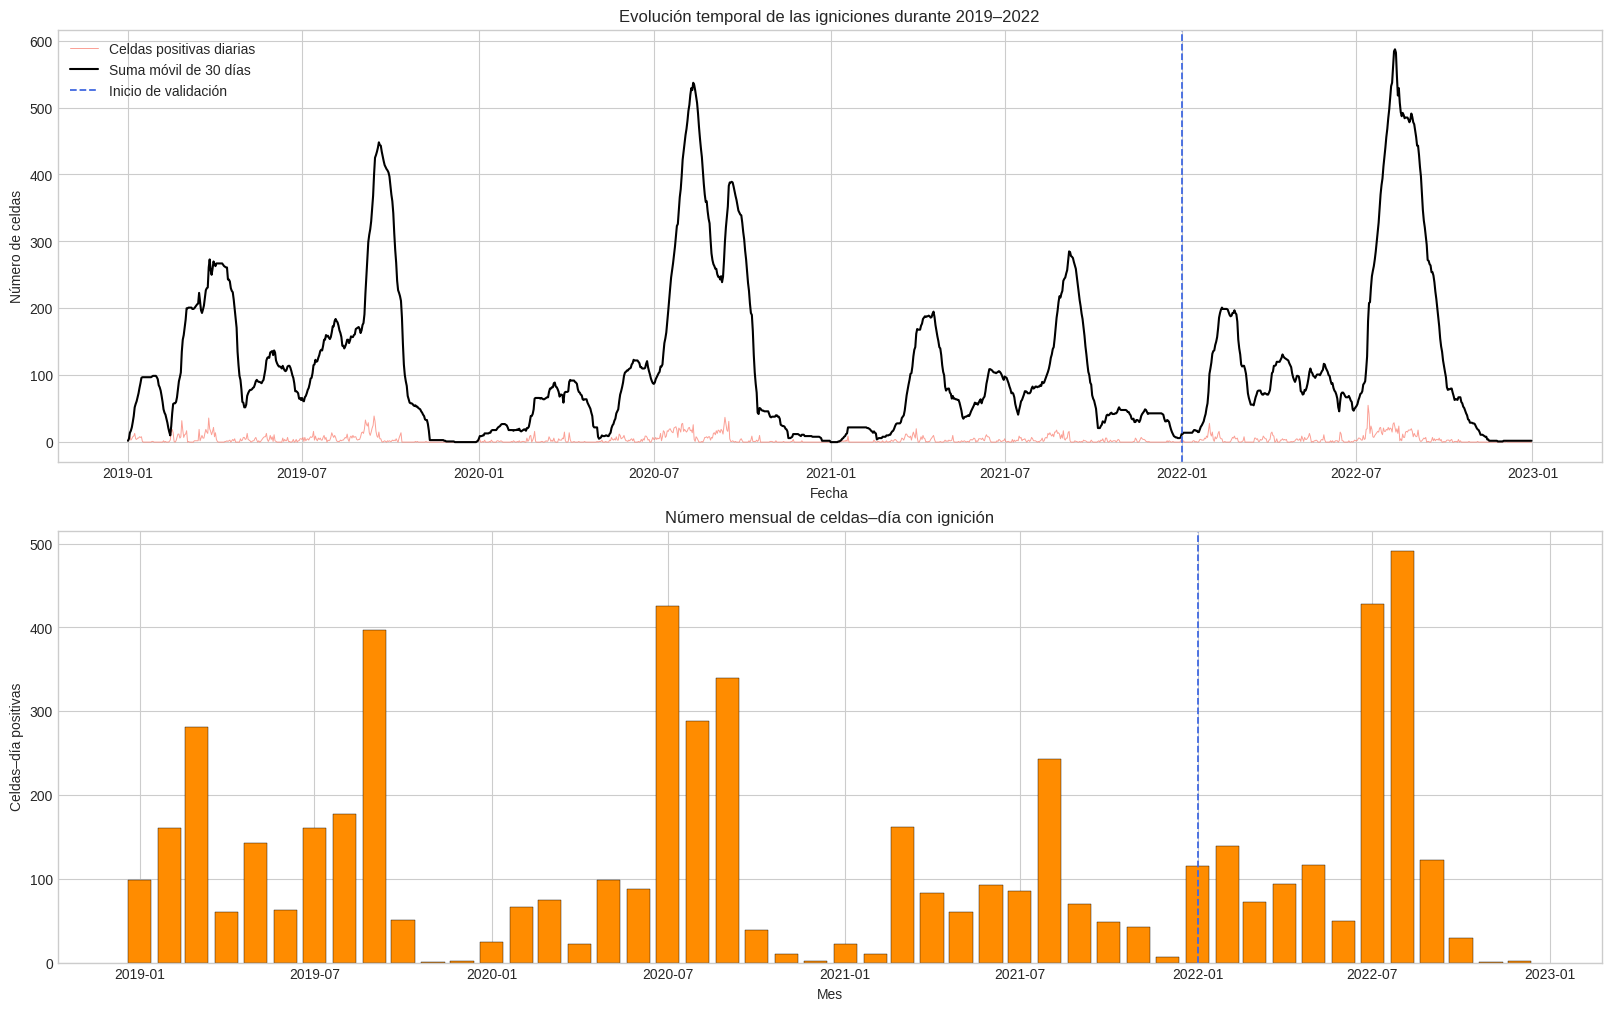


RESUMEN ANUAL


,year,number_of_days,positive_cell_days,days_with_ignition,percentage_days_with_ignition,daily_mean,daily_median,daily_maximum,prevalence,negative_positive_ratio
0,2019,365,"1,595",230,63.01%,4.37,2.00,39,0.01476255%,"6,772.9:1"
1,2020,366,"1,479",206,56.28%,4.04,1.00,37,0.01365151%,"7,324.2:1"
2,2021,365,926,215,58.90%,2.54,1.00,20,0.00857061%,"11,666.8:1"
3,2022,365,"1,659",219,60.00%,4.55,2.00,55,0.01535491%,"6,511.6:1"



RESUMEN MENSUAL AGREGADO


,month,month_name,number_of_days,positive_cell_days,days_with_ignition,percentage_days_with_ignition,daily_mean,daily_maximum,prevalence
0,1,Enero,124,261,59,47.58%,2.10,28,0.00711070%
1,2,Febrero,113,375,61,53.98%,3.32,32,0.01121105%
2,3,Marzo,124,590,88,70.97%,4.76,36,0.01607400%
3,4,Abril,120,259,61,50.83%,2.16,15,0.00729142%
4,5,Mayo,124,418,98,79.03%,3.37,13,0.01138802%
5,6,Junio,120,294,80,66.67%,2.45,15,0.00827675%
6,7,Julio,124,"1,100",117,94.35%,8.87,55,0.02996847%
7,8,Agosto,124,"1,199",118,95.16%,9.67,29,0.03266564%
8,9,Septiembre,120,928,96,80.00%,7.73,39,0.02612524%
9,10,Octubre,124,167,60,48.39%,1.35,14,0.00454976%



DÍAS CON MAYOR NÚMERO DE IGNICIONES


,date,positive_cells
0,2022-07-14,55
1,2022-07-15,42
2,2019-09-14,39
3,2020-09-13,37
4,2019-03-26,36
5,2019-09-05,33
6,2019-02-26,32
7,2019-09-15,31
8,2020-09-17,31
9,2022-08-10,29



Archivos guardados:
  Serie diaria:   /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/01_exploration/daily_target_2019_2022.csv
  Resumen anual:  /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/01_exploration/annual_target_summary_2019_2022.csv
  Resumen mensual:/content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/01_exploration/monthly_target_summary_2019_2022.csv
  Días máximos:   /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/01_exploration/top_ignition_days_2019_2022.csv
  Figura:         /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/figures/target_temporal_distribution_2019_2022.png

✓ Exploración temporal terminada.
✓ 2023 continúa fuera del análisis.


In [3]:
# =============================================================================
# 2.1. EXPLORACIÓN TEMPORAL DEL TARGET
# =============================================================================

import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 2.1.1. Excluir la variable de varianza nula
# -----------------------------------------------------------------------------

ZERO_VARIANCE_PREDICTORS = [
    "road_length_other_km",
]

STATIC_PREDICTORS = [
    feature
    for feature in STATIC_PREDICTORS
    if feature not in ZERO_VARIANCE_PREDICTORS
]

DYNAMIC_PREDICTORS = [
    feature
    for feature in DYNAMIC_PREDICTORS
    if feature not in ZERO_VARIANCE_PREDICTORS
]

CANDIDATE_PREDICTORS = (
    STATIC_PREDICTORS
    + DYNAMIC_PREDICTORS
)

print("=" * 80)
print("ACTUALIZACIÓN DEL CONTRATO DE PREDICTORES")
print("=" * 80)

print(
    "\nVariable excluida por varianza nula: "
    "road_length_other_km"
)
print(f"Predictores estáticos: {len(STATIC_PREDICTORS)}")
print(f"Predictores dinámicos: {len(DYNAMIC_PREDICTORS)}")
print(f"Predictores totales:   {len(CANDIDATE_PREDICTORS)}")

# Actualizar el contrato guardado.
predictor_contract = {
    "static_predictors": STATIC_PREDICTORS,
    "dynamic_predictors": DYNAMIC_PREDICTORS,
    "candidate_predictors": CANDIDATE_PREDICTORS,
    "forbidden_predictors": FORBIDDEN_PREDICTORS,
    "excluded_after_quality_audit": {
        "road_length_other_km":
            "Zero variance within Galicia",
    },
    "number_static_predictors":
        len(STATIC_PREDICTORS),
    "number_dynamic_predictors":
        len(DYNAMIC_PREDICTORS),
    "number_candidate_predictors":
        len(CANDIDATE_PREDICTORS),
    "development_period":
        "2019-01-01 to 2022-12-31",
    "test_2023_used": False,
}

with open(
    PREDICTOR_CONTRACT_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        predictor_contract,
        file,
        ensure_ascii=False,
        indent=2,
    )

# -----------------------------------------------------------------------------
# 2.1.2. Cargar el target de 2019–2022
# -----------------------------------------------------------------------------

development_cube = datacube.sel(
    time=slice(TRAIN_START, VALIDATION_END)
)

development_dates = pd.DatetimeIndex(
    development_cube.time.values
)

print("\n" + "=" * 80)
print("CARGA DEL TARGET DE DESARROLLO")
print("=" * 80)

target_development_2d = (
    development_cube[TARGET]
    .transpose("time", "y", "x")
    .load()
    .values[:, galicia_mask]
    .astype(np.uint8)
)

number_development_days = (
    target_development_2d.shape[0]
)

daily_positive_cells = (
    target_development_2d
    .sum(axis=1)
    .astype(np.int32)
)

daily_target = pd.DataFrame({
    "date": development_dates,
    "positive_cells": daily_positive_cells,
})

daily_target["year"] = (
    daily_target["date"].dt.year
)

daily_target["month"] = (
    daily_target["date"].dt.month
)

daily_target["year_month"] = (
    daily_target["date"]
    .dt.to_period("M")
    .astype(str)
)

daily_target["has_ignition"] = (
    daily_target["positive_cells"] > 0
)

daily_target["rolling_30_day_sum"] = (
    daily_target["positive_cells"]
    .rolling(
        window=30,
        min_periods=1,
    )
    .sum()
)

print(f"Días cargados:       {number_development_days:,}")
print(f"Celdas de Galicia:   {number_galicia_cells:,}")
print(
    f"Celdas-día:          "
    f"{target_development_2d.size:,}"
)
print(
    f"Positivos:           "
    f"{int(target_development_2d.sum()):,}"
)
print(
    f"Días con igniciones: "
    f"{int(daily_target['has_ignition'].sum()):,}"
)

# -----------------------------------------------------------------------------
# 2.1.3. Resumen anual
# -----------------------------------------------------------------------------

annual_rows = []

for year, group in daily_target.groupby("year"):
    number_days = len(group)
    positive_cell_days = int(
        group["positive_cells"].sum()
    )
    days_with_ignition = int(
        group["has_ignition"].sum()
    )

    annual_rows.append({
        "year": int(year),
        "number_of_days": number_days,
        "positive_cell_days": positive_cell_days,
        "days_with_ignition": days_with_ignition,
        "percentage_days_with_ignition":
            days_with_ignition / number_days,
        "daily_mean":
            group["positive_cells"].mean(),
        "daily_median":
            group["positive_cells"].median(),
        "daily_maximum":
            int(group["positive_cells"].max()),
        "prevalence":
            (
                positive_cell_days
                / (number_days * number_galicia_cells)
            ),
        "negative_positive_ratio":
            (
                (
                    number_days * number_galicia_cells
                    - positive_cell_days
                )
                / positive_cell_days
            ),
    })

annual_summary = pd.DataFrame(
    annual_rows
)

# -----------------------------------------------------------------------------
# 2.1.4. Resumen mensual agregado
# -----------------------------------------------------------------------------

month_names = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre",
}

monthly_rows = []

for month, group in daily_target.groupby("month"):
    number_days = len(group)
    positive_cell_days = int(
        group["positive_cells"].sum()
    )
    days_with_ignition = int(
        group["has_ignition"].sum()
    )

    monthly_rows.append({
        "month": int(month),
        "month_name": month_names[int(month)],
        "number_of_days": number_days,
        "positive_cell_days": positive_cell_days,
        "days_with_ignition": days_with_ignition,
        "percentage_days_with_ignition":
            days_with_ignition / number_days,
        "daily_mean":
            group["positive_cells"].mean(),
        "daily_maximum":
            int(group["positive_cells"].max()),
        "prevalence":
            (
                positive_cell_days
                / (number_days * number_galicia_cells)
            ),
    })

monthly_summary = pd.DataFrame(
    monthly_rows
).sort_values("month")

# Serie mensual completa.
monthly_time_series = (
    daily_target
    .set_index("date")["positive_cells"]
    .resample("MS")
    .sum()
    .rename("positive_cell_days")
    .reset_index()
)

# Días con más igniciones.
top_ignition_days = (
    daily_target[[
        "date",
        "positive_cells",
    ]]
    .sort_values(
        "positive_cells",
        ascending=False,
    )
    .head(15)
    .reset_index(drop=True)
)

# -----------------------------------------------------------------------------
# 2.1.5. Guardar tablas
# -----------------------------------------------------------------------------

DAILY_TARGET_PATH = (
    DIRECTORIES["exploration"] /
    "daily_target_2019_2022.csv"
)

ANNUAL_SUMMARY_PATH = (
    DIRECTORIES["exploration"] /
    "annual_target_summary_2019_2022.csv"
)

MONTHLY_SUMMARY_PATH = (
    DIRECTORIES["exploration"] /
    "monthly_target_summary_2019_2022.csv"
)

TOP_DAYS_PATH = (
    DIRECTORIES["exploration"] /
    "top_ignition_days_2019_2022.csv"
)

daily_target.to_csv(
    DAILY_TARGET_PATH,
    index=False,
)

annual_summary.to_csv(
    ANNUAL_SUMMARY_PATH,
    index=False,
)

monthly_summary.to_csv(
    MONTHLY_SUMMARY_PATH,
    index=False,
)

top_ignition_days.to_csv(
    TOP_DAYS_PATH,
    index=False,
)

# -----------------------------------------------------------------------------
# 2.1.6. Visualización
# -----------------------------------------------------------------------------

plt.style.use("seaborn-v0_8-whitegrid")

figure, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(16, 10),
    constrained_layout=True,
)

# Evolución diaria.
axes[0].plot(
    daily_target["date"],
    daily_target["positive_cells"],
    color="salmon",
    linewidth=0.7,
    alpha=0.75,
    label="Celdas positivas diarias",
)

axes[0].plot(
    daily_target["date"],
    daily_target["rolling_30_day_sum"],
    color="black",
    linewidth=1.5,
    label="Suma móvil de 30 días",
)

axes[0].axvline(
    pd.Timestamp(VALIDATION_START),
    color="royalblue",
    linestyle="--",
    linewidth=1.3,
    label="Inicio de validación",
)

axes[0].set_title(
    "Evolución temporal de las igniciones durante 2019–2022"
)
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Número de celdas")
axes[0].legend()

# Totales mensuales.
axes[1].bar(
    monthly_time_series["date"],
    monthly_time_series["positive_cell_days"],
    width=24,
    color="darkorange",
    edgecolor="black",
    linewidth=0.3,
)

axes[1].axvline(
    pd.Timestamp(VALIDATION_START),
    color="royalblue",
    linestyle="--",
    linewidth=1.3,
)

axes[1].set_title(
    "Número mensual de celdas–día con ignición"
)
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Celdas–día positivas")

TEMPORAL_FIGURE_PATH = (
    DIRECTORIES["figures"] /
    "target_temporal_distribution_2019_2022.png"
)

figure.savefig(
    TEMPORAL_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

# -----------------------------------------------------------------------------
# 2.1.7. Resultados
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("RESUMEN ANUAL")
print("=" * 80)

display(
    annual_summary.style.format({
        "positive_cell_days": "{:,.0f}",
        "percentage_days_with_ignition": "{:.2%}",
        "daily_mean": "{:.2f}",
        "daily_median": "{:.2f}",
        "prevalence": "{:.8%}",
        "negative_positive_ratio": "{:,.1f}:1",
    })
)

print("\n" + "=" * 80)
print("RESUMEN MENSUAL AGREGADO")
print("=" * 80)

display(
    monthly_summary.style.format({
        "positive_cell_days": "{:,.0f}",
        "percentage_days_with_ignition": "{:.2%}",
        "daily_mean": "{:.2f}",
        "prevalence": "{:.8%}",
    })
)

print("\n" + "=" * 80)
print("DÍAS CON MAYOR NÚMERO DE IGNICIONES")
print("=" * 80)

display(top_ignition_days)

print("\nArchivos guardados:")
print(f"  Serie diaria:   {DAILY_TARGET_PATH}")
print(f"  Resumen anual:  {ANNUAL_SUMMARY_PATH}")
print(f"  Resumen mensual:{MONTHLY_SUMMARY_PATH}")
print(f"  Días máximos:   {TOP_DAYS_PATH}")
print(f"  Figura:         {TEMPORAL_FIGURE_PATH}")

print("\n✓ Exploración temporal terminada.")
print("✓ 2023 continúa fuera del análisis.")

## Conclusiones de la distribución temporal

Durante el periodo de desarrollo 2019–2022 se registraron 5.659 celdas–día con ignición, distribuidas a lo largo de 870 días. Esto significa que hubo al menos una ignición en aproximadamente el 60% de los días, aunque el número de celdas afectadas fue muy reducido respecto a las 29.601 celdas de Galicia.

La actividad presenta diferencias importantes entre años:

- 2019 registró 1.595 celdas–día positivas.
- 2020 registró 1.479.
- 2021 fue el año con menor actividad, con 926.
- 2022 fue el año más activo, con 1.659.

La prevalencia anual varía entre el 0,0086% de 2021 y el 0,0154% de 2022. Por tanto, el conjunto de validación contiene una proporción de igniciones mayor que el conjunto de entrenamiento, lo que supone una prueba temporal exigente para los modelos.

La distribución mensual muestra una estacionalidad clara. El periodo principal de actividad se concentra entre julio y septiembre:

- agosto presenta la prevalencia mensual más elevada;
- julio y septiembre también muestran una actividad alta;
- durante julio y agosto se registra alguna ignición en más del 94% de los días.

También aparece un periodo secundario de actividad durante febrero y marzo. Por el contrario, noviembre y diciembre presentan una actividad muy reducida.

La serie temporal muestra que las igniciones se agrupan en episodios de distinta intensidad. Los máximos no se repiten exactamente en las mismas fechas cada año, lo que indica que la estacionalidad por sí sola no es suficiente y que las condiciones meteorológicas tienen un papel relevante.

El día de mayor actividad fue el 14 de julio de 2022, con 55 celdas positivas, seguido por el 15 de julio de 2022, con 42. La concentración de numerosos positivos en determinados episodios deberá tenerse en cuenta al interpretar las métricas diarias.

Estos resultados justifican:

- mantener una división temporal de entrenamiento y validación;
- incluir variables meteorológicas actuales y acumuladas;
- evaluar el rendimiento tanto de forma global como separadamente para cada día;
- utilizar métricas adecuadas para eventos extremadamente infrecuentes.

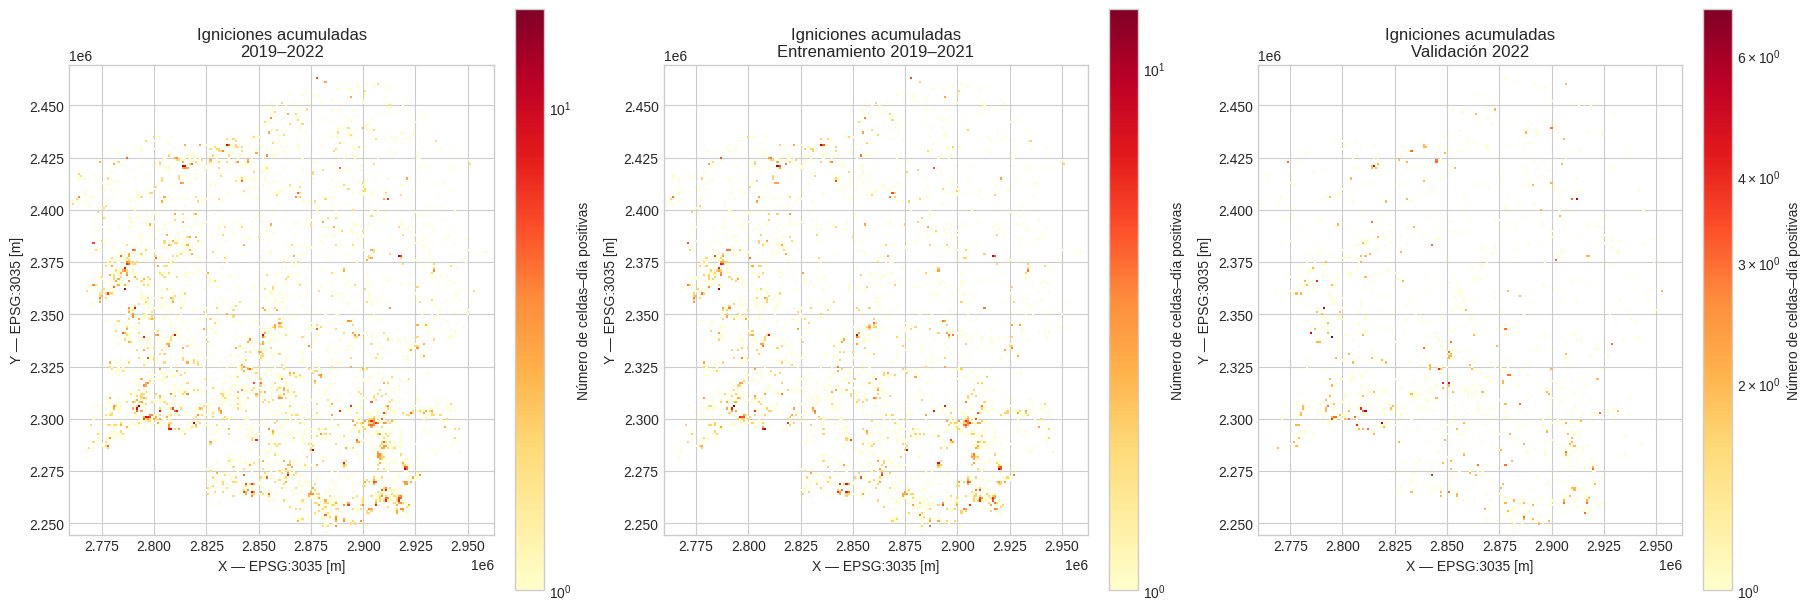

CONCENTRACIÓN ESPACIAL


,number_of_galicia_cells,positive_cell_days,cells_without_ignition,cells_with_ignition,cells_with_multiple_ignitions,cells_with_five_or_more,cells_with_ten_or_more,percentage_cells_without_ignition,percentage_cells_with_ignition,percentage_cells_with_multiple_ignitions,mean_ignitions_per_cell,median_ignitions_per_cell,maximum_cell_recurrence
0,29601,"5,659","25,799","3,802","1,052",86,12,87.16%,12.84%,3.55%,0.1912,0.0,16



Concentración en las celdas más recurrentes:


,top_cells_percentage,number_of_cells,captured_positive_cell_days,share_of_ignitions
0,0.1%,30,279,4.93%
1,0.5%,149,840,14.84%
2,1.0%,297,"1,309",23.13%
3,2.0%,593,"1,991",35.18%
4,5.0%,"1,481","3,338",58.99%
5,10.0%,"2,961","4,818",85.14%
6,20.0%,"5,921","5,659",100.00%
7,50.0%,"14,801","5,659",100.00%



RESUMEN ESPACIAL ANUAL


...


Índice de Jaccard entre celdas afectadas:


,2019,2020,2021,2022
year,,,,
2019,1.000,0.090,0.063,0.081
2020,0.090,1.000,0.069,0.079
2021,0.063,0.069,1.000,0.071
2022,0.081,0.079,0.071,1.000



TRANSFERENCIA ESPACIAL A VALIDACIÓN


,validation_year,affected_cells,previously_seen_cells,new_cells,percentage_affected_cells_previously_seen,positive_cell_days,positive_cell_days_in_previously_seen_cells,percentage_positive_cell_days_in_seen_cells
0,2022,"1,363",396,967,29.05%,"1,659",531,32.01%



Archivos guardados:
  Resumen:       /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/01_exploration/spatial_target_summary_2019_2022.csv
  Recurrencia:   /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/01_exploration/cell_recurrence_distribution_2019_2022.csv
  Concentración: /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/01_exploration/spatial_concentration_2019_2022.csv
  Resumen anual: /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/01_exploration/annual_spatial_summary_2019_2022.csv
  Jaccard:       /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/01_exploration/annual_spatial_jaccard_2019_2022.csv
  Transferencia: /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/01_exploration/validation_spatial_transfer_2022.csv
  Figura:        /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/figures/target_spatial_distribution_2019_2022.png

✓ Exploración espacial terminada.
✓ 2023 continúa fuera del análisis.


In [4]:
# =============================================================================
# 2.2. EXPLORACIÓN ESPACIAL DEL TARGET
# =============================================================================

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.colors import LogNorm

# -----------------------------------------------------------------------------
# 2.2.1. Recuperar el target si no permanece en memoria
# -----------------------------------------------------------------------------

if "target_development_2d" not in globals():
    development_cube = datacube.sel(
        time=slice(TRAIN_START, VALIDATION_END)
    )

    development_dates = pd.DatetimeIndex(
        development_cube.time.values
    )

    target_development_2d = (
        development_cube[TARGET]
        .transpose("time", "y", "x")
        .load()
        .values[:, galicia_mask]
        .astype(np.uint8)
    )

years = development_dates.year.to_numpy()

if target_development_2d.shape != (
    len(development_dates),
    number_galicia_cells,
):
    raise ValueError(
        "La forma del target no coincide con el número "
        "de fechas y celdas de Galicia."
    )

# -----------------------------------------------------------------------------
# 2.2.2. Recurrencia acumulada por celda
# -----------------------------------------------------------------------------

ignitions_per_cell = (
    target_development_2d
    .sum(axis=0)
    .astype(np.int32)
)

total_ignitions = int(
    ignitions_per_cell.sum()
)

cells_without_ignition = int(
    (ignitions_per_cell == 0).sum()
)

cells_with_ignition = int(
    (ignitions_per_cell > 0).sum()
)

cells_with_multiple_ignitions = int(
    (ignitions_per_cell > 1).sum()
)

cells_with_five_or_more = int(
    (ignitions_per_cell >= 5).sum()
)

cells_with_ten_or_more = int(
    (ignitions_per_cell >= 10).sum()
)

maximum_cell_recurrence = int(
    ignitions_per_cell.max()
)

spatial_summary = pd.DataFrame([{
    "number_of_galicia_cells":
        number_galicia_cells,
    "positive_cell_days":
        total_ignitions,
    "cells_without_ignition":
        cells_without_ignition,
    "cells_with_ignition":
        cells_with_ignition,
    "cells_with_multiple_ignitions":
        cells_with_multiple_ignitions,
    "cells_with_five_or_more":
        cells_with_five_or_more,
    "cells_with_ten_or_more":
        cells_with_ten_or_more,
    "percentage_cells_without_ignition":
        cells_without_ignition / number_galicia_cells,
    "percentage_cells_with_ignition":
        cells_with_ignition / number_galicia_cells,
    "percentage_cells_with_multiple_ignitions":
        cells_with_multiple_ignitions / number_galicia_cells,
    "mean_ignitions_per_cell":
        float(ignitions_per_cell.mean()),
    "median_ignitions_per_cell":
        float(np.median(ignitions_per_cell)),
    "maximum_cell_recurrence":
        maximum_cell_recurrence,
}])

# Distribución exacta de recurrencia.
unique_recurrence, recurrence_counts = np.unique(
    ignitions_per_cell,
    return_counts=True,
)

recurrence_distribution = pd.DataFrame({
    "ignitions_in_cell": unique_recurrence,
    "number_of_cells": recurrence_counts,
})

recurrence_distribution[
    "percentage_of_galicia_cells"
] = (
    recurrence_distribution["number_of_cells"]
    / number_galicia_cells
)

recurrence_distribution[
    "positive_cell_days"
] = (
    recurrence_distribution["ignitions_in_cell"]
    * recurrence_distribution["number_of_cells"]
)

recurrence_distribution[
    "share_of_all_ignitions"
] = (
    recurrence_distribution["positive_cell_days"]
    / total_ignitions
)

# -----------------------------------------------------------------------------
# 2.2.3. Concentración espacial
# -----------------------------------------------------------------------------

sorted_recurrence = np.sort(
    ignitions_per_cell
)[::-1]

concentration_rows = []

for top_percentage in [
    0.001,
    0.005,
    0.01,
    0.02,
    0.05,
    0.10,
    0.20,
    0.50,
]:
    number_selected_cells = max(
        1,
        int(np.ceil(
            number_galicia_cells
            * top_percentage
        )),
    )

    captured_ignitions = int(
        sorted_recurrence[
            :number_selected_cells
        ].sum()
    )

    concentration_rows.append({
        "top_cells_percentage":
            top_percentage,
        "number_of_cells":
            number_selected_cells,
        "captured_positive_cell_days":
            captured_ignitions,
        "share_of_ignitions":
            captured_ignitions / total_ignitions,
    })

spatial_concentration = pd.DataFrame(
    concentration_rows
)

# -----------------------------------------------------------------------------
# 2.2.4. Mapas y resumen anual
# -----------------------------------------------------------------------------

annual_cell_counts = {}
annual_rows = []

for year in sorted(np.unique(years)):
    year_mask = years == year

    counts = (
        target_development_2d[year_mask]
        .sum(axis=0)
        .astype(np.int32)
    )

    annual_cell_counts[int(year)] = counts

    annual_rows.append({
        "year": int(year),
        "positive_cell_days":
            int(counts.sum()),
        "cells_with_ignition":
            int((counts > 0).sum()),
        "cells_with_multiple_ignitions":
            int((counts > 1).sum()),
        "maximum_in_one_cell":
            int(counts.max()),
        "percentage_galicia_cells_affected":
            float(
                (counts > 0).sum()
                / number_galicia_cells
            ),
    })

annual_spatial_summary = pd.DataFrame(
    annual_rows
)

# -----------------------------------------------------------------------------
# 2.2.5. Índice de Jaccard entre años
# -----------------------------------------------------------------------------

unique_years = sorted(
    annual_cell_counts.keys()
)

jaccard_matrix = np.zeros(
    (
        len(unique_years),
        len(unique_years),
    ),
    dtype=float,
)

for row_index, year_a in enumerate(unique_years):
    affected_a = (
        annual_cell_counts[year_a] > 0
    )

    for column_index, year_b in enumerate(unique_years):
        affected_b = (
            annual_cell_counts[year_b] > 0
        )

        intersection = np.logical_and(
            affected_a,
            affected_b,
        ).sum()

        union = np.logical_or(
            affected_a,
            affected_b,
        ).sum()

        jaccard_matrix[
            row_index,
            column_index,
        ] = (
            intersection / union
            if union > 0
            else np.nan
        )

annual_jaccard = pd.DataFrame(
    jaccard_matrix,
    index=unique_years,
    columns=unique_years,
)

annual_jaccard.index.name = "year"

# -----------------------------------------------------------------------------
# 2.2.6. Transferencia espacial de entrenamiento a validación
# -----------------------------------------------------------------------------

training_cell_counts = (
    annual_cell_counts[2019]
    + annual_cell_counts[2020]
    + annual_cell_counts[2021]
)

validation_cell_counts = (
    annual_cell_counts[2022]
)

seen_during_training = (
    training_cell_counts > 0
)

affected_in_validation = (
    validation_cell_counts > 0
)

previously_seen_validation_cells = int(
    np.logical_and(
        seen_during_training,
        affected_in_validation,
    ).sum()
)

new_validation_cells = int(
    np.logical_and(
        ~seen_during_training,
        affected_in_validation,
    ).sum()
)

validation_ignitions_in_seen_cells = int(
    validation_cell_counts[
        seen_during_training
    ].sum()
)

validation_spatial_transfer = pd.DataFrame([{
    "validation_year": 2022,
    "affected_cells":
        int(affected_in_validation.sum()),
    "previously_seen_cells":
        previously_seen_validation_cells,
    "new_cells":
        new_validation_cells,
    "percentage_affected_cells_previously_seen":
        (
            previously_seen_validation_cells
            / affected_in_validation.sum()
        ),
    "positive_cell_days":
        int(validation_cell_counts.sum()),
    "positive_cell_days_in_previously_seen_cells":
        validation_ignitions_in_seen_cells,
    "percentage_positive_cell_days_in_seen_cells":
        (
            validation_ignitions_in_seen_cells
            / validation_cell_counts.sum()
        ),
}])

# -----------------------------------------------------------------------------
# 2.2.7. Preparar mapas completos
# -----------------------------------------------------------------------------

def active_values_to_map(values):
    output = np.full(
        galicia_mask.shape,
        np.nan,
        dtype=np.float32,
    )

    output[galicia_mask] = values

    return output


galicia_map = np.where(
    galicia_mask,
    1.0,
    np.nan,
)

cumulative_map = active_values_to_map(
    ignitions_per_cell
)

training_map = active_values_to_map(
    training_cell_counts
)

validation_map = active_values_to_map(
    validation_cell_counts
)

positive_cumulative_map = np.ma.masked_where(
    ~np.isfinite(cumulative_map)
    | (cumulative_map <= 0),
    cumulative_map,
)

positive_training_map = np.ma.masked_where(
    ~np.isfinite(training_map)
    | (training_map <= 0),
    training_map,
)

positive_validation_map = np.ma.masked_where(
    ~np.isfinite(validation_map)
    | (validation_map <= 0),
    validation_map,
)

x_coordinates = datacube["x"].values
y_coordinates = datacube["y"].values

# -----------------------------------------------------------------------------
# 2.2.8. Visualización
# -----------------------------------------------------------------------------

plt.style.use("seaborn-v0_8-whitegrid")

figure, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6),
    constrained_layout=True,
)

# Mapa acumulado.
image_1 = axes[0].pcolormesh(
    x_coordinates,
    y_coordinates,
    positive_cumulative_map,
    cmap="YlOrRd",
    norm=LogNorm(
        vmin=1,
        vmax=max(
            1,
            maximum_cell_recurrence,
        ),
    ),
    shading="auto",
)

axes[0].set_title(
    "Igniciones acumuladas\n2019–2022"
)
axes[0].set_xlabel("X — EPSG:3035 [m]")
axes[0].set_ylabel("Y — EPSG:3035 [m]")
axes[0].set_aspect("equal")

figure.colorbar(
    image_1,
    ax=axes[0],
    label="Número de celdas–día positivas",
)

# Entrenamiento.
training_maximum = max(
    1,
    int(training_cell_counts.max()),
)

image_2 = axes[1].pcolormesh(
    x_coordinates,
    y_coordinates,
    positive_training_map,
    cmap="YlOrRd",
    norm=LogNorm(
        vmin=1,
        vmax=training_maximum,
    ),
    shading="auto",
)

axes[1].set_title(
    "Igniciones acumuladas\nEntrenamiento 2019–2021"
)
axes[1].set_xlabel("X — EPSG:3035 [m]")
axes[1].set_ylabel("Y — EPSG:3035 [m]")
axes[1].set_aspect("equal")

figure.colorbar(
    image_2,
    ax=axes[1],
    label="Número de celdas–día positivas",
)

# Validación.
validation_maximum = max(
    1,
    int(validation_cell_counts.max()),
)

image_3 = axes[2].pcolormesh(
    x_coordinates,
    y_coordinates,
    positive_validation_map,
    cmap="YlOrRd",
    norm=LogNorm(
        vmin=1,
        vmax=validation_maximum,
    ),
    shading="auto",
)

axes[2].set_title(
    "Igniciones acumuladas\nValidación 2022"
)
axes[2].set_xlabel("X — EPSG:3035 [m]")
axes[2].set_ylabel("Y — EPSG:3035 [m]")
axes[2].set_aspect("equal")

figure.colorbar(
    image_3,
    ax=axes[2],
    label="Número de celdas–día positivas",
)

SPATIAL_FIGURE_PATH = (
    DIRECTORIES["figures"] /
    "target_spatial_distribution_2019_2022.png"
)

figure.savefig(
    SPATIAL_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

# -----------------------------------------------------------------------------
# 2.2.9. Guardar resultados
# -----------------------------------------------------------------------------

SPATIAL_SUMMARY_PATH = (
    DIRECTORIES["exploration"] /
    "spatial_target_summary_2019_2022.csv"
)

RECURRENCE_PATH = (
    DIRECTORIES["exploration"] /
    "cell_recurrence_distribution_2019_2022.csv"
)

CONCENTRATION_PATH = (
    DIRECTORIES["exploration"] /
    "spatial_concentration_2019_2022.csv"
)

ANNUAL_SPATIAL_PATH = (
    DIRECTORIES["exploration"] /
    "annual_spatial_summary_2019_2022.csv"
)

JACCARD_PATH = (
    DIRECTORIES["exploration"] /
    "annual_spatial_jaccard_2019_2022.csv"
)

TRANSFER_PATH = (
    DIRECTORIES["exploration"] /
    "validation_spatial_transfer_2022.csv"
)

spatial_summary.to_csv(
    SPATIAL_SUMMARY_PATH,
    index=False,
)

recurrence_distribution.to_csv(
    RECURRENCE_PATH,
    index=False,
)

spatial_concentration.to_csv(
    CONCENTRATION_PATH,
    index=False,
)

annual_spatial_summary.to_csv(
    ANNUAL_SPATIAL_PATH,
    index=False,
)

annual_jaccard.to_csv(
    JACCARD_PATH,
)

validation_spatial_transfer.to_csv(
    TRANSFER_PATH,
    index=False,
)

# -----------------------------------------------------------------------------
# 2.2.10. Mostrar resultados
# -----------------------------------------------------------------------------

print("=" * 80)
print("CONCENTRACIÓN ESPACIAL")
print("=" * 80)

display(
    spatial_summary.style.format({
        "positive_cell_days": "{:,.0f}",
        "cells_without_ignition": "{:,.0f}",
        "cells_with_ignition": "{:,.0f}",
        "cells_with_multiple_ignitions": "{:,.0f}",
        "percentage_cells_without_ignition": "{:.2%}",
        "percentage_cells_with_ignition": "{:.2%}",
        "percentage_cells_with_multiple_ignitions": "{:.2%}",
        "mean_ignitions_per_cell": "{:.4f}",
        "median_ignitions_per_cell": "{:.1f}",
    })
)

print("\nConcentración en las celdas más recurrentes:")

display(
    spatial_concentration.style.format({
        "top_cells_percentage": "{:.1%}",
        "number_of_cells": "{:,.0f}",
        "captured_positive_cell_days": "{:,.0f}",
        "share_of_ignitions": "{:.2%}",
    })
)

print("\n" + "=" * 80)
print("RESUMEN ESPACIAL ANUAL")
print("=" * 80)

display(
    annual_spatial_summary.style.format({
        "positive_cell_days": "{:,.0f}",
        "cells_with_ignition": "{:,.0f}",
        "cells_with_multiple_ignitions": "{:,.0f}",
        "percentage_galicia_cells_affected": "{:.2%}",
    })
)

print("\nÍndice de Jaccard entre celdas afectadas:")

display(
    annual_jaccard.style.format("{:.3f}")
)

print("\n" + "=" * 80)
print("TRANSFERENCIA ESPACIAL A VALIDACIÓN")
print("=" * 80)

display(
    validation_spatial_transfer.style.format({
        "affected_cells": "{:,.0f}",
        "previously_seen_cells": "{:,.0f}",
        "new_cells": "{:,.0f}",
        "percentage_affected_cells_previously_seen": "{:.2%}",
        "positive_cell_days": "{:,.0f}",
        "positive_cell_days_in_previously_seen_cells": "{:,.0f}",
        "percentage_positive_cell_days_in_seen_cells": "{:.2%}",
    })
)

print("\nArchivos guardados:")
print(f"  Resumen:       {SPATIAL_SUMMARY_PATH}")
print(f"  Recurrencia:   {RECURRENCE_PATH}")
print(f"  Concentración: {CONCENTRATION_PATH}")
print(f"  Resumen anual: {ANNUAL_SPATIAL_PATH}")
print(f"  Jaccard:       {JACCARD_PATH}")
print(f"  Transferencia: {TRANSFER_PATH}")
print(f"  Figura:        {SPATIAL_FIGURE_PATH}")

print("\n✓ Exploración espacial terminada.")
print("✓ 2023 continúa fuera del análisis.")

## Conclusiones de la distribución espacial

Las igniciones presentan una distribución espacial heterogénea y poco recurrente.

Durante 2019–2022, solamente 3.802 de las 29.601 celdas de Galicia registraron alguna ignición. Por tanto:

- el 87,16% de las celdas no registró ninguna ignición;
- el 12,84% registró al menos una;
- únicamente el 3,55% registró más de una ignición;
- la mediana de igniciones por celda fue cero;
- el máximo observado en una misma celda fue de 16 celdas–día positivas.

Existe cierta concentración espacial. El 1% de las celdas con mayor recurrencia acumuló el 23,13% de las igniciones y el 10% acumuló el 85,14%. Esto indica que existen zonas con una susceptibilidad histórica mayor, aunque la recurrencia exacta en una misma celda sigue siendo reducida.

El solapamiento entre años es bajo. Los índices de Jaccard entre las celdas afectadas de dos años diferentes se encuentran entre 0,063 y 0,090. Esto significa que la mayor parte de las celdas afectadas cambia de un año a otro.

La diferencia espacial entre entrenamiento y validación es especialmente relevante:

- en 2022 se observaron igniciones en 1.363 celdas;
- solamente 396 habían registrado alguna ignición durante 2019–2021;
- 967 celdas, el 70,95%, no habían registrado positivos durante el entrenamiento;
- únicamente el 32,01% de las celdas–día positivas de 2022 ocurrió en celdas previamente afectadas.

En consecuencia, un modelo basado únicamente en memorizar ubicaciones históricas tendría una capacidad de generalización limitada. La predicción debe apoyarse en características transferibles como la topografía, la cobertura del suelo, la presencia humana y las condiciones meteorológicas.

La concentración espacial justifica la inclusión de predictores estáticos, pero el reducido solapamiento anual demuestra que estos deben combinarse con variables meteorológicas dinámicas.

## 2.3. Exploración de los predictores

El datacubo combina variables estáticas, que no cambian durante el periodo de estudio, y variables meteorológicas diarias.

En esta sección se representan algunos predictores relevantes para comprender su distribución:

- elevación y pendiente;
- cobertura agrícola y de matorral;
- longitud total de vías y longitud de pistas;
- superficie residencial y superficie ocupada por edificios.

También se estudia la evolución mensual media de cinco variables meteorológicas representativas:

- temperatura media;
- humedad relativa media;
- déficit de presión de vapor;
- velocidad media del viento;
- precipitación diaria.

Finalmente, se resumen las nuevas variables de presencia humana mediante sus percentiles y su proporción de ceros.

El análisis se limita nuevamente al periodo 2019–2022.

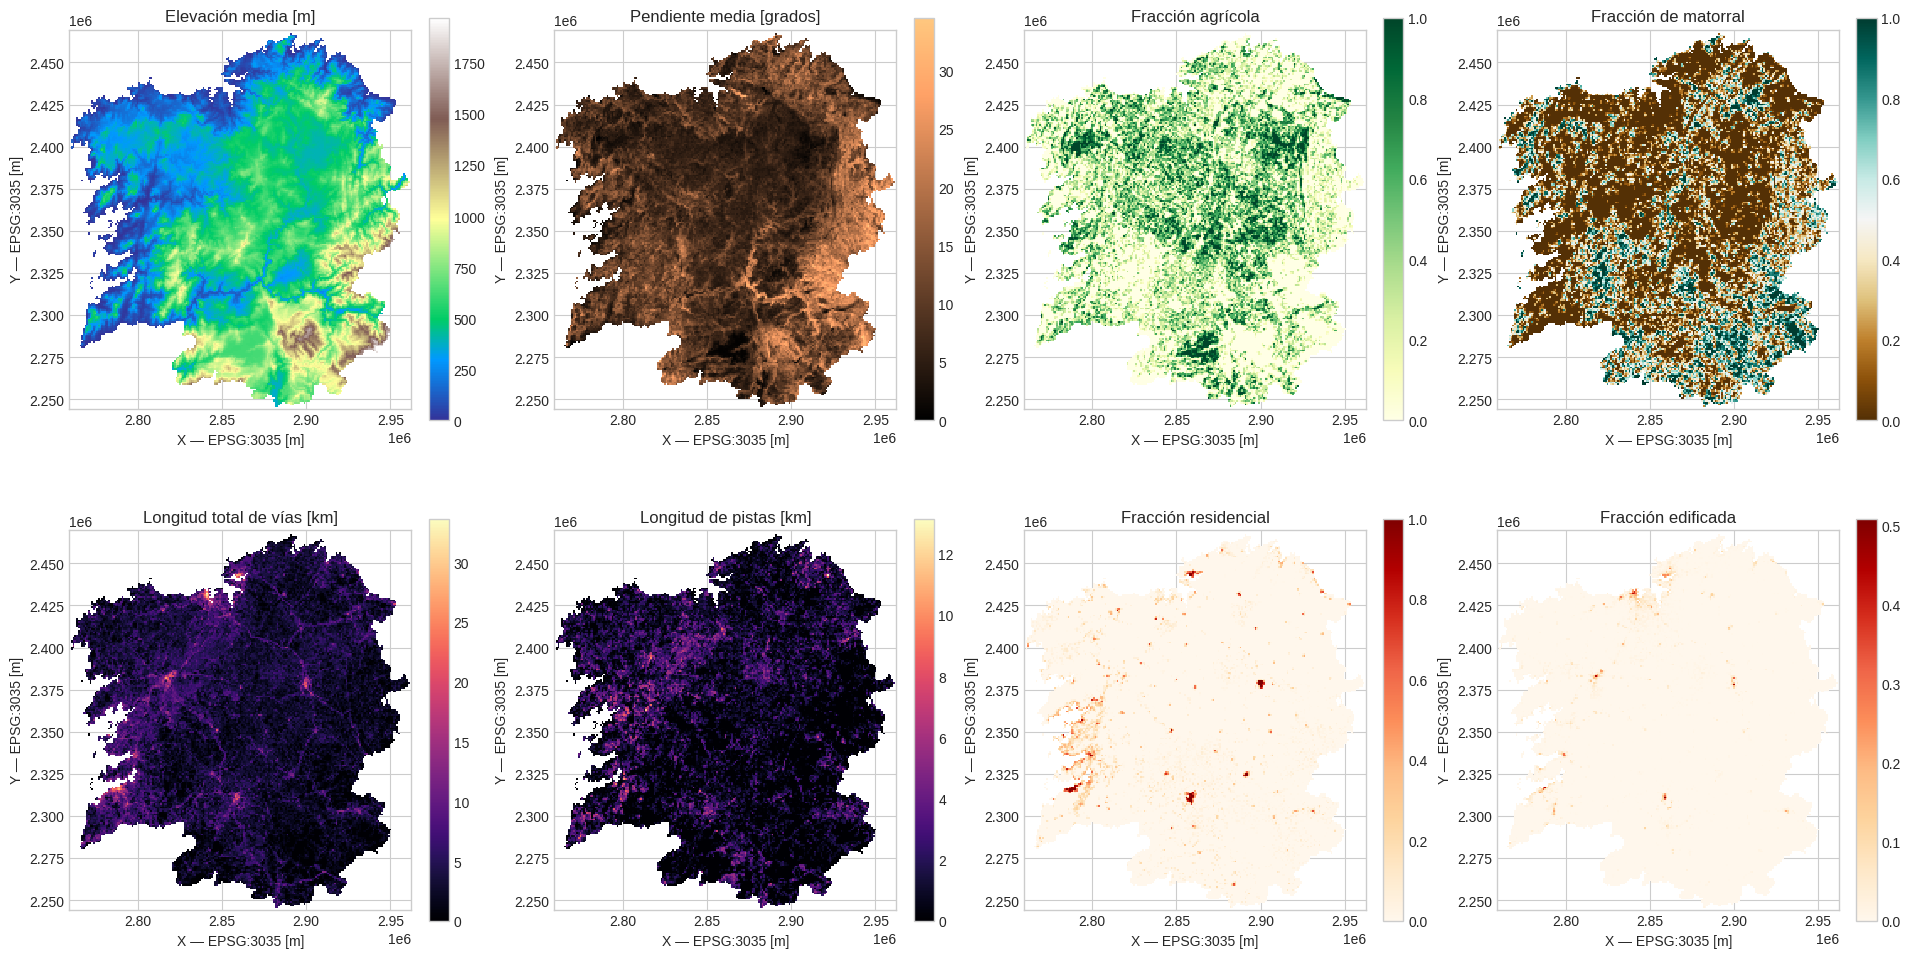

CÁLCULO DE MEDIAS ESPACIALES DIARIAS
[1/5] temperature_mean                   1.9 s
[2/5] relative_humidity_mean             1.8 s
[3/5] vpd_mean                           1.9 s
[4/5] wind_speed_mean                    2.2 s
[5/5] precipitation_sum                  2.6 s


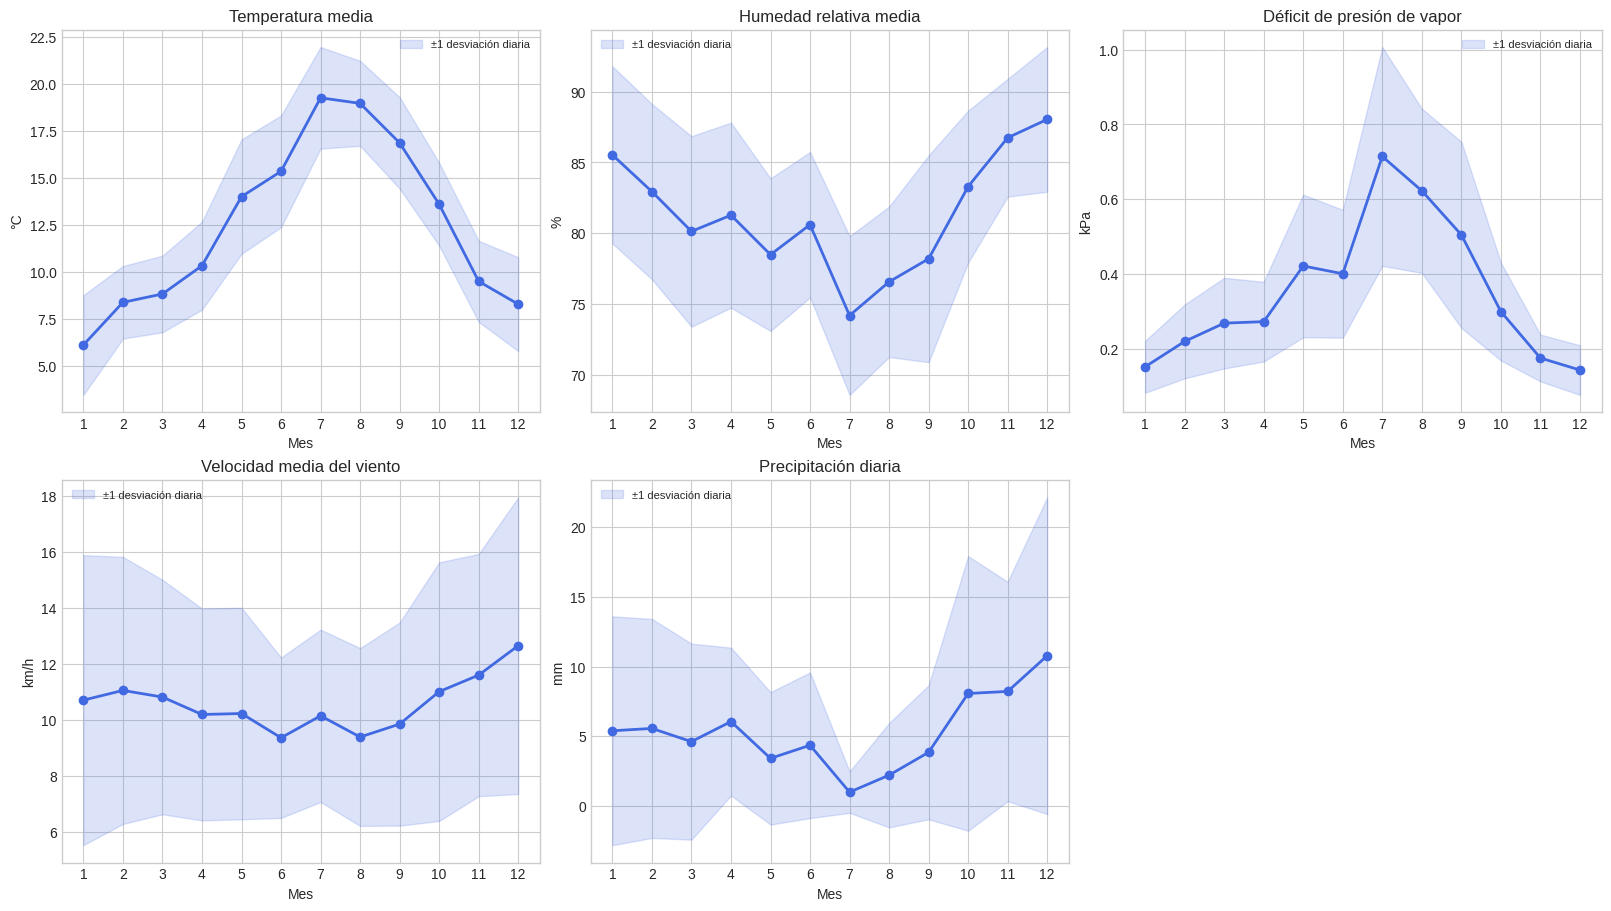


RESUMEN DE VARIABLES HUMANAS


,feature,minimum,percentile_01,percentile_05,percentile_25,median,mean,percentile_75,percentile_95,percentile_99,maximum,standard_deviation,zero_fraction
0,road_length_km,0.0000,0.0000,0.0000,1.7256,3.1812,3.6674,5.0203,8.6826,12.9926,33.6418,2.8150,5.77%
1,road_length_main_km,0.0000,0.0000,0.0000,0.0000,0.0000,0.3396,0.0000,2.0047,4.0069,10.8568,0.8401,76.04%
2,road_length_local_km,0.0000,0.0000,0.0000,0.5636,1.7823,2.1944,3.1419,6.0891,9.5813,27.4302,2.1613,16.18%
3,road_length_track_km,0.0000,0.0000,0.0000,0.0000,0.7168,1.1334,1.7453,3.7981,5.5836,13.1464,1.3202,25.89%
4,residential_area_fraction,0.0000,0.0000,0.0000,0.0000,0.0000,0.0181,0.0000,0.0948,0.3691,1.0000,0.0744,76.05%
5,building_area_fraction,0.0000,0.0000,0.0000,0.0000,0.0000,0.0026,0.0002,0.0100,0.0519,0.5090,0.0152,68.01%



CLIMATOLOGÍA MENSUAL


,month,temperature_mean,relative_humidity_mean,vpd_mean,wind_speed_mean,precipitation_sum
0,1,6.13,85.53,0.152,10.71,5.40
1,2,8.39,82.94,0.220,11.06,5.56
2,3,8.84,80.14,0.268,10.82,4.62
3,4,10.34,81.28,0.272,10.20,6.06
4,5,14.01,78.50,0.421,10.23,3.42
5,6,15.35,80.61,0.400,9.37,4.36
6,7,19.26,74.20,0.714,10.15,0.99
7,8,18.96,76.58,0.622,9.40,2.21
8,9,16.86,78.20,0.505,9.86,3.85
9,10,13.60,83.30,0.299,11.02,8.07



Archivos guardados:
  Variables humanas: /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/01_exploration/human_feature_summary.csv
  Meteorología diaria:/content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/01_exploration/daily_spatial_mean_meteorology_2019_2022.csv
  Climatología:       /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/01_exploration/monthly_meteorological_climatology_2019_2022.csv
  Mapas estáticos:    /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/figures/representative_static_predictors.png
  Figura climática:   /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/figures/monthly_meteorological_climatology_2019_2022.png

✓ Exploración de predictores terminada.
✓ 2023 continúa fuera del análisis.


In [5]:
# =============================================================================
# 2.3. EXPLORACIÓN DE PREDICTORES REPRESENTATIVOS
# =============================================================================

import gc
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 2.3.1. Variables estáticas representativas
# -----------------------------------------------------------------------------

representative_static_features = [
    "elevation_mean",
    "slope_mean",
    "agriculture",
    "scrub",
    "road_length_km",
    "road_length_track_km",
    "residential_area_fraction",
    "building_area_fraction",
]

static_titles = {
    "elevation_mean": "Elevación media [m]",
    "slope_mean": "Pendiente media [grados]",
    "agriculture": "Fracción agrícola",
    "scrub": "Fracción de matorral",
    "road_length_km": "Longitud total de vías [km]",
    "road_length_track_km": "Longitud de pistas [km]",
    "residential_area_fraction": "Fracción residencial",
    "building_area_fraction": "Fracción edificada",
}

static_colormaps = {
    "elevation_mean": "terrain",
    "slope_mean": "copper",
    "agriculture": "YlGn",
    "scrub": "BrBG",
    "road_length_km": "magma",
    "road_length_track_km": "magma",
    "residential_area_fraction": "OrRd",
    "building_area_fraction": "OrRd",
}

x_coordinates = datacube["x"].values
y_coordinates = datacube["y"].values

plt.style.use("seaborn-v0_8-whitegrid")

figure, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(19, 10),
    constrained_layout=True,
)

for axis, feature in zip(
    axes.ravel(),
    representative_static_features,
):
    values = (
        datacube[feature]
        .load()
        .values
        .astype(np.float32)
    )

    masked_values = np.ma.masked_where(
        ~galicia_mask,
        values,
    )

    image = axis.pcolormesh(
        x_coordinates,
        y_coordinates,
        masked_values,
        shading="auto",
        cmap=static_colormaps[feature],
    )

    axis.set_title(static_titles[feature])
    axis.set_xlabel("X — EPSG:3035 [m]")
    axis.set_ylabel("Y — EPSG:3035 [m]")
    axis.set_aspect("equal")

    figure.colorbar(
        image,
        ax=axis,
        shrink=0.82,
    )

    del values, masked_values

STATIC_PREDICTORS_FIGURE_PATH = (
    DIRECTORIES["figures"] /
    "representative_static_predictors.png"
)

figure.savefig(
    STATIC_PREDICTORS_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

# -----------------------------------------------------------------------------
# 2.3.2. Resumen de variables humanas
# -----------------------------------------------------------------------------

human_features = [
    "road_length_km",
    "road_length_main_km",
    "road_length_local_km",
    "road_length_track_km",
    "residential_area_fraction",
    "building_area_fraction",
]

human_summary_rows = []

for feature in human_features:
    values = (
        datacube[feature]
        .load()
        .values[galicia_mask]
        .astype(np.float64)
    )

    human_summary_rows.append({
        "feature": feature,
        "minimum": float(values.min()),
        "percentile_01":
            float(np.percentile(values, 1)),
        "percentile_05":
            float(np.percentile(values, 5)),
        "percentile_25":
            float(np.percentile(values, 25)),
        "median":
            float(np.median(values)),
        "mean":
            float(values.mean()),
        "percentile_75":
            float(np.percentile(values, 75)),
        "percentile_95":
            float(np.percentile(values, 95)),
        "percentile_99":
            float(np.percentile(values, 99)),
        "maximum":
            float(values.max()),
        "standard_deviation":
            float(values.std()),
        "zero_fraction":
            float(np.mean(values == 0)),
    })

    del values

human_feature_summary = pd.DataFrame(
    human_summary_rows
)

HUMAN_SUMMARY_PATH = (
    DIRECTORIES["exploration"] /
    "human_feature_summary.csv"
)

human_feature_summary.to_csv(
    HUMAN_SUMMARY_PATH,
    index=False,
)

# -----------------------------------------------------------------------------
# 2.3.3. Climatología mensual de variables meteorológicas
# -----------------------------------------------------------------------------

representative_dynamic_features = [
    "temperature_mean",
    "relative_humidity_mean",
    "vpd_mean",
    "wind_speed_mean",
    "precipitation_sum",
]

dynamic_titles = {
    "temperature_mean": "Temperatura media",
    "relative_humidity_mean": "Humedad relativa media",
    "vpd_mean": "Déficit de presión de vapor",
    "wind_speed_mean": "Velocidad media del viento",
    "precipitation_sum": "Precipitación diaria",
}

dynamic_units = {
    "temperature_mean": "°C",
    "relative_humidity_mean": "%",
    "vpd_mean": "kPa",
    "wind_speed_mean": "km/h",
    "precipitation_sum": "mm",
}

daily_meteorology = pd.DataFrame({
    "date": development_dates,
})

print("=" * 80)
print("CÁLCULO DE MEDIAS ESPACIALES DIARIAS")
print("=" * 80)

for number, feature in enumerate(
    representative_dynamic_features,
    start=1,
):
    start = time.time()

    values = (
        development_cube[feature]
        .transpose("time", "y", "x")
        .load()
        .values[:, galicia_mask]
        .astype(np.float32)
    )

    daily_meteorology[feature] = (
        values.mean(axis=1)
    )

    elapsed = time.time() - start

    print(
        f"[{number}/{len(representative_dynamic_features)}] "
        f"{feature:<32} {elapsed:5.1f} s"
    )

    del values
    gc.collect()

daily_meteorology["month"] = (
    daily_meteorology["date"].dt.month
)

monthly_climatology_mean = (
    daily_meteorology
    .groupby("month")[
        representative_dynamic_features
    ]
    .mean()
)

monthly_climatology_std = (
    daily_meteorology
    .groupby("month")[
        representative_dynamic_features
    ]
    .std()
)

monthly_climatology = (
    monthly_climatology_mean
    .reset_index()
)

DAILY_METEOROLOGY_PATH = (
    DIRECTORIES["exploration"] /
    "daily_spatial_mean_meteorology_2019_2022.csv"
)

MONTHLY_CLIMATOLOGY_PATH = (
    DIRECTORIES["exploration"] /
    "monthly_meteorological_climatology_2019_2022.csv"
)

daily_meteorology.to_csv(
    DAILY_METEOROLOGY_PATH,
    index=False,
)

monthly_climatology.to_csv(
    MONTHLY_CLIMATOLOGY_PATH,
    index=False,
)

# -----------------------------------------------------------------------------
# 2.3.4. Figura de climatología mensual
# -----------------------------------------------------------------------------

figure, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16, 9),
    constrained_layout=True,
)

months = np.arange(1, 13)

for axis, feature in zip(
    axes.ravel(),
    representative_dynamic_features,
):
    mean_values = (
        monthly_climatology_mean[feature]
        .reindex(months)
        .to_numpy()
    )

    std_values = (
        monthly_climatology_std[feature]
        .reindex(months)
        .to_numpy()
    )

    axis.plot(
        months,
        mean_values,
        marker="o",
        linewidth=2,
        color="royalblue",
    )

    axis.fill_between(
        months,
        mean_values - std_values,
        mean_values + std_values,
        color="royalblue",
        alpha=0.18,
        label="±1 desviación diaria",
    )

    axis.set_title(dynamic_titles[feature])
    axis.set_xlabel("Mes")
    axis.set_ylabel(dynamic_units[feature])
    axis.set_xticks(months)
    axis.legend(fontsize=8)

# Eliminar el panel no utilizado.
axes.ravel()[-1].axis("off")

METEOROLOGY_FIGURE_PATH = (
    DIRECTORIES["figures"] /
    "monthly_meteorological_climatology_2019_2022.png"
)

figure.savefig(
    METEOROLOGY_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

# -----------------------------------------------------------------------------
# 2.3.5. Resultados
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("RESUMEN DE VARIABLES HUMANAS")
print("=" * 80)

display(
    human_feature_summary.style.format({
        "minimum": "{:.4f}",
        "percentile_01": "{:.4f}",
        "percentile_05": "{:.4f}",
        "percentile_25": "{:.4f}",
        "median": "{:.4f}",
        "mean": "{:.4f}",
        "percentile_75": "{:.4f}",
        "percentile_95": "{:.4f}",
        "percentile_99": "{:.4f}",
        "maximum": "{:.4f}",
        "standard_deviation": "{:.4f}",
        "zero_fraction": "{:.2%}",
    })
)

print("\n" + "=" * 80)
print("CLIMATOLOGÍA MENSUAL")
print("=" * 80)

display(
    monthly_climatology.style.format({
        "temperature_mean": "{:.2f}",
        "relative_humidity_mean": "{:.2f}",
        "vpd_mean": "{:.3f}",
        "wind_speed_mean": "{:.2f}",
        "precipitation_sum": "{:.2f}",
    })
)

print("\nArchivos guardados:")
print(f"  Variables humanas: {HUMAN_SUMMARY_PATH}")
print(f"  Meteorología diaria:{DAILY_METEOROLOGY_PATH}")
print(f"  Climatología:       {MONTHLY_CLIMATOLOGY_PATH}")
print(f"  Mapas estáticos:    {STATIC_PREDICTORS_FIGURE_PATH}")
print(f"  Figura climática:   {METEOROLOGY_FIGURE_PATH}")

print("\n✓ Exploración de predictores terminada.")
print("✓ 2023 continúa fuera del análisis.")

## Conclusiones de la exploración de predictores

Los mapas muestran una heterogeneidad espacial considerable en la topografía, la cobertura del suelo y la presencia humana. Esta variabilidad permite caracterizar diferencias territoriales entre las celdas, aunque ninguna variable estática puede explicar por sí sola la aparición diaria de una ignición.

Las variables viarias presentan distribuciones diferentes:

- `road_length_km` está presente en el 94,23% de las celdas y tiene una distribución relativamente continua.
- Las vías locales constituyen la mayor parte de la longitud viaria media.
- Las pistas están presentes en aproximadamente el 74,11% de las celdas y pueden representar accesibilidad a zonas agrícolas o forestales.
- Las vías principales son más escasas: el 76,04% de las celdas no contiene ninguna.

La separación de la red viaria por categorías puede aportar más información que la longitud total. Sin embargo, como la longitud total es la suma de sus componentes, ambos grupos contienen información parcialmente redundante. Esta relación se estudiará durante la selección de variables.

Las fracciones residencial y edificada presentan distribuciones muy concentradas en cero:

- el 76,05% de las celdas no contiene superficie residencial;
- el 68,01% no contiene superficie edificada.

A pesar de ello, no se excluyen inicialmente, ya que pueden identificar zonas de interfaz entre presencia humana y vegetación.

La climatología mensual coincide con la estacionalidad observada en las igniciones. Julio presenta simultáneamente:

- la temperatura media más elevada;
- la humedad relativa media más baja;
- el déficit de presión de vapor más alto;
- la precipitación media más reducida.

Estas condiciones son compatibles con una mayor sequedad ambiental. Agosto y septiembre mantienen condiciones relativamente cálidas y secas, coincidiendo con el principal periodo anual de igniciones.

No obstante, la variabilidad diaria dentro de cada mes es considerable. Por este motivo, las variables meteorológicas diarias y acumuladas son necesarias y no pueden sustituirse únicamente por información estacional.

En conjunto, la exploración respalda la combinación de tres tipos de información:

1. características territoriales relativamente permanentes;
2. indicadores de presencia y accesibilidad humana;
3. condiciones meteorológicas dinámicas.

# 3. Selección de variables

## 3.1. Construcción de las muestras de desarrollo

El conjunto de entrenamiento completo contiene más de 32 millones de celdas–día y presenta una proporción de negativos superior a 8.000 por cada positivo. Utilizar todos estos casos durante la primera fase de selección de variables resultaría innecesariamente costoso.

Se construirán dos muestras:

- una muestra de entrenamiento correspondiente a 2019–2021;
- una muestra de validación correspondiente a 2022.

En ambas se conservarán todos los casos positivos y se seleccionarán aleatoriamente 50 negativos por cada positivo. El muestreo se realiza de forma independiente en cada periodo y con una semilla fija para garantizar su reproducibilidad.

Estas muestras se utilizarán para:

- análisis univariante;
- estudio de correlaciones;
- comparación inicial de conjuntos de variables;
- selección preliminar de modelos.

La prevalencia de las muestras no coincide con la prevalencia real. Por ello, sus puntuaciones no deben interpretarse como probabilidades ni sus valores de Average Precision como rendimiento operativo definitivo. Los modelos seleccionados se evaluarán posteriormente sobre todos los casos de 2022.

Además de los predictores almacenados en el datacubo, se derivan dos variables temporales cíclicas:

- seno del día del año;
- coseno del día del año.

Estas variables permiten representar la estacionalidad sin introducir una discontinuidad entre diciembre y enero. Se evaluarán como candidatas, pero no tienen que conservarse necesariamente en la selección final.

In [6]:
# =============================================================================
# 3.1. CONSTRUCCIÓN DE MUESTRAS PARA FEATURE SELECTION
# =============================================================================

import gc
import json
import time

import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 3.1.1. Configuración
# -----------------------------------------------------------------------------

NEGATIVE_POSITIVE_RATIO = 50
TRAIN_SAMPLE_SEED = SEED
VALIDATION_SAMPLE_SEED = SEED + 1

DERIVED_TEMPORAL_FEATURES = [
    "day_of_year_sin",
    "day_of_year_cos",
]

MODEL_CANDIDATE_PREDICTORS = (
    CANDIDATE_PREDICTORS
    + DERIVED_TEMPORAL_FEATURES
)

TRAIN_SAMPLE_PATH = (
    DIRECTORIES["feature_selection"] /
    "training_sample_2019_2021_50to1.parquet"
)

VALIDATION_SAMPLE_PATH = (
    DIRECTORIES["feature_selection"] /
    "validation_sample_2022_50to1.parquet"
)

SAMPLE_CONTRACT_PATH = (
    DIRECTORIES["feature_selection"] /
    "sample_contract.json"
)

print("=" * 80)
print("CONSTRUCCIÓN DE MUESTRAS DE DESARROLLO")
print("=" * 80)

print(f"\nPredictores del datacubo: {len(CANDIDATE_PREDICTORS)}")
print(f"Variables temporales derivadas: {len(DERIVED_TEMPORAL_FEATURES)}")
print(f"Predictores candidatos totales: {len(MODEL_CANDIDATE_PREDICTORS)}")
print(f"Ratio negativo/positivo: {NEGATIVE_POSITIVE_RATIO}:1")

# -----------------------------------------------------------------------------
# 3.1.2. Separar entrenamiento y validación
# -----------------------------------------------------------------------------

training_date_mask = (
    development_dates
    <= pd.Timestamp(TRAIN_END)
)

validation_date_mask = (
    development_dates
    >= pd.Timestamp(VALIDATION_START)
)

training_dates = development_dates[
    training_date_mask
]

validation_dates = development_dates[
    validation_date_mask
]

target_training = target_development_2d[
    training_date_mask
]

target_validation = target_development_2d[
    validation_date_mask
]

print(f"\nDías de entrenamiento: {len(training_dates):,}")
print(f"Días de validación:    {len(validation_dates):,}")

# -----------------------------------------------------------------------------
# 3.1.3. Selección reproducible de positivos y negativos
# -----------------------------------------------------------------------------

def select_sample_indices(
    target_matrix,
    negative_positive_ratio,
    random_seed,
):
    flattened_target = target_matrix.reshape(-1)

    positive_indices = np.flatnonzero(
        flattened_target == 1
    )

    negative_indices = np.flatnonzero(
        flattened_target == 0
    )

    number_negatives_to_select = (
        len(positive_indices)
        * negative_positive_ratio
    )

    if number_negatives_to_select > len(negative_indices):
        raise ValueError(
            "No existen suficientes negativos para "
            "el ratio solicitado."
        )

    rng = np.random.default_rng(
        random_seed
    )

    selected_negative_positions = rng.choice(
        len(negative_indices),
        size=number_negatives_to_select,
        replace=False,
    )

    selected_negative_indices = negative_indices[
        selected_negative_positions
    ]

    selected_indices = np.concatenate([
        positive_indices,
        selected_negative_indices,
    ])

    rng.shuffle(selected_indices)

    day_indices = (
        selected_indices
        // target_matrix.shape[1]
    )

    cell_indices = (
        selected_indices
        % target_matrix.shape[1]
    )

    selected_target = flattened_target[
        selected_indices
    ].astype(np.uint8)

    del flattened_target
    del positive_indices
    del negative_indices
    del selected_negative_positions
    del selected_negative_indices
    del selected_indices
    gc.collect()

    return (
        day_indices.astype(np.int32),
        cell_indices.astype(np.int32),
        selected_target,
    )


print("\nSeleccionando muestra de entrenamiento...")

(
    train_day_indices,
    train_cell_indices,
    y_train_sample,
) = select_sample_indices(
    target_matrix=target_training,
    negative_positive_ratio=NEGATIVE_POSITIVE_RATIO,
    random_seed=TRAIN_SAMPLE_SEED,
)

print(
    f"✓ Entrenamiento: "
    f"{len(y_train_sample):,} filas, "
    f"{int(y_train_sample.sum()):,} positivos"
)

print("\nSeleccionando muestra de validación...")

(
    validation_day_indices,
    validation_cell_indices,
    y_validation_sample,
) = select_sample_indices(
    target_matrix=target_validation,
    negative_positive_ratio=NEGATIVE_POSITIVE_RATIO,
    random_seed=VALIDATION_SAMPLE_SEED,
)

print(
    f"✓ Validación: "
    f"{len(y_validation_sample):,} filas, "
    f"{int(y_validation_sample.sum()):,} positivos"
)

# Índices temporales respecto al periodo completo 2019–2022.
number_training_days = len(training_dates)

train_global_day_indices = (
    train_day_indices
)

validation_global_day_indices = (
    validation_day_indices
    + number_training_days
)

# Índices bidimensionales de las celdas activas.
active_y_indices, active_x_indices = np.where(
    galicia_mask
)

# -----------------------------------------------------------------------------
# 3.1.4. Metadatos de las muestras
# -----------------------------------------------------------------------------

training_data = {
    "date": training_dates[
        train_day_indices
    ].to_numpy(),
    "grid_y_index": active_y_indices[
        train_cell_indices
    ].astype(np.int16),
    "grid_x_index": active_x_indices[
        train_cell_indices
    ].astype(np.int16),
}

validation_data = {
    "date": validation_dates[
        validation_day_indices
    ].to_numpy(),
    "grid_y_index": active_y_indices[
        validation_cell_indices
    ].astype(np.int16),
    "grid_x_index": active_x_indices[
        validation_cell_indices
    ].astype(np.int16),
}

# -----------------------------------------------------------------------------
# 3.1.5. Extraer predictores estáticos
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("EXTRACCIÓN DE PREDICTORES")
print("=" * 80)

print("\nPredictores estáticos...")

for number, feature in enumerate(
    STATIC_PREDICTORS,
    start=1,
):
    active_values = (
        datacube[feature]
        .load()
        .values[galicia_mask]
        .astype(np.float32)
    )

    training_data[feature] = active_values[
        train_cell_indices
    ]

    validation_data[feature] = active_values[
        validation_cell_indices
    ]

    print(
        f"[{number:2d}/{len(STATIC_PREDICTORS)}] "
        f"{feature:<40} ✓"
    )

    del active_values

# -----------------------------------------------------------------------------
# 3.1.6. Extraer predictores dinámicos
# -----------------------------------------------------------------------------

print("\nPredictores dinámicos...")

for number, feature in enumerate(
    DYNAMIC_PREDICTORS,
    start=1,
):
    start = time.time()

    values = (
        development_cube[feature]
        .transpose("time", "y", "x")
        .load()
        .values[:, galicia_mask]
        .astype(np.float32)
    )

    training_data[feature] = values[
        train_global_day_indices,
        train_cell_indices,
    ]

    validation_data[feature] = values[
        validation_global_day_indices,
        validation_cell_indices,
    ]

    elapsed = time.time() - start

    print(
        f"[{number:2d}/{len(DYNAMIC_PREDICTORS)}] "
        f"{feature:<40} {elapsed:5.1f} s"
    )

    del values
    gc.collect()

# -----------------------------------------------------------------------------
# 3.1.7. Variables temporales cíclicas
# -----------------------------------------------------------------------------

def calculate_cyclical_calendar_features(dates):
    dates = pd.DatetimeIndex(dates)

    day_of_year = dates.dayofyear.to_numpy()
    days_in_year = np.where(
        dates.is_leap_year,
        366,
        365,
    )

    angle = (
        2 * np.pi
        * (day_of_year - 1)
        / days_in_year
    )

    return (
        np.sin(angle).astype(np.float32),
        np.cos(angle).astype(np.float32),
    )


(
    training_data["day_of_year_sin"],
    training_data["day_of_year_cos"],
) = calculate_cyclical_calendar_features(
    training_data["date"]
)

(
    validation_data["day_of_year_sin"],
    validation_data["day_of_year_cos"],
) = calculate_cyclical_calendar_features(
    validation_data["date"]
)

# Añadir target al final.
training_data["target"] = y_train_sample
validation_data["target"] = y_validation_sample

training_sample = pd.DataFrame(
    training_data
)

validation_sample = pd.DataFrame(
    validation_data
)

# Orden común de columnas.
metadata_columns = [
    "date",
    "grid_y_index",
    "grid_x_index",
]

ordered_columns = (
    metadata_columns
    + MODEL_CANDIDATE_PREDICTORS
    + ["target"]
)

training_sample = training_sample[
    ordered_columns
]

validation_sample = validation_sample[
    ordered_columns
]

# -----------------------------------------------------------------------------
# 3.1.8. Validación de las muestras
# -----------------------------------------------------------------------------

def validate_sample(
    sample,
    sample_name,
):
    feature_values = sample[
        MODEL_CANDIDATE_PREDICTORS
    ].to_numpy(dtype=np.float32)

    number_missing = int(
        np.isnan(feature_values).sum()
    )

    number_infinite = int(
        np.isinf(feature_values).sum()
    )

    positive_values = int(
        sample["target"].sum()
    )

    negative_values = int(
        (sample["target"] == 0).sum()
    )

    summary = {
        "sample": sample_name,
        "number_of_rows": len(sample),
        "number_of_predictors":
            len(MODEL_CANDIDATE_PREDICTORS),
        "positive_values": positive_values,
        "negative_values": negative_values,
        "negative_positive_ratio":
            negative_values / positive_values,
        "sample_prevalence":
            positive_values / len(sample),
        "number_of_dates":
            sample["date"].nunique(),
        "number_of_cells":
            sample[[
                "grid_y_index",
                "grid_x_index",
            ]].drop_duplicates().shape[0],
        "missing_values": number_missing,
        "infinite_values": number_infinite,
    }

    del feature_values

    return summary


sample_validation = pd.DataFrame([
    validate_sample(
        training_sample,
        "training_2019_2021",
    ),
    validate_sample(
        validation_sample,
        "validation_2022",
    ),
])

if (
    sample_validation["missing_values"].sum() > 0
    or sample_validation["infinite_values"].sum() > 0
):
    raise ValueError(
        "Las muestras contienen valores no finitos."
    )

# -----------------------------------------------------------------------------
# 3.1.9. Guardar muestras y contrato
# -----------------------------------------------------------------------------

training_sample.to_parquet(
    TRAIN_SAMPLE_PATH,
    index=False,
)

validation_sample.to_parquet(
    VALIDATION_SAMPLE_PATH,
    index=False,
)

sample_contract = {
    "training_period": {
        "start": TRAIN_START,
        "end": TRAIN_END,
    },
    "validation_period": {
        "start": VALIDATION_START,
        "end": VALIDATION_END,
    },
    "negative_positive_ratio":
        NEGATIVE_POSITIVE_RATIO,
    "training_seed":
        TRAIN_SAMPLE_SEED,
    "validation_seed":
        VALIDATION_SAMPLE_SEED,
    "all_positive_cases_retained":
        True,
    "predictors_from_datacube":
        CANDIDATE_PREDICTORS,
    "derived_temporal_predictors":
        DERIVED_TEMPORAL_FEATURES,
    "model_candidate_predictors":
        MODEL_CANDIDATE_PREDICTORS,
    "metadata_columns":
        metadata_columns,
    "target_column":
        "target",
    "sampled_prevalence_is_real":
        False,
    "intended_use":
        "Feature selection and preliminary model comparison",
    "test_2023_used":
        False,
}

with open(
    SAMPLE_CONTRACT_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        sample_contract,
        file,
        ensure_ascii=False,
        indent=2,
    )

# -----------------------------------------------------------------------------
# 3.1.10. Resultados
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("VALIDACIÓN DE LAS MUESTRAS")
print("=" * 80)

display(
    sample_validation.style.format({
        "number_of_rows": "{:,.0f}",
        "positive_values": "{:,.0f}",
        "negative_values": "{:,.0f}",
        "negative_positive_ratio": "{:.1f}:1",
        "sample_prevalence": "{:.4%}",
        "number_of_dates": "{:,.0f}",
        "number_of_cells": "{:,.0f}",
        "missing_values": "{:,.0f}",
        "infinite_values": "{:,.0f}",
    })
)

print("\nArchivos guardados:")
print(f"  Entrenamiento: {TRAIN_SAMPLE_PATH}")
print(f"  Validación:    {VALIDATION_SAMPLE_PATH}")
print(f"  Contrato:      {SAMPLE_CONTRACT_PATH}")

print("\nTamaños:")
print(
    f"  Entrenamiento: "
    f"{TRAIN_SAMPLE_PATH.stat().st_size / 1024**2:.2f} MB"
)
print(
    f"  Validación:    "
    f"{VALIDATION_SAMPLE_PATH.stat().st_size / 1024**2:.2f} MB"
)

print("\n✓ Muestras preparadas para feature selection.")
print("✓ 2023 continúa completamente fuera del análisis.")

CONSTRUCCIÓN DE MUESTRAS DE DESARROLLO

Predictores del datacubo: 46
Variables temporales derivadas: 2
Predictores candidatos totales: 48
Ratio negativo/positivo: 50:1

Días de entrenamiento: 1,096
Días de validación:    365

Seleccionando muestra de entrenamiento...
✓ Entrenamiento: 204,000 filas, 4,000 positivos

Seleccionando muestra de validación...
✓ Validación: 84,609 filas, 1,659 positivos

EXTRACCIÓN DE PREDICTORES

Predictores estáticos...
[ 1/27] elevation_mean                           ✓
[ 2/27] elevation_std                            ✓
[ 3/27] slope_mean                               ✓
[ 4/27] slope_std                                ✓
[ 5/27] aspect_000_045_fraction                  ✓
[ 6/27] aspect_045_090_fraction                  ✓
[ 7/27] aspect_090_135_fraction                  ✓
[ 8/27] aspect_135_180_fraction                  ✓
[ 9/27] aspect_180_225_fraction                  ✓
[10/27] aspect_225_270_fraction                  ✓
[11/27] aspect_270_315_fraction      

,sample,number_of_rows,number_of_predictors,positive_values,negative_values,negative_positive_ratio,sample_prevalence,number_of_dates,number_of_cells,missing_values,infinite_values
0,training_2019_2021,"204,000",48,"4,000","200,000",50.0:1,1.9608%,"1,096","29,564",0,0
1,validation_2022,"84,609",48,"1,659","82,950",50.0:1,1.9608%,365,"27,947",0,0



Archivos guardados:
  Entrenamiento: /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/02_feature_selection/training_sample_2019_2021_50to1.parquet
  Validación:    /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/02_feature_selection/validation_sample_2022_50to1.parquet
  Contrato:      /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/02_feature_selection/sample_contract.json

Tamaños:
  Entrenamiento: 31.03 MB
  Validación:    13.14 MB

✓ Muestras preparadas para feature selection.
✓ 2023 continúa completamente fuera del análisis.


## Conclusiones de la construcción de las muestras

Se han construido correctamente dos muestras destinadas a la selección de variables y a la comparación preliminar de modelos.

La muestra de entrenamiento contiene:

- 204.000 observaciones;
- los 4.000 casos positivos de 2019–2021;
- 200.000 negativos seleccionados aleatoriamente;
- 1.096 fechas;
- 29.564 celdas diferentes.

La muestra de validación contiene:

- 84.609 observaciones;
- los 1.659 casos positivos de 2022;
- 82.950 negativos seleccionados aleatoriamente;
- las 365 fechas del año;
- 27.947 celdas diferentes.

Ambas muestras contienen 48 predictores candidatos y presentan el mismo ratio de 50 negativos por cada positivo. No se han detectado valores ausentes ni infinitos.

La representación de prácticamente todas las fechas y celdas reduce el riesgo de que el muestreo quede concentrado en una zona o periodo concreto.

La prevalencia de las muestras es del 1,9608%, muy superior a la prevalencia real. Por tanto, estas muestras resultan adecuadas para comparar variables y modelos de forma eficiente, pero no para estimar directamente su rendimiento operativo ni para interpretar las salidas como probabilidades reales.

Los modelos seleccionados en esta fase deberán evaluarse posteriormente sobre los 10.804.365 casos completos de 2022.

## 3.2. Análisis univariante y correlaciones

La selección de variables comienza estudiando individualmente la relación entre cada predictor y el target.

Para cada variable se calcularán:

- media en positivos y negativos;
- diferencia estandarizada de medias;
- estadístico de Kolmogorov–Smirnov;
- ROC-AUC univariante en entrenamiento;
- ROC-AUC univariante en validación;
- información mutua.

La dirección de la relación se determina utilizando exclusivamente el conjunto de entrenamiento. Posteriormente se comprueba si esa misma dirección se mantiene durante 2022.

Una ROC-AUC univariante próxima a 0,5 indica que la variable tiene poca capacidad de separación cuando se utiliza de forma aislada. Esto no implica necesariamente que sea inútil, ya que puede aportar información mediante interacciones con otros predictores.

También se calcularán las correlaciones de Spearman. Las correlaciones elevadas permitirán detectar grupos de variables que contienen información similar, como diferentes medidas de temperatura, humedad, viento o longitud viaria.

Esta fase tiene carácter exploratorio. La selección definitiva se realizará posteriormente mediante modelos multivariantes y estudios de ablación.

ANÁLISIS UNIVARIANTE

Entrenamiento: 204,000 observaciones
Validación:    84,609 observaciones
Predictores:   48

Calculando información mutua con 100,000 observaciones...
✓ Información mutua calculada en 33.8 s
[ 1/48] elevation_mean
[ 2/48] elevation_std
[ 3/48] slope_mean
[ 4/48] slope_std
[ 5/48] aspect_000_045_fraction
[ 6/48] aspect_045_090_fraction
[ 7/48] aspect_090_135_fraction
[ 8/48] aspect_135_180_fraction
[ 9/48] aspect_180_225_fraction
[10/48] aspect_225_270_fraction
[11/48] aspect_270_315_fraction
[12/48] aspect_315_360_fraction
[13/48] artificial
[14/48] agriculture
[15/48] broadleaf_forest
[16/48] coniferous_forest
[17/48] mixed_forest
[18/48] scrub
[19/48] open_spaces
[20/48] wetlands
[21/48] water
[22/48] road_length_km
[23/48] road_length_main_km
[24/48] road_length_local_km
[25/48] road_length_track_km
[26/48] residential_area_fraction
[27/48] building_area_fraction
[28/48] temperature_mean
[29/48] temperature_min
[30/48] temperature_max
[31/48] temperature_max_12_

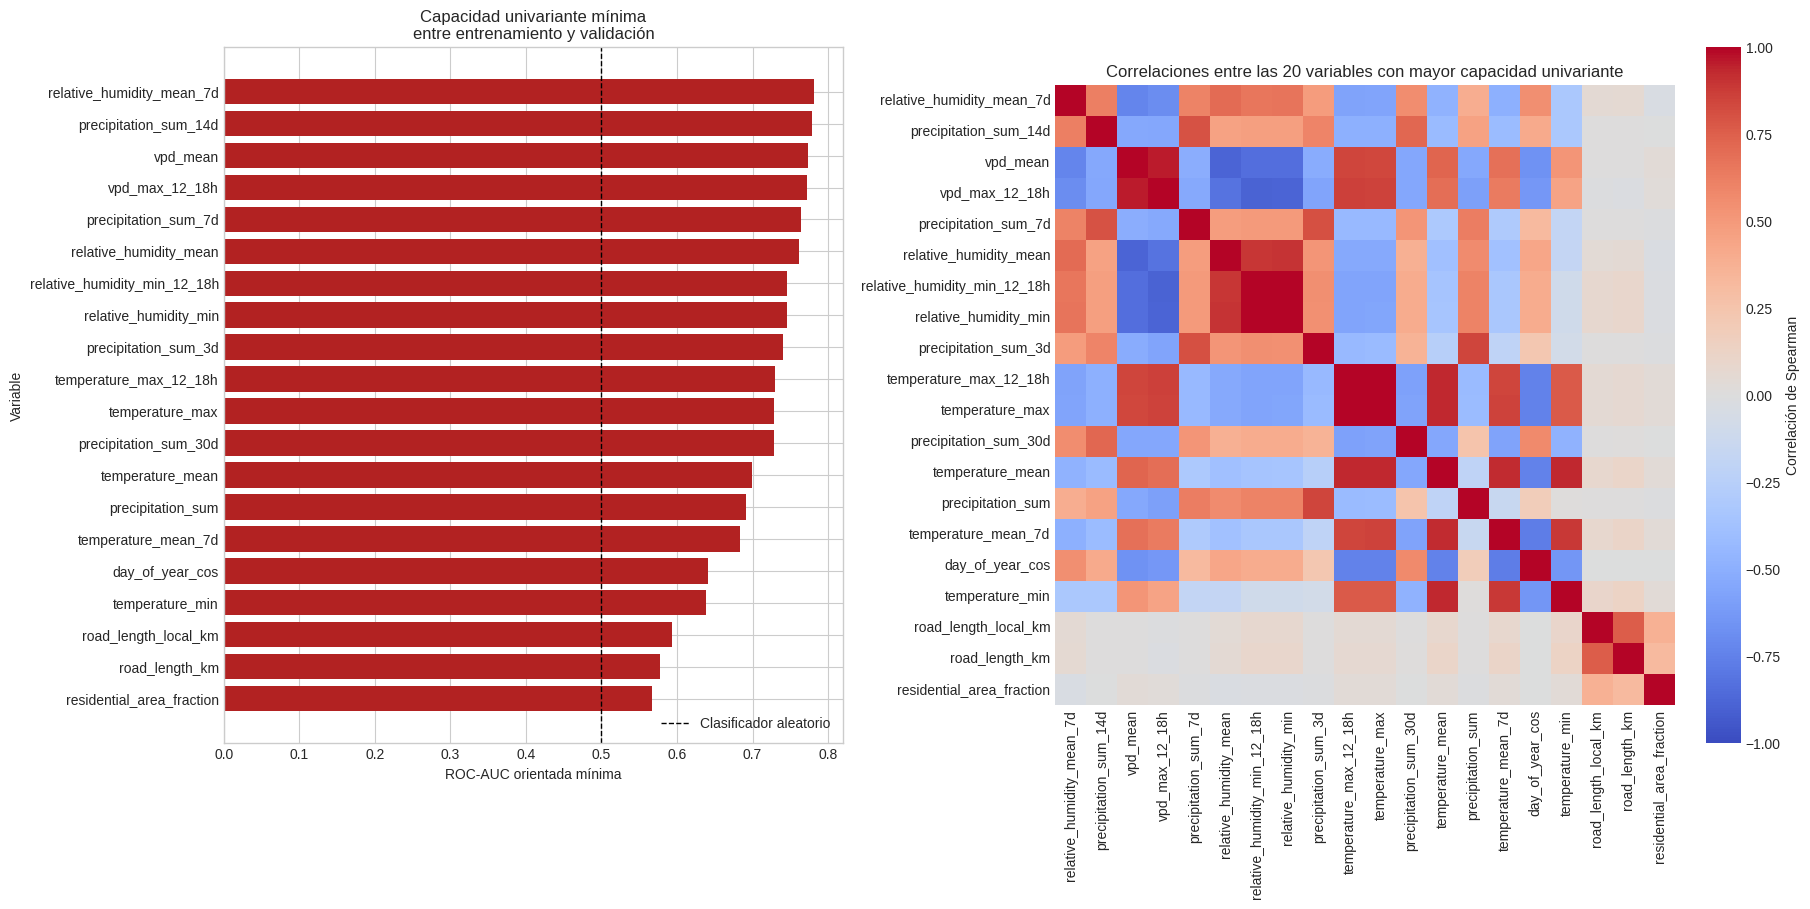


RANKING UNIVARIANTE


,univariate_rank,feature,direction,training_positive_mean,training_negative_mean,standardized_mean_difference,ks_statistic,training_oriented_auc,validation_oriented_auc,minimum_oriented_auc,auc_change_validation_minus_training,direction_preserved_in_validation,mutual_information
0,1,relative_humidity_mean_7d,lower → ignition,73.2028,81.5339,-1.1078,0.4618,0.7985,0.7809,0.7809,-0.0176,True,0.012027
1,2,precipitation_sum_14d,lower → ignition,24.2180,73.8481,-0.9862,0.4382,0.7822,0.7792,0.7792,-0.0031,True,0.011018
2,3,vpd_mean,higher → ignition,0.6562,0.3395,+0.9796,0.4414,0.7915,0.7738,0.7738,-0.0177,True,0.011476
3,4,vpd_max_12_18h,higher → ignition,1.4413,0.7746,+0.9846,0.4356,0.7853,0.7717,0.7717,-0.0136,True,0.010938
4,5,precipitation_sum_7d,lower → ignition,8.6516,37.0277,-0.9396,0.4272,0.7797,0.7647,0.7647,-0.0150,True,0.010597
5,6,relative_humidity_mean,lower → ignition,71.7468,81.5251,-1.0577,0.4191,0.7807,0.7610,0.7610,-0.0196,True,0.010648
6,7,relative_humidity_min_12_18h,lower → ignition,49.4665,64.0733,-1.0628,0.4098,0.7730,0.7459,0.7459,-0.0271,True,0.010044
7,8,relative_humidity_min,lower → ignition,49.3486,63.7189,-1.0631,0.4092,0.7732,0.7452,0.7452,-0.0280,True,0.010215
8,9,precipitation_sum_3d,lower → ignition,2.5701,15.8993,-0.8670,0.4219,0.7660,0.7398,0.7398,-0.0263,True,0.010837
9,10,temperature_max_12_18h,higher → ignition,21.7222,16.3512,+0.9134,0.3666,0.7408,0.7300,0.7300,-0.0108,True,0.008531



PARES CON |CORRELACIÓN DE SPEARMAN| ≥ 0,90


,feature_a,feature_b,spearman_correlation,absolute_correlation
0,temperature_max,temperature_max_12_18h,+0.9990,0.9990
1,relative_humidity_min,relative_humidity_min_12_18h,+0.9951,0.9951
2,wind_speed_max,wind_speed_max_12_18h,+0.9564,0.9564
3,vpd_mean,vpd_max_12_18h,+0.9536,0.9536
4,wind_speed_mean,wind_speed_max,+0.9520,0.9520
5,elevation_std,slope_mean,+0.9456,0.9456
6,temperature_mean,temperature_max,+0.9373,0.9373
7,temperature_mean,temperature_max_12_18h,+0.9350,0.9350
8,wind_speed_mean,wind_speed_max_12_18h,+0.9303,0.9303
9,temperature_mean,temperature_min,+0.9302,0.9302



Archivos guardados:
  Análisis:      /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/02_feature_selection/univariate_feature_analysis.csv
  Correlaciones: /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/02_feature_selection/spearman_correlation_matrix.csv
  Pares altos:   /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/02_feature_selection/high_correlation_pairs.csv
  Figura:        /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/figures/univariate_feature_analysis.png

✓ Análisis univariante terminado.
✓ Todavía no se ha realizado la selección definitiva.
✓ 2023 continúa fuera del análisis.


In [7]:
# =============================================================================
# 3.2. ANÁLISIS UNIVARIANTE Y CORRELACIONES
# =============================================================================

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import ks_2samp
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score

# -----------------------------------------------------------------------------
# 3.2.1. Recuperar muestras si fuera necesario
# -----------------------------------------------------------------------------

if "training_sample" not in globals():
    training_sample = pd.read_parquet(
        TRAIN_SAMPLE_PATH
    )

if "validation_sample" not in globals():
    validation_sample = pd.read_parquet(
        VALIDATION_SAMPLE_PATH
    )

X_train_analysis = training_sample[
    MODEL_CANDIDATE_PREDICTORS
]

X_validation_analysis = validation_sample[
    MODEL_CANDIDATE_PREDICTORS
]

y_train_analysis = (
    training_sample["target"]
    .to_numpy(dtype=np.uint8)
)

y_validation_analysis = (
    validation_sample["target"]
    .to_numpy(dtype=np.uint8)
)

print("=" * 80)
print("ANÁLISIS UNIVARIANTE")
print("=" * 80)

print(f"\nEntrenamiento: {len(training_sample):,} observaciones")
print(f"Validación:    {len(validation_sample):,} observaciones")
print(f"Predictores:   {len(MODEL_CANDIDATE_PREDICTORS)}")

# -----------------------------------------------------------------------------
# 3.2.2. Información mutua
# -----------------------------------------------------------------------------

MI_SAMPLE_SIZE = min(
    100_000,
    len(training_sample),
)

rng = np.random.default_rng(SEED)

mi_indices = rng.choice(
    len(training_sample),
    size=MI_SAMPLE_SIZE,
    replace=False,
)

X_mutual_information = (
    X_train_analysis
    .iloc[mi_indices]
    .to_numpy(dtype=np.float32)
)

y_mutual_information = (
    y_train_analysis[mi_indices]
)

print(
    f"\nCalculando información mutua con "
    f"{MI_SAMPLE_SIZE:,} observaciones..."
)

start = time.time()

mutual_information_values = mutual_info_classif(
    X_mutual_information,
    y_mutual_information,
    discrete_features=False,
    n_neighbors=3,
    random_state=SEED,
)

print(
    f"✓ Información mutua calculada en "
    f"{time.time() - start:.1f} s"
)

mutual_information_by_feature = dict(
    zip(
        MODEL_CANDIDATE_PREDICTORS,
        mutual_information_values,
    )
)

del X_mutual_information
del y_mutual_information

# -----------------------------------------------------------------------------
# 3.2.3. Métricas univariantes
# -----------------------------------------------------------------------------

univariate_rows = []

for number, feature in enumerate(
    MODEL_CANDIDATE_PREDICTORS,
    start=1,
):
    train_values = (
        X_train_analysis[feature]
        .to_numpy(dtype=np.float64)
    )

    validation_values = (
        X_validation_analysis[feature]
        .to_numpy(dtype=np.float64)
    )

    train_positive = train_values[
        y_train_analysis == 1
    ]

    train_negative = train_values[
        y_train_analysis == 0
    ]

    validation_positive = validation_values[
        y_validation_analysis == 1
    ]

    validation_negative = validation_values[
        y_validation_analysis == 0
    ]

    positive_mean = float(
        train_positive.mean()
    )

    negative_mean = float(
        train_negative.mean()
    )

    pooled_standard_deviation = np.sqrt(
        (
            train_positive.var(ddof=1)
            + train_negative.var(ddof=1)
        )
        / 2
    )

    if pooled_standard_deviation > 0:
        standardized_mean_difference = (
            positive_mean - negative_mean
        ) / pooled_standard_deviation
    else:
        standardized_mean_difference = 0.0

    ks_result = ks_2samp(
        train_positive,
        train_negative,
        alternative="two-sided",
        method="asymp",
    )

    raw_training_auc = roc_auc_score(
        y_train_analysis,
        train_values,
    )

    if raw_training_auc >= 0.5:
        direction = "higher → ignition"
        oriented_training_values = train_values
        oriented_validation_values = validation_values
    else:
        direction = "lower → ignition"
        oriented_training_values = -train_values
        oriented_validation_values = -validation_values

    oriented_training_auc = roc_auc_score(
        y_train_analysis,
        oriented_training_values,
    )

    oriented_validation_auc = roc_auc_score(
        y_validation_analysis,
        oriented_validation_values,
    )

    univariate_rows.append({
        "feature": feature,
        "direction": direction,
        "training_positive_mean":
            positive_mean,
        "training_negative_mean":
            negative_mean,
        "validation_positive_mean":
            float(validation_positive.mean()),
        "validation_negative_mean":
            float(validation_negative.mean()),
        "standardized_mean_difference":
            standardized_mean_difference,
        "ks_statistic":
            float(ks_result.statistic),
        "ks_p_value":
            float(ks_result.pvalue),
        "training_oriented_auc":
            float(oriented_training_auc),
        "validation_oriented_auc":
            float(oriented_validation_auc),
        "minimum_oriented_auc":
            float(min(
                oriented_training_auc,
                oriented_validation_auc,
            )),
        "auc_change_validation_minus_training":
            float(
                oriented_validation_auc
                - oriented_training_auc
            ),
        "direction_preserved_in_validation":
            bool(oriented_validation_auc >= 0.5),
        "mutual_information":
            float(
                mutual_information_by_feature[feature]
            ),
    })

    print(
        f"[{number:2d}/"
        f"{len(MODEL_CANDIDATE_PREDICTORS)}] "
        f"{feature}"
    )

univariate_analysis = pd.DataFrame(
    univariate_rows
)

univariate_analysis = (
    univariate_analysis
    .sort_values(
        [
            "minimum_oriented_auc",
            "mutual_information",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

univariate_analysis.insert(
    0,
    "univariate_rank",
    np.arange(
        1,
        len(univariate_analysis) + 1,
    ),
)

# -----------------------------------------------------------------------------
# 3.2.4. Correlaciones de Spearman
# -----------------------------------------------------------------------------

CORRELATION_SAMPLE_SIZE = min(
    100_000,
    len(training_sample),
)

correlation_indices = rng.choice(
    len(training_sample),
    size=CORRELATION_SAMPLE_SIZE,
    replace=False,
)

print(
    f"\nCalculando correlaciones de Spearman con "
    f"{CORRELATION_SAMPLE_SIZE:,} observaciones..."
)

start = time.time()

spearman_correlation = (
    X_train_analysis
    .iloc[correlation_indices]
    .corr(method="spearman")
)

print(
    f"✓ Correlaciones calculadas en "
    f"{time.time() - start:.1f} s"
)

high_correlation_rows = []

for row_index, feature_a in enumerate(
    MODEL_CANDIDATE_PREDICTORS
):
    for column_index in range(
        row_index + 1,
        len(MODEL_CANDIDATE_PREDICTORS),
    ):
        feature_b = (
            MODEL_CANDIDATE_PREDICTORS[
                column_index
            ]
        )

        correlation = float(
            spearman_correlation.loc[
                feature_a,
                feature_b,
            ]
        )

        if abs(correlation) >= 0.90:
            high_correlation_rows.append({
                "feature_a": feature_a,
                "feature_b": feature_b,
                "spearman_correlation":
                    correlation,
                "absolute_correlation":
                    abs(correlation),
            })

high_correlation_pairs = pd.DataFrame(
    high_correlation_rows
)

if not high_correlation_pairs.empty:
    high_correlation_pairs = (
        high_correlation_pairs
        .sort_values(
            "absolute_correlation",
            ascending=False,
        )
        .reset_index(drop=True)
    )

# -----------------------------------------------------------------------------
# 3.2.5. Guardar resultados
# -----------------------------------------------------------------------------

UNIVARIATE_PATH = (
    DIRECTORIES["feature_selection"] /
    "univariate_feature_analysis.csv"
)

CORRELATION_MATRIX_PATH = (
    DIRECTORIES["feature_selection"] /
    "spearman_correlation_matrix.csv"
)

HIGH_CORRELATIONS_PATH = (
    DIRECTORIES["feature_selection"] /
    "high_correlation_pairs.csv"
)

univariate_analysis.to_csv(
    UNIVARIATE_PATH,
    index=False,
)

spearman_correlation.to_csv(
    CORRELATION_MATRIX_PATH,
)

high_correlation_pairs.to_csv(
    HIGH_CORRELATIONS_PATH,
    index=False,
)

# -----------------------------------------------------------------------------
# 3.2.6. Figuras
# -----------------------------------------------------------------------------

top_features = (
    univariate_analysis
    .head(20)["feature"]
    .tolist()
)

top_univariate = (
    univariate_analysis
    .set_index("feature")
    .loc[top_features]
    .sort_values(
        "minimum_oriented_auc",
        ascending=True,
    )
)

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 9),
    constrained_layout=True,
)

# Ranking univariante.
axes[0].barh(
    top_univariate.index,
    top_univariate[
        "minimum_oriented_auc"
    ],
    color="firebrick",
)

axes[0].axvline(
    0.5,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Clasificador aleatorio",
)

axes[0].set_title(
    "Capacidad univariante mínima\n"
    "entre entrenamiento y validación"
)
axes[0].set_xlabel("ROC-AUC orientada mínima")
axes[0].set_ylabel("Variable")
axes[0].legend()

# Correlaciones entre las 20 primeras.
top_correlation_matrix = (
    spearman_correlation
    .loc[top_features, top_features]
)

sns.heatmap(
    top_correlation_matrix,
    ax=axes[1],
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    cbar_kws={
        "label": "Correlación de Spearman",
    },
)

axes[1].set_title(
    "Correlaciones entre las 20 variables "
    "con mayor capacidad univariante"
)

UNIVARIATE_FIGURE_PATH = (
    DIRECTORIES["figures"] /
    "univariate_feature_analysis.png"
)

figure.savefig(
    UNIVARIATE_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

# -----------------------------------------------------------------------------
# 3.2.7. Mostrar resultados
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("RANKING UNIVARIANTE")
print("=" * 80)

display_columns = [
    "univariate_rank",
    "feature",
    "direction",
    "training_positive_mean",
    "training_negative_mean",
    "standardized_mean_difference",
    "ks_statistic",
    "training_oriented_auc",
    "validation_oriented_auc",
    "minimum_oriented_auc",
    "auc_change_validation_minus_training",
    "direction_preserved_in_validation",
    "mutual_information",
]

display(
    univariate_analysis[
        display_columns
    ].style.format({
        "training_positive_mean": "{:.4f}",
        "training_negative_mean": "{:.4f}",
        "standardized_mean_difference": "{:+.4f}",
        "ks_statistic": "{:.4f}",
        "training_oriented_auc": "{:.4f}",
        "validation_oriented_auc": "{:.4f}",
        "minimum_oriented_auc": "{:.4f}",
        "auc_change_validation_minus_training":
            "{:+.4f}",
        "mutual_information": "{:.6f}",
    })
)

print("\n" + "=" * 80)
print("PARES CON |CORRELACIÓN DE SPEARMAN| ≥ 0,90")
print("=" * 80)

if high_correlation_pairs.empty:
    print(
        "No se han encontrado pares por encima "
        "del umbral."
    )
else:
    display(
        high_correlation_pairs.style.format({
            "spearman_correlation": "{:+.4f}",
            "absolute_correlation": "{:.4f}",
        })
    )

print("\nArchivos guardados:")
print(f"  Análisis:      {UNIVARIATE_PATH}")
print(f"  Correlaciones: {CORRELATION_MATRIX_PATH}")
print(f"  Pares altos:   {HIGH_CORRELATIONS_PATH}")
print(f"  Figura:        {UNIVARIATE_FIGURE_PATH}")

print("\n✓ Análisis univariante terminado.")
print("✓ Todavía no se ha realizado la selección definitiva.")
print("✓ 2023 continúa fuera del análisis.")

## Conclusiones del análisis univariante

Las variables meteorológicas presentan la mayor capacidad individual para diferenciar las celdas–día con ignición.

La variable con mejor comportamiento es `relative_humidity_mean_7d`, con una ROC-AUC orientada de 0,7985 en entrenamiento y 0,7809 en validación. Una humedad media reducida durante los siete días anteriores está asociada con un mayor riesgo de ignición.

Las acumulaciones de precipitación también muestran una señal importante. Destacan especialmente:

- `precipitation_sum_14d`;
- `precipitation_sum_7d`;
- `precipitation_sum_3d`;
- `precipitation_sum_30d`.

En todos los casos, una precipitación acumulada menor está relacionada con una mayor presencia de igniciones.

Las nuevas variables de déficit de presión de vapor presentan una capacidad predictiva elevada y estable:

- `vpd_mean` alcanza una ROC-AUC mínima de 0,7738;
- `vpd_max_12_18h` alcanza 0,7717.

Estos resultados respaldan su incorporación al datacubo definitivo. Sin embargo, ambas variables tienen una correlación de 0,9536, por lo que contienen información muy similar. En los conjuntos compactos se conservará inicialmente `vpd_mean`, que presenta un rendimiento univariante ligeramente superior.

Las variables de temperatura máxima también tienen una relación clara con el target, mientras que las variables de viento presentan una capacidad individual más reducida. La dirección observada para el viento no debe interpretarse causalmente, ya que puede estar condicionada por la estación, la precipitación y otras variables meteorológicas.

Entre las variables humanas destaca `road_length_local_km`, que presenta mayor capacidad univariante que la longitud viaria total. Esto sugiere que las vías locales pueden representar mejor la accesibilidad y la actividad humana asociada a las igniciones. La superficie residencial también conserva una señal moderada y estable.

La longitud de pistas tiene una capacidad univariante próxima a la aleatoria. No obstante, se mantendrá inicialmente porque podría aportar información mediante su interacción con la cobertura forestal o agrícola.

La mayor parte de los predictores topográficos, de orientación y de cobertura presentan poca capacidad cuando se utilizan individualmente. Esto no implica que deban eliminarse, ya que pueden caracterizar la susceptibilidad territorial mediante relaciones no lineales e interacciones.

También se detectan varios grupos con correlaciones superiores a 0,90:

- temperatura media, mínima y máxima;
- humedad media y mínima;
- diferentes medidas máximas del viento;
- VPD medio y máximo;
- elevación irregular y pendiente.

Para evitar un conjunto innecesariamente redundante, se construirá una versión compacta que conserve una representación de cada fenómeno físico. Esta selección se comparará con el conjunto completo mediante modelos multivariantes.

Las variables con una dirección que no se mantiene en validación presentan una señal univariante muy débil. No se eliminarán automáticamente por este motivo, pero tendrán menor prioridad en los conjuntos reducidos.

## 3.3. Selección multivariante de variables

El análisis univariante no permite detectar interacciones entre predictores. Por ello, se compararán varios conjuntos mediante HistGradientBoosting y XGBoost.

Se definen los siguientes conjuntos:

1. **Meteorología compacta:** variables meteorológicas actuales y acumuladas con redundancias reducidas.
2. **Top 12 univariante:** las doce variables con mayor capacidad individual.
3. **Entorno sin variables humanas:** topografía, orientación, cobertura y meteorología.
4. **Entorno con longitud viaria total:** incorpora longitud total, superficie residencial y superficie edificada.
5. **Entorno con vías desagregadas:** sustituye la longitud total por vías principales, locales y pistas.
6. **Vías desagregadas y calendario:** añade las dos variables estacionales cíclicas.
7. **Conjunto completo:** incluye los 48 predictores candidatos.

En los conjuntos compactos:

- se elimina una categoría de orientación y una de cobertura para evitar dependencias exactas;
- se conserva una representación reducida de temperatura, humedad, viento y VPD;
- se mantienen todas las acumulaciones de precipitación, ya que representan escalas temporales diferentes.

La comparación se realiza sobre la muestra de validación de 2022. La métrica principal es Average Precision y se complementa con ROC-AUC y recall dentro del 1% y 5% de observaciones con mayor puntuación.

Los resultados de esta fase son preliminares porque la validación está muestreada. Los conjuntos más prometedores deberán confirmarse sobre el año 2022 completo.

CONJUNTOS DE VARIABLES


,feature_set,number_of_features,features
0,meteorology_compact,13,"temperature_min, temperature_max_12_18h, tempe..."
1,top_12_univariate,12,"relative_humidity_mean_7d, precipitation_sum_1..."
2,environment_no_human,31,"elevation_mean, elevation_std, slope_mean, asp..."
3,compact_total_road,34,"elevation_mean, elevation_std, slope_mean, asp..."
4,compact_road_types,36,"elevation_mean, elevation_std, slope_mean, asp..."
5,compact_road_types_calendar,38,"elevation_mean, elevation_std, slope_mean, asp..."
6,complete,48,"elevation_mean, elevation_std, slope_mean, slo..."



COMPARACIÓN MULTIVARIANTE

Experimentos: 14
Entrenamiento: 204,000 filas
Validación:    84,609 filas
Prevalencia muestreada: 1.9608%

[1/14] hist_gradient_boosting + meteorology_compact
Variables: 13
  AP:         0.0867
  ROC-AUC:    0.8353
  Recall@1%:  7.72%
  Recall@5%:  27.00%

[2/14] hist_gradient_boosting + top_12_univariate
Variables: 12
  AP:         0.0769
  ROC-AUC:    0.8293
  Recall@1%:  6.03%
  Recall@5%:  23.09%

[3/14] hist_gradient_boosting + environment_no_human
Variables: 31
  AP:         0.1301
  ROC-AUC:    0.8596
  Recall@1%:  11.75%
  Recall@5%:  33.27%

[4/14] hist_gradient_boosting + compact_total_road
Variables: 34
  AP:         0.1357
  ROC-AUC:    0.8628
  Recall@1%:  11.63%
  Recall@5%:  34.06%

[5/14] hist_gradient_boosting + compact_road_types
Variables: 36
  AP:         0.1356
  ROC-AUC:    0.8670
  Recall@1%:  11.51%
  Recall@5%:  36.17%

[6/14] hist_gradient_boosting + compact_road_types_calendar
Variables: 38
  AP:         0.1322
  ROC-AUC:    0.8636

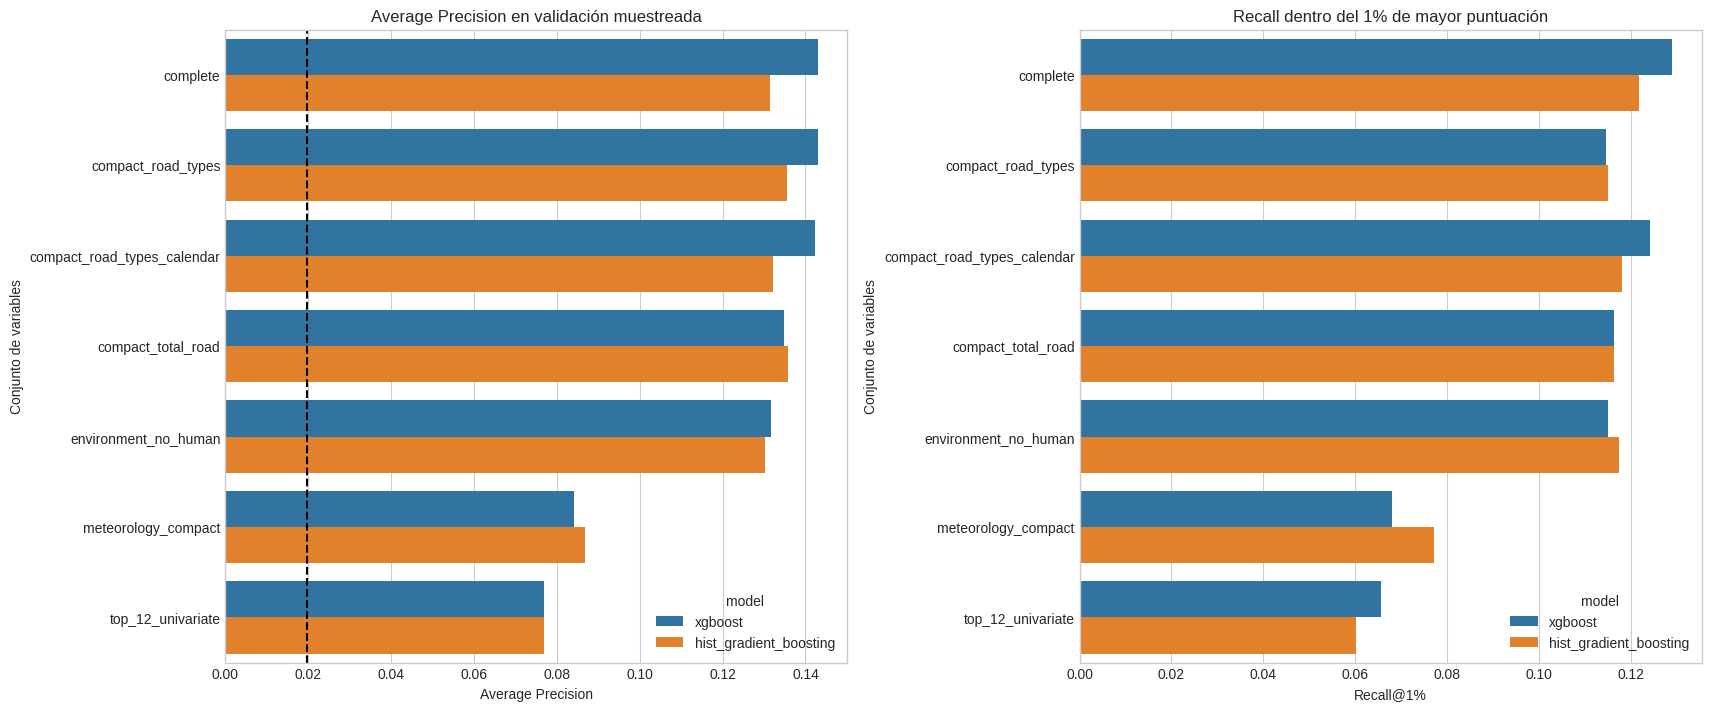


RESULTADOS DE SELECCIÓN MULTIVARIANTE


,rank_by_average_precision,model,feature_set,number_of_features,average_precision_sampled,ap_lift_over_random,roc_auc,recall_at_1pct,precision_at_1pct,recall_at_5pct,precision_at_5pct,training_seconds
0,1,xgboost,complete,48,0.1430,7.29×,0.8681,12.90%,25.30%,36.35%,14.26%,19.4
1,2,xgboost,compact_road_types,36,0.1429,7.29×,0.8669,11.45%,22.46%,35.93%,14.09%,12.9
2,3,xgboost,compact_road_types_calendar,38,0.1424,7.26×,0.8657,12.42%,24.35%,34.78%,13.64%,14.0
3,4,hist_gradient_boosting,compact_total_road,34,0.1357,6.92×,0.8628,11.63%,22.81%,34.06%,13.36%,10.5
4,5,hist_gradient_boosting,compact_road_types,36,0.1356,6.91×,0.8670,11.51%,22.58%,36.17%,14.18%,11.3
5,6,xgboost,compact_total_road,34,0.1348,6.88×,0.8660,11.63%,22.81%,35.08%,13.76%,14.6
6,7,hist_gradient_boosting,compact_road_types_calendar,38,0.1322,6.74×,0.8636,11.81%,23.17%,34.24%,13.43%,11.8
7,8,xgboost,environment_no_human,31,0.1316,6.71×,0.8601,11.51%,22.58%,34.42%,13.50%,13.1
8,9,hist_gradient_boosting,complete,48,0.1314,6.70×,0.8645,12.18%,23.88%,34.00%,13.33%,14.0
9,10,hist_gradient_boosting,environment_no_human,31,0.1301,6.64×,0.8596,11.75%,23.05%,33.27%,13.05%,8.7



Archivos guardados:
  Conjuntos:  /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/02_feature_selection/multivariate_feature_sets.json
  Resultados: /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/02_feature_selection/multivariate_feature_selection_results.csv
  Modelos:    /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/02_feature_selection/wrapper_models
  Figura:     /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/figures/multivariate_feature_set_comparison.png

✓ Comparación multivariante terminada.
✓ 2023 continúa fuera del análisis.


In [8]:
# =============================================================================
# 3.3. COMPARACIÓN MULTIVARIANTE DE CONJUNTOS DE VARIABLES
# =============================================================================

from pathlib import Path
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 3.3.1. Definición razonada de las familias
# -----------------------------------------------------------------------------

TOPOGRAPHY_COMPACT = [
    "elevation_mean",
    "elevation_std",
    "slope_mean",
]

# Se utiliza aspect_225_270_fraction como categoría de referencia.
ASPECT_COMPACT = [
    "aspect_000_045_fraction",
    "aspect_045_090_fraction",
    "aspect_090_135_fraction",
    "aspect_135_180_fraction",
    "aspect_180_225_fraction",
    "aspect_270_315_fraction",
    "aspect_315_360_fraction",
]

# Se utiliza wetlands como categoría de referencia.
LANDCOVER_COMPACT = [
    "artificial",
    "agriculture",
    "broadleaf_forest",
    "coniferous_forest",
    "mixed_forest",
    "scrub",
    "open_spaces",
    "water",
]

METEOROLOGY_COMPACT = [
    # Temperatura actual e histórica
    "temperature_min",
    "temperature_max_12_18h",
    "temperature_mean_7d",

    # Humedad actual e histórica
    "relative_humidity_mean",
    "relative_humidity_min_12_18h",
    "relative_humidity_mean_7d",

    # Viento
    "wind_speed_mean",

    # Déficit de presión de vapor
    "vpd_mean",

    # Precipitación en diferentes escalas
    "precipitation_sum",
    "precipitation_sum_3d",
    "precipitation_sum_7d",
    "precipitation_sum_14d",
    "precipitation_sum_30d",
]

HUMAN_TOTAL_ROAD = [
    "road_length_km",
    "residential_area_fraction",
    "building_area_fraction",
]

HUMAN_ROAD_TYPES = [
    "road_length_main_km",
    "road_length_local_km",
    "road_length_track_km",
    "residential_area_fraction",
    "building_area_fraction",
]

CALENDAR_COMPACT = [
    "day_of_year_sin",
    "day_of_year_cos",
]

ENVIRONMENT_NO_HUMAN = (
    TOPOGRAPHY_COMPACT
    + ASPECT_COMPACT
    + LANDCOVER_COMPACT
    + METEOROLOGY_COMPACT
)

top_12_univariate = (
    univariate_analysis
    .head(12)["feature"]
    .tolist()
)

FEATURE_SETS = {
    "meteorology_compact": (
        METEOROLOGY_COMPACT
    ),

    "top_12_univariate": (
        top_12_univariate
    ),

    "environment_no_human": (
        ENVIRONMENT_NO_HUMAN
    ),

    "compact_total_road": (
        ENVIRONMENT_NO_HUMAN
        + HUMAN_TOTAL_ROAD
    ),

    "compact_road_types": (
        ENVIRONMENT_NO_HUMAN
        + HUMAN_ROAD_TYPES
    ),

    "compact_road_types_calendar": (
        ENVIRONMENT_NO_HUMAN
        + HUMAN_ROAD_TYPES
        + CALENDAR_COMPACT
    ),

    "complete": (
        MODEL_CANDIDATE_PREDICTORS
    ),
}

# Comprobar duplicados y variables ausentes.
for feature_set_name, features in FEATURE_SETS.items():
    if len(features) != len(set(features)):
        raise ValueError(
            f"Hay variables duplicadas en {feature_set_name}."
        )

    missing = [
        feature
        for feature in features
        if feature not in MODEL_CANDIDATE_PREDICTORS
    ]

    if missing:
        raise KeyError(
            f"Variables ausentes en {feature_set_name}: {missing}"
        )

feature_set_rows = []

for feature_set_name, features in FEATURE_SETS.items():
    feature_set_rows.append({
        "feature_set": feature_set_name,
        "number_of_features": len(features),
        "features": ", ".join(features),
    })

feature_set_summary = pd.DataFrame(
    feature_set_rows
)

print("=" * 80)
print("CONJUNTOS DE VARIABLES")
print("=" * 80)

display(feature_set_summary)

# -----------------------------------------------------------------------------
# 3.3.2. Configuración de los modelos
# -----------------------------------------------------------------------------

MODEL_CONFIGURATIONS = {
    "hist_gradient_boosting": {
        "learning_rate": 0.05,
        "max_iter": 250,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 30,
        "l2_regularization": 0.1,
        "early_stopping": False,
        "random_state": SEED,
    },

    "xgboost": {
        "n_estimators": 400,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 5,
        "reg_lambda": 1.0,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
        "n_jobs": -1,
        "random_state": SEED,
    },
}


def create_selection_model(model_name):
    if model_name == "hist_gradient_boosting":
        return HistGradientBoostingClassifier(
            **MODEL_CONFIGURATIONS[model_name]
        )

    if model_name == "xgboost":
        return XGBClassifier(
            **MODEL_CONFIGURATIONS[model_name]
        )

    raise ValueError(
        f"Modelo desconocido: {model_name}"
    )


# -----------------------------------------------------------------------------
# 3.3.3. Función de evaluación
# -----------------------------------------------------------------------------

def evaluate_sampled_predictions(
    y_true,
    scores,
):
    prevalence = float(
        np.mean(y_true)
    )

    result = {
        "average_precision_sampled":
            float(
                average_precision_score(
                    y_true,
                    scores,
                )
            ),
        "roc_auc":
            float(
                roc_auc_score(
                    y_true,
                    scores,
                )
            ),
        "sampled_prevalence":
            prevalence,
    }

    result["ap_lift_over_random"] = (
        result["average_precision_sampled"]
        / prevalence
    )

    for fraction, suffix in [
        (0.01, "1pct"),
        (0.05, "5pct"),
    ]:
        number_selected = max(
            1,
            int(round(
                len(scores) * fraction
            )),
        )

        selected_indices = np.argpartition(
            scores,
            len(scores) - number_selected,
        )[-number_selected:]

        hits = int(
            y_true[selected_indices].sum()
        )

        total_positives = int(
            y_true.sum()
        )

        result[f"recall_at_{suffix}"] = (
            hits / total_positives
        )

        result[f"precision_at_{suffix}"] = (
            hits / number_selected
        )

        result[f"positives_at_{suffix}"] = hits

    return result


# -----------------------------------------------------------------------------
# 3.3.4. Entrenamiento
# -----------------------------------------------------------------------------

X_train_dataframe = training_sample[
    MODEL_CANDIDATE_PREDICTORS
]

X_validation_dataframe = validation_sample[
    MODEL_CANDIDATE_PREDICTORS
]

y_train_selection = (
    training_sample["target"]
    .to_numpy(dtype=np.uint8)
)

y_validation_selection = (
    validation_sample["target"]
    .to_numpy(dtype=np.uint8)
)

WRAPPER_MODEL_DIR = (
    DIRECTORIES["feature_selection"]
    / "wrapper_models"
)

WRAPPER_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

selection_results = []

experiment_order = []

for model_name in [
    "hist_gradient_boosting",
    "xgboost",
]:
    for feature_set_name in FEATURE_SETS:
        experiment_order.append(
            (model_name, feature_set_name)
        )

print("\n" + "=" * 80)
print("COMPARACIÓN MULTIVARIANTE")
print("=" * 80)

print(f"\nExperimentos: {len(experiment_order)}")
print(f"Entrenamiento: {len(training_sample):,} filas")
print(f"Validación:    {len(validation_sample):,} filas")
print(
    f"Prevalencia muestreada: "
    f"{y_validation_selection.mean():.4%}"
)

for experiment_number, (
    model_name,
    feature_set_name,
) in enumerate(
    experiment_order,
    start=1,
):
    features = FEATURE_SETS[
        feature_set_name
    ]

    X_train_current = (
        X_train_dataframe[features]
        .to_numpy(dtype=np.float32)
    )

    X_validation_current = (
        X_validation_dataframe[features]
        .to_numpy(dtype=np.float32)
    )

    print(
        f"\n[{experiment_number}/"
        f"{len(experiment_order)}] "
        f"{model_name} + {feature_set_name}"
    )
    print(f"Variables: {len(features)}")

    model = create_selection_model(
        model_name
    )

    start = time.time()

    model.fit(
        X_train_current,
        y_train_selection,
    )

    training_seconds = (
        time.time() - start
    )

    start = time.time()

    validation_scores = (
        model.predict_proba(
            X_validation_current
        )[:, 1]
    )

    prediction_seconds = (
        time.time() - start
    )

    metrics = evaluate_sampled_predictions(
        y_validation_selection,
        validation_scores,
    )

    selection_results.append({
        "model": model_name,
        "feature_set": feature_set_name,
        "number_of_features": len(features),
        **metrics,
        "training_seconds":
            training_seconds,
        "prediction_seconds":
            prediction_seconds,
    })

    model_path = (
        WRAPPER_MODEL_DIR
        / f"{model_name}_{feature_set_name}.joblib"
    )

    joblib.dump(
        {
            "model": model,
            "model_name": model_name,
            "feature_set": feature_set_name,
            "features": features,
            "configuration":
                MODEL_CONFIGURATIONS[model_name],
            "training_period": "2019–2021",
            "validation_period": "2022 sampled",
            "test_2023_used": False,
        },
        model_path,
        compress=3,
    )

    print(
        f"  AP:         "
        f"{metrics['average_precision_sampled']:.4f}"
    )
    print(
        f"  ROC-AUC:    "
        f"{metrics['roc_auc']:.4f}"
    )
    print(
        f"  Recall@1%:  "
        f"{metrics['recall_at_1pct']:.2%}"
    )
    print(
        f"  Recall@5%:  "
        f"{metrics['recall_at_5pct']:.2%}"
    )

    del model
    del X_train_current
    del X_validation_current
    del validation_scores

# -----------------------------------------------------------------------------
# 3.3.5. Guardar resultados
# -----------------------------------------------------------------------------

selection_results_df = pd.DataFrame(
    selection_results
)

selection_results_df = (
    selection_results_df
    .sort_values(
        [
            "average_precision_sampled",
            "recall_at_1pct",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

selection_results_df.insert(
    0,
    "rank_by_average_precision",
    np.arange(
        1,
        len(selection_results_df) + 1,
    ),
)

FEATURE_SETS_PATH = (
    DIRECTORIES["feature_selection"] /
    "multivariate_feature_sets.json"
)

SELECTION_RESULTS_PATH = (
    DIRECTORIES["feature_selection"] /
    "multivariate_feature_selection_results.csv"
)

with open(
    FEATURE_SETS_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            "feature_sets": FEATURE_SETS,
            "model_configurations":
                MODEL_CONFIGURATIONS,
            "primary_metric":
                "average_precision_sampled",
            "validation_period":
                "2022 sampled at 50 negatives per positive",
            "test_2023_used": False,
        },
        file,
        ensure_ascii=False,
        indent=2,
    )

selection_results_df.to_csv(
    SELECTION_RESULTS_PATH,
    index=False,
)

# -----------------------------------------------------------------------------
# 3.3.6. Visualización
# -----------------------------------------------------------------------------

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(17, 7),
    constrained_layout=True,
)

sns.barplot(
    data=selection_results_df,
    x="average_precision_sampled",
    y="feature_set",
    hue="model",
    ax=axes[0],
)

axes[0].axvline(
    y_validation_selection.mean(),
    color="black",
    linestyle="--",
    label="Clasificador aleatorio",
)

axes[0].set_title(
    "Average Precision en validación muestreada"
)
axes[0].set_xlabel("Average Precision")
axes[0].set_ylabel("Conjunto de variables")

sns.barplot(
    data=selection_results_df,
    x="recall_at_1pct",
    y="feature_set",
    hue="model",
    ax=axes[1],
)

axes[1].set_title(
    "Recall dentro del 1% de mayor puntuación"
)
axes[1].set_xlabel("Recall@1%")
axes[1].set_ylabel("Conjunto de variables")

MULTIVARIATE_FIGURE_PATH = (
    DIRECTORIES["figures"] /
    "multivariate_feature_set_comparison.png"
)

figure.savefig(
    MULTIVARIATE_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

# -----------------------------------------------------------------------------
# 3.3.7. Mostrar resultados
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("RESULTADOS DE SELECCIÓN MULTIVARIANTE")
print("=" * 80)

display_columns = [
    "rank_by_average_precision",
    "model",
    "feature_set",
    "number_of_features",
    "average_precision_sampled",
    "ap_lift_over_random",
    "roc_auc",
    "recall_at_1pct",
    "precision_at_1pct",
    "recall_at_5pct",
    "precision_at_5pct",
    "training_seconds",
]

display(
    selection_results_df[
        display_columns
    ].style.format({
        "average_precision_sampled": "{:.4f}",
        "ap_lift_over_random": "{:.2f}×",
        "roc_auc": "{:.4f}",
        "recall_at_1pct": "{:.2%}",
        "precision_at_1pct": "{:.2%}",
        "recall_at_5pct": "{:.2%}",
        "precision_at_5pct": "{:.2%}",
        "training_seconds": "{:.1f}",
    })
)

print("\nArchivos guardados:")
print(f"  Conjuntos:  {FEATURE_SETS_PATH}")
print(f"  Resultados: {SELECTION_RESULTS_PATH}")
print(f"  Modelos:    {WRAPPER_MODEL_DIR}")
print(f"  Figura:     {MULTIVARIATE_FIGURE_PATH}")

print("\n✓ Comparación multivariante terminada.")
print("✓ 2023 continúa fuera del análisis.")

## Conclusiones de la comparación multivariante

La comparación multivariante demuestra que seleccionar variables únicamente por su capacidad individual no es suficiente.

El conjunto de las doce mejores variables univariantes obtiene resultados inferiores incluso al conjunto meteorológico compacto. Esto ocurre porque muchas de las variables mejor posicionadas contienen información similar sobre temperatura, humedad y sequedad. La acumulación de predictores individualmente buenos pero redundantes no garantiza un modelo multivariante mejor.

La incorporación de variables estáticas produce una mejora importante. En XGBoost, la Average Precision aumenta desde 0,0840 con meteorología únicamente hasta 0,1316 al añadir topografía, orientación y cobertura del suelo. Este resultado confirma que las características territoriales aportan información complementaria, aunque su capacidad univariante sea reducida.

Las variables humanas también mejoran el rendimiento:

- el conjunto ambiental sin variables humanas obtiene una AP de 0,1316 con XGBoost;
- al añadir la longitud viaria total, la AP aumenta hasta 0,1348;
- al utilizar las vías desagregadas, aumenta hasta 0,1429.

La separación entre vías principales, locales y pistas resulta más informativa que utilizar solamente la longitud total. Con HistGradientBoosting, la desagregación también mejora el recall@5%, que pasa del 34,06% al 36,17%.

Las variables cíclicas de calendario no producen una mejora consistente. En XGBoost aumentan ligeramente el recall@1%, pero reducen Average Precision, ROC-AUC y recall@5%. En HistGradientBoosting también reducen la AP. Por tanto, no se incluirán inicialmente en el conjunto compacto.

Los mejores resultados corresponden a XGBoost:

- el conjunto completo de 48 variables alcanza una AP de 0,1430;
- el conjunto compacto con vías desagregadas alcanza 0,1429 utilizando solamente 36 variables.

La diferencia de AP entre ambos es prácticamente nula. El conjunto completo presenta un recall@1% superior, mientras que el compacto reduce un 25% el número de variables, elimina dependencias exactas y ofrece una interpretación más sencilla.

En HistGradientBoosting, los conjuntos compactos superan al conjunto completo en Average Precision. Esto indica que algunas variables adicionales pueden introducir ruido o redundancia.

Como resultado, se mantienen dos candidatos para las siguientes pruebas:

1. **Conjunto compacto de 36 variables con vías desagregadas**, como candidato principal por su equilibrio entre rendimiento, simplicidad e interpretabilidad.
2. **Conjunto completo de 48 variables**, como referencia para comprobar si la información adicional mejora el rendimiento sobre la validación completa.

Antes de tomar una decisión definitiva se analizará la importancia por permutación de las variables del conjunto compacto.

## 3.4. Importancia por permutación

La importancia por permutación mide cuánto disminuye el rendimiento de un modelo cuando se desordena una variable en el conjunto de validación.

Si la Average Precision disminuye, la variable contiene información utilizada por el modelo. Si apenas cambia o mejora, su aportación es pequeña, redundante o potencialmente perjudicial.

El análisis se realizará sobre el conjunto compacto de 36 variables y con dos modelos:

- HistGradientBoosting;
- XGBoost.

Además de permutar cada variable individualmente, se permutarán conjuntamente familias completas:

- topografía;
- orientación;
- cobertura del suelo;
- presencia humana;
- temperatura;
- humedad;
- viento;
- déficit de presión de vapor;
- precipitación.

La permutación por familias es importante porque los predictores correlacionados pueden repartirse la importancia. Una variable puede parecer poco relevante individualmente y pertenecer a una familia que sí sea necesaria.

La métrica utilizada será Average Precision sobre la validación muestreada de 2022. Las importancias se emplearán como apoyo para construir un conjunto reducido, no como único criterio de selección.

IMPORTANCIA POR PERMUTACIÓN

Variables:             36
Validación:            84,609 filas
Repeticiones:          7
Prevalencia muestreada: 1.9608%

hist_gradient_boosting
  AP de referencia: 0.135584
  Calculando permutaciones individuales...
  ✓ Terminado en 6.31 minutos

xgboost
  AP de referencia: 0.142932
  Calculando permutaciones individuales...
  ✓ Terminado en 3.05 minutos

Permutación por familias: hist_gradient_boosting
  [1/9] topography                 ΔAP=+0.034917
  [2/9] aspect                     ΔAP=+0.017523
  [3/9] landcover                  ΔAP=+0.024110
  [4/9] human_activity             ΔAP=+0.045159
  [5/9] temperature                ΔAP=+0.029375
  [6/9] humidity                   ΔAP=+0.045226
  [7/9] wind                       ΔAP=+0.009399
  [8/9] vapour_pressure_deficit    ΔAP=+0.008185
  [9/9] precipitation              ΔAP=+0.054615

Permutación por familias: xgboost
  [1/9] topography                 ΔAP=+0.040054
  [2/9] aspect                     ΔAP=+

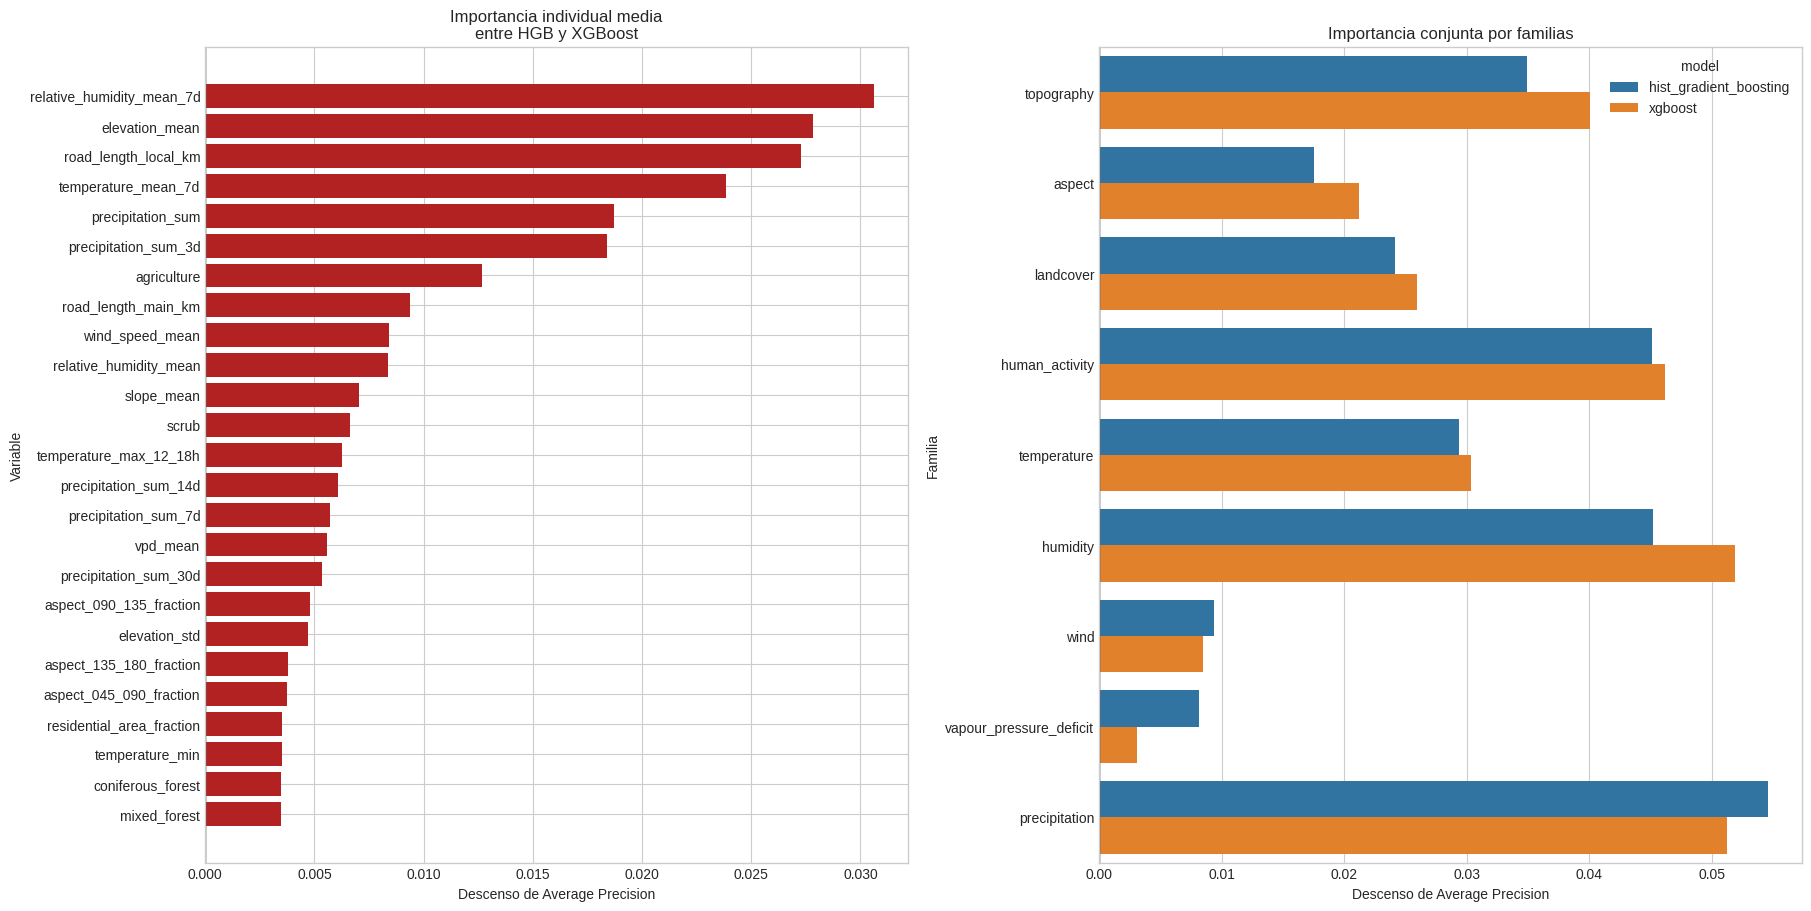


IMPORTANCIA INDIVIDUAL DE CONSENSO


,consensus_rank,feature,hist_gradient_boosting_ap_drop_mean,hist_gradient_boosting_ap_drop_std,xgboost_ap_drop_mean,xgboost_ap_drop_std,mean_ap_drop_across_models,positive_in_both_models
0,1,relative_humidity_mean_7d,+0.029407,0.001963,+0.031858,0.002586,+0.030632,True
1,2,elevation_mean,+0.026060,0.001774,+0.029616,0.001602,+0.027838,True
2,3,road_length_local_km,+0.027438,0.001898,+0.027160,0.001854,+0.027299,True
3,4,temperature_mean_7d,+0.023945,0.001772,+0.023764,0.001225,+0.023855,True
4,5,precipitation_sum,+0.017463,0.001446,+0.020000,0.003630,+0.018732,True
5,6,precipitation_sum_3d,+0.019885,0.001534,+0.016927,0.002043,+0.018406,True
6,7,agriculture,+0.012513,0.002255,+0.012848,0.002624,+0.012680,True
7,8,road_length_main_km,+0.010315,0.001353,+0.008426,0.001517,+0.009371,True
8,9,wind_speed_mean,+0.008639,0.001754,+0.008161,0.001247,+0.008400,True
9,10,relative_humidity_mean,+0.014267,0.002909,+0.002519,0.000980,+0.008393,True



IMPORTANCIA POR FAMILIAS


,model,family,number_of_features,features,baseline_average_precision,ap_drop_mean,ap_drop_std,ap_drop_min,ap_drop_max,relative_ap_drop,consistently_positive
8,hist_gradient_boosting,precipitation,5,"precipitation_sum, precipitation_sum_3d, precipitation_sum_7d, precipitation_sum_14d, precipitation_sum_30d",0.135584,+0.054615,0.001889,+0.052267,+0.056724,+40.28%,True
5,hist_gradient_boosting,humidity,3,"relative_humidity_mean, relative_humidity_min_12_18h, relative_humidity_mean_7d",0.135584,+0.045226,0.001672,+0.042409,+0.047414,+33.36%,True
3,hist_gradient_boosting,human_activity,5,"road_length_main_km, road_length_local_km, road_length_track_km, residential_area_fraction, building_area_fraction",0.135584,+0.045159,0.001821,+0.042207,+0.048121,+33.31%,True
0,hist_gradient_boosting,topography,3,"elevation_mean, elevation_std, slope_mean",0.135584,+0.034917,0.002127,+0.032445,+0.038523,+25.75%,True
4,hist_gradient_boosting,temperature,3,"temperature_min, temperature_max_12_18h, temperature_mean_7d",0.135584,+0.029375,0.001493,+0.027696,+0.032098,+21.67%,True
2,hist_gradient_boosting,landcover,8,"artificial, agriculture, broadleaf_forest, coniferous_forest, mixed_forest, scrub, open_spaces, water",0.135584,+0.024110,0.003477,+0.018128,+0.027624,+17.78%,True
1,hist_gradient_boosting,aspect,7,"aspect_000_045_fraction, aspect_045_090_fraction, aspect_090_135_fraction, aspect_135_180_fraction, aspect_180_225_fraction, aspect_270_315_fraction, aspect_315_360_fraction",0.135584,+0.017523,0.001268,+0.014931,+0.018726,+12.92%,True
6,hist_gradient_boosting,wind,1,wind_speed_mean,0.135584,+0.009399,0.001325,+0.007533,+0.011363,+6.93%,True
7,hist_gradient_boosting,vapour_pressure_deficit,1,vpd_mean,0.135584,+0.008185,0.002796,+0.004359,+0.012354,+6.04%,True
14,xgboost,humidity,3,"relative_humidity_mean, relative_humidity_min_12_18h, relative_humidity_mean_7d",0.142932,+0.051891,0.004189,+0.045493,+0.056845,+36.30%,True



Archivos guardados:
  Individual: /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/02_feature_selection/individual_permutation_importance.csv
  Familias:   /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/02_feature_selection/family_permutation_importance.csv
  Consenso:   /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/02_feature_selection/consensus_permutation_importance.csv
  Figura:     /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/figures/permutation_importance_compact_features.png

✓ Importancia por permutación terminada.
✓ 2023 continúa fuera del análisis.


In [9]:
# =============================================================================
# 3.4. IMPORTANCIA POR PERMUTACIÓN
# =============================================================================

import gc
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score

# -----------------------------------------------------------------------------
# 3.4.1. Configuración y carga de modelos
# -----------------------------------------------------------------------------

PERMUTATION_REPETITIONS = 7

COMPACT_FEATURES = FEATURE_SETS[
    "compact_road_types"
]

X_validation_compact = (
    validation_sample[COMPACT_FEATURES]
    .to_numpy(dtype=np.float32)
)

y_validation_permutation = (
    validation_sample["target"]
    .to_numpy(dtype=np.uint8)
)

MODEL_PATHS = {
    "hist_gradient_boosting": (
        WRAPPER_MODEL_DIR
        / "hist_gradient_boosting_compact_road_types.joblib"
    ),
    "xgboost": (
        WRAPPER_MODEL_DIR
        / "xgboost_compact_road_types.joblib"
    ),
}

loaded_models = {}

for model_name, model_path in MODEL_PATHS.items():
    if not model_path.exists():
        raise FileNotFoundError(
            f"No se encuentra el modelo: {model_path}"
        )

    checkpoint = joblib.load(
        model_path
    )

    loaded_models[model_name] = (
        checkpoint["model"]
    )

print("=" * 80)
print("IMPORTANCIA POR PERMUTACIÓN")
print("=" * 80)

print(f"\nVariables:             {len(COMPACT_FEATURES)}")
print(f"Validación:            {len(validation_sample):,} filas")
print(f"Repeticiones:          {PERMUTATION_REPETITIONS}")
print(
    f"Prevalencia muestreada: "
    f"{y_validation_permutation.mean():.4%}"
)

# -----------------------------------------------------------------------------
# 3.4.2. Importancia individual
# -----------------------------------------------------------------------------

individual_rows = []

for model_name, model in loaded_models.items():
    baseline_scores = (
        model.predict_proba(
            X_validation_compact
        )[:, 1]
    )

    baseline_ap = average_precision_score(
        y_validation_permutation,
        baseline_scores,
    )

    print(
        f"\n{model_name}"
        f"\n  AP de referencia: {baseline_ap:.6f}"
    )
    print("  Calculando permutaciones individuales...")

    start = time.time()

    importance = permutation_importance(
        estimator=model,
        X=X_validation_compact,
        y=y_validation_permutation,
        scoring="average_precision",
        n_repeats=PERMUTATION_REPETITIONS,
        random_state=SEED,
        n_jobs=-1,
    )

    elapsed = time.time() - start

    print(
        f"  ✓ Terminado en {elapsed / 60:.2f} minutos"
    )

    for feature_index, feature in enumerate(
        COMPACT_FEATURES
    ):
        drops = importance.importances[
            feature_index
        ]

        individual_rows.append({
            "model": model_name,
            "feature": feature,
            "baseline_average_precision":
                baseline_ap,
            "ap_drop_mean":
                float(drops.mean()),
            "ap_drop_std":
                float(drops.std(ddof=1)),
            "ap_drop_min":
                float(drops.min()),
            "ap_drop_max":
                float(drops.max()),
            "relative_ap_drop":
                float(
                    drops.mean() / baseline_ap
                ),
            "consistently_positive":
                bool(np.all(drops > 0)),
        })

    del importance
    del baseline_scores
    gc.collect()

individual_importance = pd.DataFrame(
    individual_rows
)

# -----------------------------------------------------------------------------
# 3.4.3. Importancia conjunta por familias
# -----------------------------------------------------------------------------

FEATURE_FAMILIES = {
    "topography": [
        "elevation_mean",
        "elevation_std",
        "slope_mean",
    ],

    "aspect": ASPECT_COMPACT,

    "landcover": LANDCOVER_COMPACT,

    "human_activity": HUMAN_ROAD_TYPES,

    "temperature": [
        "temperature_min",
        "temperature_max_12_18h",
        "temperature_mean_7d",
    ],

    "humidity": [
        "relative_humidity_mean",
        "relative_humidity_min_12_18h",
        "relative_humidity_mean_7d",
    ],

    "wind": [
        "wind_speed_mean",
    ],

    "vapour_pressure_deficit": [
        "vpd_mean",
    ],

    "precipitation": [
        "precipitation_sum",
        "precipitation_sum_3d",
        "precipitation_sum_7d",
        "precipitation_sum_14d",
        "precipitation_sum_30d",
    ],
}

family_features_flat = [
    feature
    for family_features in FEATURE_FAMILIES.values()
    for feature in family_features
]

if sorted(family_features_flat) != sorted(COMPACT_FEATURES):
    missing = sorted(
        set(COMPACT_FEATURES)
        - set(family_features_flat)
    )

    duplicated = [
        feature
        for feature in family_features_flat
        if family_features_flat.count(feature) > 1
    ]

    raise ValueError(
        "Las familias no cubren exactamente el conjunto compacto."
        f"\nAusentes: {missing}"
        f"\nDuplicadas: {sorted(set(duplicated))}"
    )

family_rows = []

for model_number, (
    model_name,
    model,
) in enumerate(
    loaded_models.items()
):
    baseline_scores = (
        model.predict_proba(
            X_validation_compact
        )[:, 1]
    )

    baseline_ap = average_precision_score(
        y_validation_permutation,
        baseline_scores,
    )

    print(
        f"\nPermutación por familias: {model_name}"
    )

    for family_number, (
        family_name,
        family_features,
    ) in enumerate(
        FEATURE_FAMILIES.items(),
        start=1,
    ):
        family_indices = [
            COMPACT_FEATURES.index(feature)
            for feature in family_features
        ]

        family_drops = []

        for repetition in range(
            PERMUTATION_REPETITIONS
        ):
            rng = np.random.default_rng(
                SEED
                + 1000 * (model_number + 1)
                + 100 * family_number
                + repetition
            )

            permutation = rng.permutation(
                len(X_validation_compact)
            )

            X_permuted = (
                X_validation_compact.copy()
            )

            X_permuted[:, family_indices] = (
                X_validation_compact[
                    permutation
                ][:, family_indices]
            )

            permuted_scores = (
                model.predict_proba(
                    X_permuted
                )[:, 1]
            )

            permuted_ap = average_precision_score(
                y_validation_permutation,
                permuted_scores,
            )

            family_drops.append(
                baseline_ap - permuted_ap
            )

            del X_permuted
            del permuted_scores

        family_drops = np.asarray(
            family_drops,
            dtype=float,
        )

        family_rows.append({
            "model": model_name,
            "family": family_name,
            "number_of_features":
                len(family_features),
            "features":
                ", ".join(family_features),
            "baseline_average_precision":
                baseline_ap,
            "ap_drop_mean":
                float(family_drops.mean()),
            "ap_drop_std":
                float(family_drops.std(ddof=1)),
            "ap_drop_min":
                float(family_drops.min()),
            "ap_drop_max":
                float(family_drops.max()),
            "relative_ap_drop":
                float(
                    family_drops.mean()
                    / baseline_ap
                ),
            "consistently_positive":
                bool(np.all(family_drops > 0)),
        })

        print(
            f"  [{family_number}/"
            f"{len(FEATURE_FAMILIES)}] "
            f"{family_name:<26} "
            f"ΔAP={family_drops.mean():+.6f}"
        )

family_importance = pd.DataFrame(
    family_rows
)

# -----------------------------------------------------------------------------
# 3.4.4. Importancia de consenso
# -----------------------------------------------------------------------------

importance_pivot_mean = (
    individual_importance
    .pivot(
        index="feature",
        columns="model",
        values="ap_drop_mean",
    )
)

importance_pivot_std = (
    individual_importance
    .pivot(
        index="feature",
        columns="model",
        values="ap_drop_std",
    )
)

consensus_importance = pd.DataFrame({
    "feature": COMPACT_FEATURES,
})

for model_name in loaded_models:
    consensus_importance[
        f"{model_name}_ap_drop_mean"
    ] = (
        consensus_importance["feature"]
        .map(
            importance_pivot_mean[
                model_name
            ]
        )
    )

    consensus_importance[
        f"{model_name}_ap_drop_std"
    ] = (
        consensus_importance["feature"]
        .map(
            importance_pivot_std[
                model_name
            ]
        )
    )

consensus_importance[
    "mean_ap_drop_across_models"
] = (
    consensus_importance[[
        f"{model_name}_ap_drop_mean"
        for model_name in loaded_models
    ]]
    .mean(axis=1)
)

consensus_importance[
    "positive_in_both_models"
] = np.logical_and.reduce([
    consensus_importance[
        f"{model_name}_ap_drop_mean"
    ] > 0
    for model_name in loaded_models
])

consensus_importance = (
    consensus_importance
    .sort_values(
        "mean_ap_drop_across_models",
        ascending=False,
    )
    .reset_index(drop=True)
)

consensus_importance.insert(
    0,
    "consensus_rank",
    np.arange(
        1,
        len(consensus_importance) + 1,
    ),
)

# -----------------------------------------------------------------------------
# 3.4.5. Guardar resultados
# -----------------------------------------------------------------------------

INDIVIDUAL_IMPORTANCE_PATH = (
    DIRECTORIES["feature_selection"] /
    "individual_permutation_importance.csv"
)

FAMILY_IMPORTANCE_PATH = (
    DIRECTORIES["feature_selection"] /
    "family_permutation_importance.csv"
)

CONSENSUS_IMPORTANCE_PATH = (
    DIRECTORIES["feature_selection"] /
    "consensus_permutation_importance.csv"
)

individual_importance.to_csv(
    INDIVIDUAL_IMPORTANCE_PATH,
    index=False,
)

family_importance.to_csv(
    FAMILY_IMPORTANCE_PATH,
    index=False,
)

consensus_importance.to_csv(
    CONSENSUS_IMPORTANCE_PATH,
    index=False,
)

# -----------------------------------------------------------------------------
# 3.4.6. Figuras
# -----------------------------------------------------------------------------

top_consensus = (
    consensus_importance
    .head(25)
    .sort_values(
        "mean_ap_drop_across_models",
        ascending=True,
    )
)

family_plot = (
    family_importance
    .copy()
)

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 9),
    constrained_layout=True,
)

axes[0].barh(
    top_consensus["feature"],
    top_consensus[
        "mean_ap_drop_across_models"
    ],
    color="firebrick",
)

axes[0].axvline(
    0,
    color="black",
    linewidth=1,
)

axes[0].set_title(
    "Importancia individual media\n"
    "entre HGB y XGBoost"
)
axes[0].set_xlabel(
    "Descenso de Average Precision"
)
axes[0].set_ylabel("Variable")

sns.barplot(
    data=family_plot,
    x="ap_drop_mean",
    y="family",
    hue="model",
    ax=axes[1],
)

axes[1].axvline(
    0,
    color="black",
    linewidth=1,
)

axes[1].set_title(
    "Importancia conjunta por familias"
)
axes[1].set_xlabel(
    "Descenso de Average Precision"
)
axes[1].set_ylabel("Familia")

PERMUTATION_FIGURE_PATH = (
    DIRECTORIES["figures"] /
    "permutation_importance_compact_features.png"
)

figure.savefig(
    PERMUTATION_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

# -----------------------------------------------------------------------------
# 3.4.7. Mostrar resultados
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("IMPORTANCIA INDIVIDUAL DE CONSENSO")
print("=" * 80)

display(
    consensus_importance.style.format({
        "hist_gradient_boosting_ap_drop_mean":
            "{:+.6f}",
        "hist_gradient_boosting_ap_drop_std":
            "{:.6f}",
        "xgboost_ap_drop_mean":
            "{:+.6f}",
        "xgboost_ap_drop_std":
            "{:.6f}",
        "mean_ap_drop_across_models":
            "{:+.6f}",
    })
)

print("\n" + "=" * 80)
print("IMPORTANCIA POR FAMILIAS")
print("=" * 80)

display(
    family_importance
    .sort_values(
        ["model", "ap_drop_mean"],
        ascending=[True, False],
    )
    .style.format({
        "baseline_average_precision":
            "{:.6f}",
        "ap_drop_mean": "{:+.6f}",
        "ap_drop_std": "{:.6f}",
        "ap_drop_min": "{:+.6f}",
        "ap_drop_max": "{:+.6f}",
        "relative_ap_drop": "{:+.2%}",
    })
)

print("\nArchivos guardados:")
print(f"  Individual: {INDIVIDUAL_IMPORTANCE_PATH}")
print(f"  Familias:   {FAMILY_IMPORTANCE_PATH}")
print(f"  Consenso:   {CONSENSUS_IMPORTANCE_PATH}")
print(f"  Figura:     {PERMUTATION_FIGURE_PATH}")

print("\n✓ Importancia por permutación terminada.")
print("✓ 2023 continúa fuera del análisis.")

## Conclusiones de la importancia por permutación

La importancia por permutación confirma que el conjunto compacto combina fuentes de información complementarias.

Las variables individuales más importantes son:

1. humedad relativa media durante siete días;
2. elevación media;
3. longitud de vías locales;
4. temperatura media durante siete días;
5. precipitación diaria;
6. precipitación acumulada durante tres días.

La presencia de `road_length_local_km` entre las tres variables más importantes confirma que la desagregación de las vías aporta información relevante. También resulta destacable que su importancia sea consistente tanto en HistGradientBoosting como en XGBoost.

La longitud de vías principales también presenta una aportación positiva. En cambio, la longitud de pistas tiene una importancia reducida en XGBoost, aunque mantiene una contribución positiva en HistGradientBoosting.

La importancia agrupada muestra que todas las familias contribuyen al modelo:

- precipitación y humedad son las familias meteorológicas más importantes;
- la actividad humana produce una reducción de AP superior al 32% cuando se permuta;
- la topografía también tiene una aportación elevada;
- temperatura, cobertura del suelo y orientación aportan información adicional;
- viento y VPD tienen una importancia menor, pero positiva y consistente.

La importancia del VPD es inferior a la observada en el análisis univariante. Esto se debe a que comparte información con temperatura y humedad. Aun así, su permutación reduce la AP en ambos modelos, por lo que se mantendrá en los siguientes conjuntos.

Las variables con menor importancia individual son:

- `water`;
- `open_spaces`;
- `artificial`;
- `aspect_315_360_fraction`;
- `road_length_track_km`;
- `building_area_fraction`.

La baja importancia individual no implica necesariamente que sus familias sean irrelevantes. Las variables correlacionadas pueden repartirse la información y algunas pueden ser útiles solamente en determinados subgrupos de observaciones.

Por esta razón no se eliminará ninguna familia completa. Se construirán dos conjuntos reducidos mediante umbrales conservadores y se compararán nuevamente con las 36 variables originales.

## 3.5. Comparación de conjuntos reducidos

A partir de la importancia media obtenida con HistGradientBoosting y XGBoost se construirán dos conjuntos adicionales:

- **Reduced 33:** elimina las variables cuyo descenso medio de Average Precision es inferior a 0,001.
- **Reduced 30:** utiliza un umbral más exigente de 0,0015.

Estos umbrales generan una reducción gradual y mantienen todas las familias principales de información.

Los tres conjuntos que se compararán son:

1. las 36 variables compactas;
2. el conjunto reducido de 33 variables;
3. el conjunto reducido de 30 variables.

La reducción solamente se aceptará si mantiene o mejora Average Precision y las métricas de recall. En caso contrario, se conservará el conjunto compacto de 36 variables.

Esta comparación continúa realizándose sobre la validación muestreada de 2022. La selección elegida deberá confirmarse posteriormente sobre el año completo.

CONJUNTOS REDUCIDOS

Umbral reduced_33: 0.0010
Variables conservadas: 33
Variables eliminadas:
  - artificial: +0.000453
  - open_spaces: +0.000114
  - water: +0.000099

Umbral reduced_30: 0.0015
Variables conservadas: 30
Variables eliminadas respecto a compact_36:
  - aspect_315_360_fraction: +0.001233
  - artificial: +0.000453
  - open_spaces: +0.000114
  - water: +0.000099
  - road_length_track_km: +0.001395
  - building_area_fraction: +0.001417

Tamaños finales:
  compact_36     : 36
  reduced_33     : 33
  reduced_30     : 30

COMPARACIÓN DE CONJUNTOS REDUCIDOS

[1/6] hist_gradient_boosting + compact_36
Variables: 36
  AP:        0.1356
  ROC-AUC:   0.8670
  Recall@1%: 11.51%
  Recall@5%: 36.17%

[2/6] hist_gradient_boosting + reduced_33
Variables: 33
  AP:        0.1331
  ROC-AUC:   0.8660
  Recall@1%: 11.21%
  Recall@5%: 35.26%

[3/6] hist_gradient_boosting + reduced_30
Variables: 30
  AP:        0.1353
  ROC-AUC:   0.8661
  Recall@1%: 11.69%
  Recall@5%: 34.54%

[4/6] xgboost +

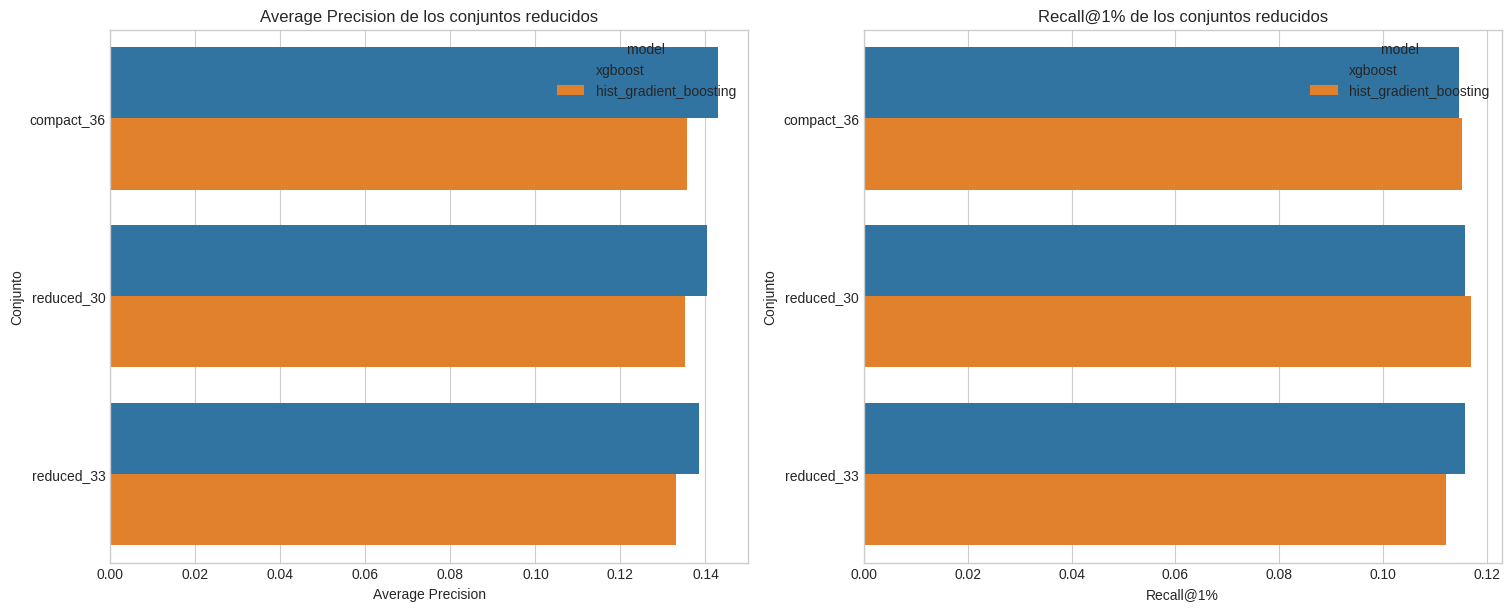


RESULTADOS DE LOS CONJUNTOS REDUCIDOS


,rank_by_average_precision,model,feature_set,number_of_features,average_precision_sampled,ap_lift_over_random,roc_auc,recall_at_1pct,recall_at_5pct,delta_average_precision_sampled_vs_compact_36,delta_recall_at_1pct_vs_compact_36,delta_recall_at_5pct_vs_compact_36,training_seconds
0,1,xgboost,compact_36,36,0.1429,7.29×,0.8669,11.45%,35.93%,+0.0000,+0.00%,+0.00%,12.6
1,2,xgboost,reduced_30,30,0.1404,7.16×,0.8666,11.57%,35.14%,-0.0025,+0.12%,-0.78%,11.5
2,3,xgboost,reduced_33,33,0.1385,7.06×,0.8660,11.57%,36.77%,-0.0045,+0.12%,+0.84%,12.2
3,4,hist_gradient_boosting,compact_36,36,0.1356,6.91×,0.8670,11.51%,36.17%,+0.0000,+0.00%,+0.00%,15.7
4,5,hist_gradient_boosting,reduced_30,30,0.1353,6.90×,0.8661,11.69%,34.54%,-0.0003,+0.18%,-1.63%,9.4
5,6,hist_gradient_boosting,reduced_33,33,0.1331,6.79×,0.8660,11.21%,35.26%,-0.0025,-0.30%,-0.90%,8.8



Archivos guardados:
  Conjuntos:  /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/02_feature_selection/reduced_feature_sets.json
  Resultados: /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/02_feature_selection/reduced_feature_selection_results.csv
  Modelos:    /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/02_feature_selection/reduced_models
  Figura:     /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/figures/reduced_feature_set_comparison.png

✓ Comparación de conjuntos reducidos terminada.
✓ 2023 continúa fuera del análisis.


In [10]:
# =============================================================================
# 3.5. COMPARACIÓN DE CONJUNTOS REDUCIDOS
# =============================================================================

import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# -----------------------------------------------------------------------------
# 3.5.1. Construcción automática de los conjuntos
# -----------------------------------------------------------------------------

importance_lookup = (
    consensus_importance
    .set_index("feature")[
        "mean_ap_drop_across_models"
    ]
)

REDUCED_THRESHOLD_33 = 0.001
REDUCED_THRESHOLD_30 = 0.0015

REDUCED_33_FEATURES = [
    feature
    for feature in COMPACT_FEATURES
    if importance_lookup.loc[feature]
    >= REDUCED_THRESHOLD_33
]

REDUCED_30_FEATURES = [
    feature
    for feature in COMPACT_FEATURES
    if importance_lookup.loc[feature]
    >= REDUCED_THRESHOLD_30
]

REDUCED_FEATURE_SETS = {
    "compact_36": COMPACT_FEATURES,
    "reduced_33": REDUCED_33_FEATURES,
    "reduced_30": REDUCED_30_FEATURES,
}

removed_for_33 = [
    feature
    for feature in COMPACT_FEATURES
    if feature not in REDUCED_33_FEATURES
]

removed_for_30 = [
    feature
    for feature in COMPACT_FEATURES
    if feature not in REDUCED_30_FEATURES
]

print("=" * 80)
print("CONJUNTOS REDUCIDOS")
print("=" * 80)

print(
    f"\nUmbral reduced_33: "
    f"{REDUCED_THRESHOLD_33:.4f}"
)
print(f"Variables conservadas: {len(REDUCED_33_FEATURES)}")
print("Variables eliminadas:")

for feature in removed_for_33:
    print(
        f"  - {feature}: "
        f"{importance_lookup.loc[feature]:+.6f}"
    )

print(
    f"\nUmbral reduced_30: "
    f"{REDUCED_THRESHOLD_30:.4f}"
)
print(f"Variables conservadas: {len(REDUCED_30_FEATURES)}")
print("Variables eliminadas respecto a compact_36:")

for feature in removed_for_30:
    print(
        f"  - {feature}: "
        f"{importance_lookup.loc[feature]:+.6f}"
    )

# Comprobar los tamaños esperados.
print("\nTamaños finales:")

for name, features in REDUCED_FEATURE_SETS.items():
    print(f"  {name:<15}: {len(features)}")

# -----------------------------------------------------------------------------
# 3.5.2. Entrenamiento y evaluación
# -----------------------------------------------------------------------------

reduced_results = []

REDUCED_MODEL_DIR = (
    DIRECTORIES["feature_selection"]
    / "reduced_models"
)

REDUCED_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

experiment_order = [
    (model_name, feature_set_name)
    for model_name in [
        "hist_gradient_boosting",
        "xgboost",
    ]
    for feature_set_name in REDUCED_FEATURE_SETS
]

print("\n" + "=" * 80)
print("COMPARACIÓN DE CONJUNTOS REDUCIDOS")
print("=" * 80)

for experiment_number, (
    model_name,
    feature_set_name,
) in enumerate(
    experiment_order,
    start=1,
):
    features = REDUCED_FEATURE_SETS[
        feature_set_name
    ]

    X_train_current = (
        training_sample[features]
        .to_numpy(dtype=np.float32)
    )

    X_validation_current = (
        validation_sample[features]
        .to_numpy(dtype=np.float32)
    )

    model = create_selection_model(
        model_name
    )

    print(
        f"\n[{experiment_number}/"
        f"{len(experiment_order)}] "
        f"{model_name} + {feature_set_name}"
    )
    print(f"Variables: {len(features)}")

    start = time.time()

    model.fit(
        X_train_current,
        y_train_selection,
    )

    training_seconds = (
        time.time() - start
    )

    start = time.time()

    validation_scores = (
        model.predict_proba(
            X_validation_current
        )[:, 1]
    )

    prediction_seconds = (
        time.time() - start
    )

    metrics = evaluate_sampled_predictions(
        y_validation_selection,
        validation_scores,
    )

    reduced_results.append({
        "model": model_name,
        "feature_set": feature_set_name,
        "number_of_features": len(features),
        **metrics,
        "training_seconds":
            training_seconds,
        "prediction_seconds":
            prediction_seconds,
    })

    model_path = (
        REDUCED_MODEL_DIR
        / f"{model_name}_{feature_set_name}.joblib"
    )

    joblib.dump(
        {
            "model": model,
            "model_name": model_name,
            "feature_set": feature_set_name,
            "features": features,
            "configuration":
                MODEL_CONFIGURATIONS[model_name],
            "training_period": "2019–2021",
            "validation_period": "2022 sampled",
            "test_2023_used": False,
        },
        model_path,
        compress=3,
    )

    print(
        f"  AP:        "
        f"{metrics['average_precision_sampled']:.4f}"
    )
    print(
        f"  ROC-AUC:   "
        f"{metrics['roc_auc']:.4f}"
    )
    print(
        f"  Recall@1%: "
        f"{metrics['recall_at_1pct']:.2%}"
    )
    print(
        f"  Recall@5%: "
        f"{metrics['recall_at_5pct']:.2%}"
    )

    del model
    del X_train_current
    del X_validation_current
    del validation_scores

# -----------------------------------------------------------------------------
# 3.5.3. Resultados y diferencias respecto a 36 variables
# -----------------------------------------------------------------------------

reduced_results_df = pd.DataFrame(
    reduced_results
)

metric_columns = [
    "average_precision_sampled",
    "roc_auc",
    "recall_at_1pct",
    "recall_at_5pct",
]

for model_name in reduced_results_df["model"].unique():
    baseline_row = reduced_results_df[
        (reduced_results_df["model"] == model_name)
        & (
            reduced_results_df["feature_set"]
            == "compact_36"
        )
    ].iloc[0]

    model_mask = (
        reduced_results_df["model"]
        == model_name
    )

    for metric in metric_columns:
        reduced_results_df.loc[
            model_mask,
            f"delta_{metric}_vs_compact_36",
        ] = (
            reduced_results_df.loc[
                model_mask,
                metric,
            ]
            - baseline_row[metric]
        )

reduced_results_df = (
    reduced_results_df
    .sort_values(
        [
            "average_precision_sampled",
            "recall_at_1pct",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

reduced_results_df.insert(
    0,
    "rank_by_average_precision",
    np.arange(
        1,
        len(reduced_results_df) + 1,
    ),
)

# -----------------------------------------------------------------------------
# 3.5.4. Guardar contrato y resultados
# -----------------------------------------------------------------------------

REDUCED_SETS_PATH = (
    DIRECTORIES["feature_selection"] /
    "reduced_feature_sets.json"
)

REDUCED_RESULTS_PATH = (
    DIRECTORIES["feature_selection"] /
    "reduced_feature_selection_results.csv"
)

with open(
    REDUCED_SETS_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            "compact_36": COMPACT_FEATURES,
            "reduced_33": REDUCED_33_FEATURES,
            "reduced_30": REDUCED_30_FEATURES,
            "threshold_reduced_33":
                REDUCED_THRESHOLD_33,
            "threshold_reduced_30":
                REDUCED_THRESHOLD_30,
            "importance_measure":
                "Mean validation AP drop across HGB and XGBoost",
            "test_2023_used": False,
        },
        file,
        ensure_ascii=False,
        indent=2,
    )

reduced_results_df.to_csv(
    REDUCED_RESULTS_PATH,
    index=False,
)

# -----------------------------------------------------------------------------
# 3.5.5. Figura
# -----------------------------------------------------------------------------

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 6),
    constrained_layout=True,
)

sns.barplot(
    data=reduced_results_df,
    x="average_precision_sampled",
    y="feature_set",
    hue="model",
    ax=axes[0],
)

axes[0].set_title(
    "Average Precision de los conjuntos reducidos"
)
axes[0].set_xlabel("Average Precision")
axes[0].set_ylabel("Conjunto")

sns.barplot(
    data=reduced_results_df,
    x="recall_at_1pct",
    y="feature_set",
    hue="model",
    ax=axes[1],
)

axes[1].set_title(
    "Recall@1% de los conjuntos reducidos"
)
axes[1].set_xlabel("Recall@1%")
axes[1].set_ylabel("Conjunto")

REDUCED_FIGURE_PATH = (
    DIRECTORIES["figures"] /
    "reduced_feature_set_comparison.png"
)

figure.savefig(
    REDUCED_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

# -----------------------------------------------------------------------------
# 3.5.6. Mostrar resultados
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("RESULTADOS DE LOS CONJUNTOS REDUCIDOS")
print("=" * 80)

display_columns = [
    "rank_by_average_precision",
    "model",
    "feature_set",
    "number_of_features",
    "average_precision_sampled",
    "ap_lift_over_random",
    "roc_auc",
    "recall_at_1pct",
    "recall_at_5pct",
    "delta_average_precision_sampled_vs_compact_36",
    "delta_recall_at_1pct_vs_compact_36",
    "delta_recall_at_5pct_vs_compact_36",
    "training_seconds",
]

display(
    reduced_results_df[
        display_columns
    ].style.format({
        "average_precision_sampled": "{:.4f}",
        "ap_lift_over_random": "{:.2f}×",
        "roc_auc": "{:.4f}",
        "recall_at_1pct": "{:.2%}",
        "recall_at_5pct": "{:.2%}",
        "delta_average_precision_sampled_vs_compact_36":
            "{:+.4f}",
        "delta_recall_at_1pct_vs_compact_36":
            "{:+.2%}",
        "delta_recall_at_5pct_vs_compact_36":
            "{:+.2%}",
        "training_seconds": "{:.1f}",
    })
)

print("\nArchivos guardados:")
print(f"  Conjuntos:  {REDUCED_SETS_PATH}")
print(f"  Resultados: {REDUCED_RESULTS_PATH}")
print(f"  Modelos:    {REDUCED_MODEL_DIR}")
print(f"  Figura:     {REDUCED_FIGURE_PATH}")

print("\n✓ Comparación de conjuntos reducidos terminada.")
print("✓ 2023 continúa fuera del análisis.")

## 2.X. Selección del conjunto definitivo de variables

Se compararon tres conjuntos derivados de la importancia por permutación:

- `compact_36`: conjunto compacto original de 36 variables.
- `reduced_33`: elimina las tres variables con menor importancia media.
- `reduced_30`: aplica una reducción más exigente y conserva 30 variables.

La evaluación se realizó sobre la muestra de validación de 2022 con HistGradientBoosting y XGBoost.

### Resultados principales

El conjunto `compact_36` obtuvo la mayor Average Precision con XGBoost:

- AP: 0,1429.
- ROC-AUC: 0,8669.
- Recall@1%: 11,45%.
- Recall@5%: 35,93%.

La reducción a 30 variables mantuvo un rendimiento próximo:

- En XGBoost, la AP descendió de 0,1429 a 0,1404.
- En HistGradientBoosting, la AP apenas cambió: de 0,1356 a 0,1353.
- El recall@1% aumentó ligeramente en ambos modelos.
- El recall@5% disminuyó en ambos modelos.

El conjunto de 33 variables no ofreció una mejora consistente. Aunque alcanzó el mayor recall@5% con XGBoost, presentó una reducción de AP en los dos algoritmos.

### Interpretación

Las variables con menor importancia individual no son necesariamente inútiles. Su eliminación simultánea puede modificar interacciones con otras variables y producir pequeñas pérdidas de rendimiento.

Esto explica que `reduced_30` conserve casi toda la capacidad predictiva, pero no supere de forma estable al conjunto de 36 variables. La diferencia de seis predictores tampoco representa una reducción suficientemente grande como para justificar una pérdida potencial de información antes de evaluar los modelos sobre la validación completa.

### Decisión metodológica

Se adopta `compact_36` como conjunto principal para las siguientes fases porque:

1. obtiene la mayor Average Precision;
2. mantiene un rendimiento equilibrado en las distintas métricas;
3. funciona de manera consistente con HistGradientBoosting y XGBoost;
4. conserva todas las familias de información consideradas relevantes;
5. evita realizar una reducción agresiva basándose únicamente en una muestra de validación.

El conjunto `reduced_30` se conservará como alternativa secundaria de menor complejidad. Podrá recuperarse si las evaluaciones completas muestran que ofrece un rendimiento equivalente.

Por tanto, la selección provisional queda definida como:

- conjunto principal: `compact_36`;
- conjunto reducido de referencia: `reduced_30`;
- conjunto completo de control: `complete`, con 48 variables.

Esta selección todavía es provisional. La decisión final dependerá de la evaluación sobre los 10.804.365 casos de 2022 y de la estabilidad temporal de los resultados.

# 4. Modelos baseline

Antes de entrenar modelos más complejos se establecen varios puntos de referencia sencillos. Su finalidad es determinar cuánto mejora el modelado multivariante respecto a estrategias elementales.

Se evaluarán tres baselines:

1. **Ranking aleatorio**: asigna una puntuación aleatoria reproducible a cada observación. Representa el rendimiento esperable sin información predictiva.
2. **Baseline univariante**: utiliza únicamente la humedad relativa media de los siete días anteriores. Esta fue la variable con mayor capacidad univariante estable.
3. **Regresión logística**: combina linealmente las 36 variables seleccionadas después de estandarizarlas.

Los modelos se evaluarán inicialmente sobre la muestra de validación de 2022. Se utilizarán Average Precision, ROC-AUC y recall dentro del 1% y del 5% de observaciones con mayor puntuación.

Debido al fuerte desequilibrio del problema, la Average Precision y las métricas de ranking tienen más relevancia operativa que la exactitud global.

MODELOS BASELINE
Entrenamiento:          (204000, 36)
Validación:             (84609, 36)
Variables seleccionadas:36
Positivos train:        4,000
Positivos validación:   1,659
Prevalencia muestreada: 1.9608%

Entrenando regresión logística...
✓ Entrenamiento: 2.3 s
✓ Predicción:    0.1 s

RESULTADOS DE LOS MODELOS BASELINE


,rank_by_average_precision,model,number_of_features,average_precision_sampled,ap_lift_over_random,roc_auc,recall_at_1pct,precision_at_1pct,positives_at_1pct,recall_at_5pct,precision_at_5pct,positives_at_5pct,training_seconds,prediction_seconds
0,1,logistic_regression,36,0.0939,4.79×,0.8402,8.62%,16.90%,143,26.94%,10.57%,447,2.257758,0.083398
1,2,univariate_rh_7d,1,0.0580,2.96×,0.7809,4.28%,8.39%,71,16.70%,6.55%,277,0.000000,0.000000
2,3,random_uniform,0,0.0191,0.97×,0.4924,0.90%,1.77%,15,3.80%,1.49%,63,0.000000,0.000000


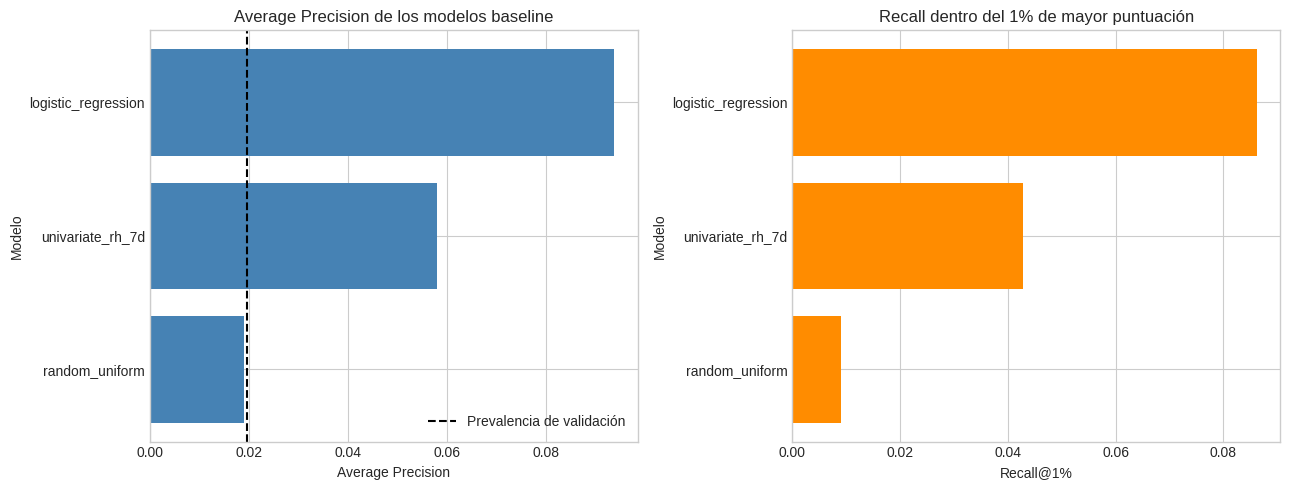


Archivos guardados:
  Resultados: /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/04_baselines/baseline_sampled_results.csv
  Modelo:     /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/04_baselines/logistic_regression_compact_36.joblib
  Scores:     /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/04_baselines/baseline_validation_scores.npz
  Contrato:   /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/04_baselines/baseline_contract.json
  Figura:     /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/figures/baseline_sampled_comparison.png

✓ Evaluación de modelos baseline terminada.
✓ 2023 continúa completamente fuera del análisis.


In [11]:
# =============================================================================
# MODELOS BASELINE
# =============================================================================

import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score


# -----------------------------------------------------------------------------
# 1. Rutas
# -----------------------------------------------------------------------------

FINAL_ROOT = Path(
    "/content/drive/MyDrive/TFM/ModelingResults/FinalNotebook"
)

FEATURE_SELECTION_DIR = FINAL_ROOT / "02_feature_selection"
BASELINE_DIR = FINAL_ROOT / "04_baselines"
FIGURE_DIR = FINAL_ROOT / "figures"

BASELINE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = (
    FEATURE_SELECTION_DIR
    / "training_sample_2019_2021_50to1.parquet"
)

VALIDATION_PATH = (
    FEATURE_SELECTION_DIR
    / "validation_sample_2022_50to1.parquet"
)

FEATURE_SETS_PATH = (
    FEATURE_SELECTION_DIR
    / "reduced_feature_sets.json"
)


# -----------------------------------------------------------------------------
# 2. Carga de datos y contrato de variables
# -----------------------------------------------------------------------------

print("=" * 80)
print("MODELOS BASELINE")
print("=" * 80)

training_sample = pd.read_parquet(TRAIN_PATH)
validation_sample = pd.read_parquet(VALIDATION_PATH)

with open(FEATURE_SETS_PATH, "r", encoding="utf-8") as file:
    reduced_feature_sets = json.load(file)

SELECTED_FEATURES = reduced_feature_sets["compact_36"]

missing_train = [
    feature for feature in SELECTED_FEATURES
    if feature not in training_sample.columns
]

missing_validation = [
    feature for feature in SELECTED_FEATURES
    if feature not in validation_sample.columns
]

if missing_train or missing_validation:
    raise ValueError(
        "Faltan predictores en las muestras.\n"
        f"Entrenamiento: {missing_train}\n"
        f"Validación: {missing_validation}"
    )

X_train = training_sample[SELECTED_FEATURES].to_numpy(
    dtype=np.float32
)

X_validation = validation_sample[SELECTED_FEATURES].to_numpy(
    dtype=np.float32
)

y_train = training_sample["target"].to_numpy(dtype=np.uint8)
y_validation = validation_sample["target"].to_numpy(dtype=np.uint8)

validation_prevalence = float(y_validation.mean())

print(f"Entrenamiento:          {X_train.shape}")
print(f"Validación:             {X_validation.shape}")
print(f"Variables seleccionadas:{len(SELECTED_FEATURES)}")
print(f"Positivos train:        {y_train.sum():,}")
print(f"Positivos validación:   {y_validation.sum():,}")
print(f"Prevalencia muestreada: {validation_prevalence:.4%}")


# -----------------------------------------------------------------------------
# 3. Funciones de evaluación
# -----------------------------------------------------------------------------

def ranking_metrics(y_true, scores, fraction):
    """
    Evalúa el subconjunto formado por la fracción de observaciones
    con mayor puntuación.
    """
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    number_selected = max(
        1,
        int(np.floor(len(y_true) * fraction))
    )

    selected_indices = np.argsort(scores)[-number_selected:]

    positives_selected = int(y_true[selected_indices].sum())
    total_positives = int(y_true.sum())

    recall = (
        positives_selected / total_positives
        if total_positives > 0 else np.nan
    )

    precision = positives_selected / number_selected

    return {
        "selected_cases": number_selected,
        "positive_cases": positives_selected,
        "recall": recall,
        "precision": precision,
    }


def evaluate_baseline(name, y_true, scores, training_seconds=0.0):
    """
    Calcula las métricas comunes de un baseline.
    """
    scores = np.asarray(scores, dtype=np.float64)

    top_1 = ranking_metrics(y_true, scores, 0.01)
    top_5 = ranking_metrics(y_true, scores, 0.05)

    average_precision = average_precision_score(y_true, scores)

    return {
        "model": name,
        "number_of_features": (
            0 if name == "random_uniform"
            else 1 if name == "univariate_rh_7d"
            else len(SELECTED_FEATURES)
        ),
        "average_precision_sampled": average_precision,
        "ap_lift_over_random": (
            average_precision / validation_prevalence
        ),
        "roc_auc": roc_auc_score(y_true, scores),
        "recall_at_1pct": top_1["recall"],
        "precision_at_1pct": top_1["precision"],
        "positives_at_1pct": top_1["positive_cases"],
        "recall_at_5pct": top_5["recall"],
        "precision_at_5pct": top_5["precision"],
        "positives_at_5pct": top_5["positive_cases"],
        "training_seconds": training_seconds,
    }


# -----------------------------------------------------------------------------
# 4. Baseline aleatorio
# -----------------------------------------------------------------------------

RANDOM_SEED = 42
random_generator = np.random.default_rng(RANDOM_SEED)

random_scores = random_generator.random(
    len(y_validation)
)

baseline_results = []
baseline_scores = {}

baseline_results.append(
    evaluate_baseline(
        name="random_uniform",
        y_true=y_validation,
        scores=random_scores,
    )
)

baseline_scores["random_uniform"] = random_scores.astype(
    np.float32
)


# -----------------------------------------------------------------------------
# 5. Baseline univariante
# -----------------------------------------------------------------------------

# Una humedad menor se asocia con un riesgo de ignición mayor.
univariate_feature = "relative_humidity_mean_7d"

univariate_scores = (
    -validation_sample[univariate_feature]
    .to_numpy(dtype=np.float32)
)

baseline_results.append(
    evaluate_baseline(
        name="univariate_rh_7d",
        y_true=y_validation,
        scores=univariate_scores,
    )
)

baseline_scores["univariate_rh_7d"] = univariate_scores


# -----------------------------------------------------------------------------
# 6. Regresión logística
# -----------------------------------------------------------------------------

logistic_model = Pipeline(
    steps=[
        (
            "standard_scaler",
            StandardScaler()
        ),
        (
            "logistic_regression",
            LogisticRegression(
                C=1.0,
                solver="lbfgs",
                max_iter=2000,
                random_state=RANDOM_SEED,
            )
        ),
    ]
)

print("\nEntrenando regresión logística...")
start_time = time.time()

logistic_model.fit(X_train, y_train)

logistic_training_seconds = time.time() - start_time

start_time = time.time()

logistic_scores = logistic_model.predict_proba(
    X_validation
)[:, 1]

logistic_prediction_seconds = time.time() - start_time

logistic_result = evaluate_baseline(
    name="logistic_regression",
    y_true=y_validation,
    scores=logistic_scores,
    training_seconds=logistic_training_seconds,
)

logistic_result["prediction_seconds"] = (
    logistic_prediction_seconds
)

baseline_results.append(logistic_result)

baseline_scores["logistic_regression"] = (
    logistic_scores.astype(np.float32)
)

print(
    f"✓ Entrenamiento: {logistic_training_seconds:.1f} s"
)
print(
    f"✓ Predicción:    {logistic_prediction_seconds:.1f} s"
)


# -----------------------------------------------------------------------------
# 7. Tabla de resultados
# -----------------------------------------------------------------------------

baseline_results = pd.DataFrame(baseline_results)

if "prediction_seconds" not in baseline_results.columns:
    baseline_results["prediction_seconds"] = 0.0

baseline_results["prediction_seconds"] = (
    baseline_results["prediction_seconds"].fillna(0.0)
)

baseline_results = baseline_results.sort_values(
    "average_precision_sampled",
    ascending=False,
).reset_index(drop=True)

baseline_results.insert(
    0,
    "rank_by_average_precision",
    np.arange(1, len(baseline_results) + 1),
)

print("\n" + "=" * 80)
print("RESULTADOS DE LOS MODELOS BASELINE")
print("=" * 80)

display_table = baseline_results.copy()

display_table["average_precision_sampled"] = (
    display_table["average_precision_sampled"]
    .map(lambda value: f"{value:.4f}")
)

display_table["ap_lift_over_random"] = (
    display_table["ap_lift_over_random"]
    .map(lambda value: f"{value:.2f}×")
)

display_table["roc_auc"] = (
    display_table["roc_auc"]
    .map(lambda value: f"{value:.4f}")
)

for column in [
    "recall_at_1pct",
    "precision_at_1pct",
    "recall_at_5pct",
    "precision_at_5pct",
]:
    display_table[column] = (
        display_table[column]
        .map(lambda value: f"{value:.2%}")
    )

display(display_table)


# -----------------------------------------------------------------------------
# 8. Guardado de resultados
# -----------------------------------------------------------------------------

RESULTS_PATH = BASELINE_DIR / "baseline_sampled_results.csv"
MODEL_PATH = BASELINE_DIR / "logistic_regression_compact_36.joblib"
SCORES_PATH = BASELINE_DIR / "baseline_validation_scores.npz"
CONTRACT_PATH = BASELINE_DIR / "baseline_contract.json"

baseline_results.to_csv(RESULTS_PATH, index=False)
joblib.dump(logistic_model, MODEL_PATH)

np.savez_compressed(
    SCORES_PATH,
    y_true=y_validation,
    random_uniform=baseline_scores["random_uniform"],
    univariate_rh_7d=baseline_scores["univariate_rh_7d"],
    logistic_regression=baseline_scores["logistic_regression"],
)

baseline_contract = {
    "training_period": "2019-01-01/2021-12-31",
    "validation_period": "2022-01-01/2022-12-31",
    "test_2023_used": False,
    "training_sample_rows": int(len(training_sample)),
    "validation_sample_rows": int(len(validation_sample)),
    "validation_prevalence": validation_prevalence,
    "selected_feature_set": "compact_36",
    "selected_features": SELECTED_FEATURES,
    "random_seed": RANDOM_SEED,
    "baselines": {
        "random_uniform": {
            "description": (
                "Puntuaciones aleatorias continuas con semilla fija."
            )
        },
        "univariate_rh_7d": {
            "feature": univariate_feature,
            "orientation": "lower_values_indicate_higher_risk",
        },
        "logistic_regression": {
            "standardization": True,
            "C": 1.0,
            "solver": "lbfgs",
            "max_iter": 2000,
            "class_weight": None,
        },
    },
}

with open(CONTRACT_PATH, "w", encoding="utf-8") as file:
    json.dump(
        baseline_contract,
        file,
        indent=2,
        ensure_ascii=False,
    )


# -----------------------------------------------------------------------------
# 9. Figura
# -----------------------------------------------------------------------------

plot_data = baseline_results.sort_values(
    "average_precision_sampled",
    ascending=True,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

axes[0].barh(
    plot_data["model"],
    plot_data["average_precision_sampled"],
    color="steelblue",
)

axes[0].axvline(
    validation_prevalence,
    color="black",
    linestyle="--",
    label="Prevalencia de validación",
)

axes[0].set_title("Average Precision de los modelos baseline")
axes[0].set_xlabel("Average Precision")
axes[0].set_ylabel("Modelo")
axes[0].legend()

axes[1].barh(
    plot_data["model"],
    plot_data["recall_at_1pct"],
    color="darkorange",
)

axes[1].set_title(
    "Recall dentro del 1% de mayor puntuación"
)
axes[1].set_xlabel("Recall@1%")
axes[1].set_ylabel("Modelo")

plt.tight_layout()

FIGURE_PATH = (
    FIGURE_DIR / "baseline_sampled_comparison.png"
)

plt.savefig(
    FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# -----------------------------------------------------------------------------
# 10. Resumen
# -----------------------------------------------------------------------------

print("\nArchivos guardados:")
print(f"  Resultados: {RESULTS_PATH}")
print(f"  Modelo:     {MODEL_PATH}")
print(f"  Scores:     {SCORES_PATH}")
print(f"  Contrato:   {CONTRACT_PATH}")
print(f"  Figura:     {FIGURE_PATH}")

print("\n✓ Evaluación de modelos baseline terminada.")
print("✓ 2023 continúa completamente fuera del análisis.")

## 4.1. Resultados de los modelos baseline

Los tres modelos baseline presentan una progresión clara a medida que se incorpora información predictiva.

El ranking aleatorio obtuvo una Average Precision de 0,0191, prácticamente igual a la prevalencia de la muestra de validación (1,9608%), y un ROC-AUC de 0,4924. Estos resultados son compatibles con un clasificador sin capacidad discriminativa. Las pequeñas diferencias respecto al valor teórico se deben a la variabilidad del ranking aleatorio.

La humedad relativa media de los siete días anteriores mostró capacidad predictiva incluso utilizada de forma aislada:

- Average Precision: 0,0580.
- Lift sobre el ranking aleatorio: 2,96.
- ROC-AUC: 0,7809.
- Recall@1%: 4,28%.
- Recall@5%: 16,70%.

Esto confirma que la humedad acumulada constituye uno de los principales indicadores meteorológicos del riesgo de ignición. Sin embargo, una sola variable resulta insuficiente para representar la interacción entre meteorología, topografía, cobertura del suelo y actividad humana.

La regresión logística obtuvo los mejores resultados de esta sección:

- Average Precision: 0,0939.
- Lift sobre el ranking aleatorio: 4,79.
- ROC-AUC: 0,8402.
- Recall@1%: 8,62%.
- Recall@5%: 26,94%.

Dentro del 1% de observaciones con mayor puntuación, la regresión logística identificó 143 de los 1.659 positivos de validación. En el top 5% identificó 447 positivos.

La regresión logística incrementó la Average Precision aproximadamente un 62% respecto al baseline univariante y duplicó su recall dentro del top 1%. Esto demuestra que la combinación de distintas familias de predictores contiene información complementaria.

No obstante, sus resultados permanecen por debajo de los obtenidos durante la selección de variables con los modelos basados en árboles. Esto indica que existen relaciones no lineales e interacciones que un modelo lineal no puede representar completamente.

Estos resultados establecen tres referencias para las siguientes fases:

- AP aleatoria aproximada: 0,0196.
- AP del mejor predictor individual: 0,0580.
- AP del baseline multivariante lineal: 0,0939.

Las métricas corresponden a una validación muestreada con una proporción de 50 negativos por positivo. Por tanto, sus valores absolutos no representan el rendimiento bajo la prevalencia real de 2022. Su finalidad en esta fase es comparar modelos bajo las mismas condiciones.

## 4.1. Resultados de los modelos baseline

Los tres modelos baseline presentan una progresión clara a medida que se incorpora información predictiva.

El ranking aleatorio obtuvo una Average Precision de 0,0191, prácticamente igual a la prevalencia de la muestra de validación (1,9608%), y un ROC-AUC de 0,4924. Estos resultados son compatibles con un clasificador sin capacidad discriminativa. Las pequeñas diferencias respecto al valor teórico se deben a la variabilidad del ranking aleatorio.

La humedad relativa media de los siete días anteriores mostró capacidad predictiva incluso utilizada de forma aislada:

- Average Precision: 0,0580.
- Lift sobre el ranking aleatorio: 2,96.
- ROC-AUC: 0,7809.
- Recall@1%: 4,28%.
- Recall@5%: 16,70%.

Esto confirma que la humedad acumulada constituye uno de los principales indicadores meteorológicos del riesgo de ignición. Sin embargo, una sola variable resulta insuficiente para representar la interacción entre meteorología, topografía, cobertura del suelo y actividad humana.

La regresión logística obtuvo los mejores resultados de esta sección:

- Average Precision: 0,0939.
- Lift sobre el ranking aleatorio: 4,79.
- ROC-AUC: 0,8402.
- Recall@1%: 8,62%.
- Recall@5%: 26,94%.

Dentro del 1% de observaciones con mayor puntuación, la regresión logística identificó 143 de los 1.659 positivos de validación. En el top 5% identificó 447 positivos.

La regresión logística incrementó la Average Precision aproximadamente un 62% respecto al baseline univariante y duplicó su recall dentro del top 1%. Esto demuestra que la combinación de distintas familias de predictores contiene información complementaria.

No obstante, sus resultados permanecen por debajo de los obtenidos durante la selección de variables con los modelos basados en árboles. Esto indica que existen relaciones no lineales e interacciones que un modelo lineal no puede representar completamente.

Estos resultados establecen tres referencias para las siguientes fases:

- AP aleatoria aproximada: 0,0196.
- AP del mejor predictor individual: 0,0580.
- AP del baseline multivariante lineal: 0,0939.

Las métricas corresponden a una validación muestreada con una proporción de 50 negativos por positivo. Por tanto, sus valores absolutos no representan el rendimiento bajo la prevalencia real de 2022. Su finalidad en esta fase es comparar modelos bajo las mismas condiciones.

COMPARACIÓN DE MODELOS CLÁSICOS
Entrenamiento:       204,000 filas
Validación:          84,609 filas
Variables:           36
Positivos train:     4,000
Positivos validación:1,659
Modelos:             3

[1/3] random_forest
  Entrenamiento: 313.6 s
  Predicción:    2.2 s
  AP:            0.1011
  ROC-AUC:       0.8410
  Recall@1%:     8.62%
  Recall@5%:     29.36%

[2/3] hist_gradient_boosting
  Entrenamiento: 11.9 s
  Predicción:    1.6 s
  AP:            0.1356
  ROC-AUC:       0.8670
  Recall@1%:     11.51%
  Recall@5%:     36.17%

[3/3] xgboost
  Entrenamiento: 12.5 s
  Predicción:    0.6 s
  AP:            0.1429
  ROC-AUC:       0.8669
  Recall@1%:     11.45%
  Recall@5%:     35.93%

RESULTADOS DE LOS MODELOS CLÁSICOS


,rank_by_average_precision,model,number_of_features,average_precision_sampled,ap_lift_over_random,roc_auc,recall_at_1pct,precision_at_1pct,positives_at_1pct,recall_at_5pct,precision_at_5pct,positives_at_5pct,training_seconds,prediction_seconds
0,1,xgboost,36,0.1429,7.29×,0.8669,11.45%,22.46%,190,35.93%,14.09%,596,12.520877,0.553436
1,2,hist_gradient_boosting,36,0.1356,6.91×,0.8670,11.51%,22.58%,191,36.17%,14.18%,600,11.864985,1.562958
2,3,random_forest,36,0.1011,5.15×,0.8410,8.62%,16.90%,143,29.36%,11.51%,487,313.640786,2.194585
3,4,logistic_regression,36,0.0939,4.79×,0.8402,8.62%,16.90%,143,26.94%,10.57%,447,2.257758,0.083398


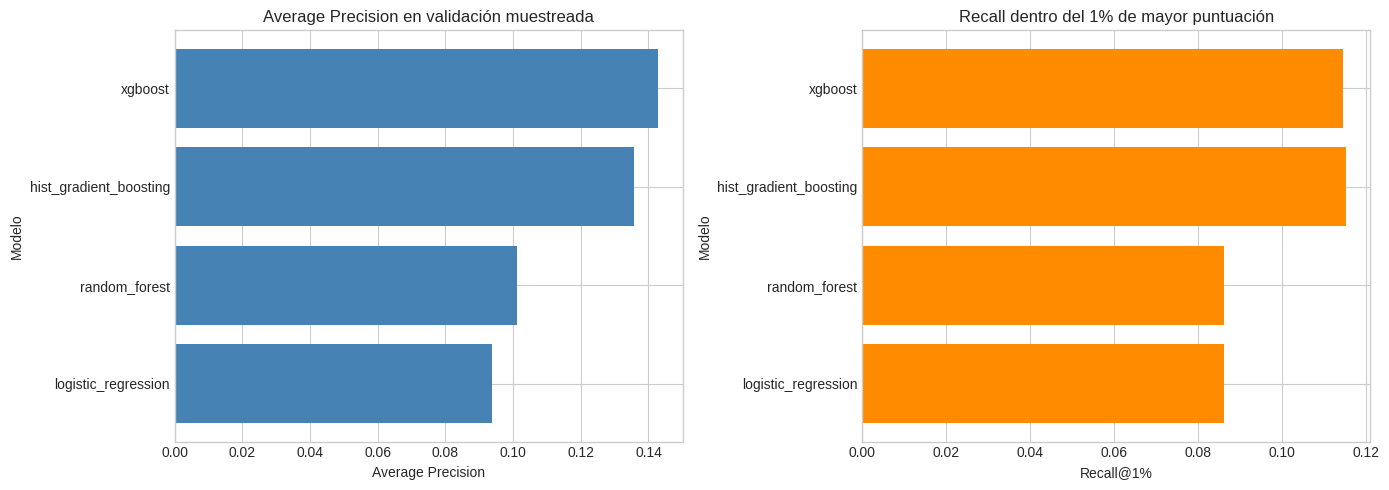


MEJOR MODELO EN VALIDACIÓN MUESTREADA
Modelo:       xgboost
AP:           0.1429
ROC-AUC:      0.8669
Recall@1%:    11.45%
Recall@5%:    35.93%

Archivos guardados:
  Resultados: /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/05_classical_models/classical_models_sampled_results.csv
  Modelos:    /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/05_classical_models/models
  Scores:     /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/05_classical_models/classical_models_validation_scores.npz
  Contrato:   /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/05_classical_models/classical_models_contract.json
  Figura:     /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/figures/classical_models_sampled_comparison.png

✓ Comparación de modelos clásicos terminada.
✓ 2023 continúa completamente fuera del análisis.


In [12]:
# =============================================================================
# COMPARACIÓN DE MODELOS CLÁSICOS
# =============================================================================

import json
import time
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

warnings.filterwarnings("ignore")


# -----------------------------------------------------------------------------
# 1. Rutas
# -----------------------------------------------------------------------------

FINAL_ROOT = Path(
    "/content/drive/MyDrive/TFM/ModelingResults/FinalNotebook"
)

BASELINE_DIR = FINAL_ROOT / "04_baselines"
CLASSICAL_DIR = FINAL_ROOT / "05_classical_models"
MODEL_DIR = CLASSICAL_DIR / "models"
FIGURE_DIR = FINAL_ROOT / "figures"

CLASSICAL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# -----------------------------------------------------------------------------
# 2. Comprobación del entorno
# -----------------------------------------------------------------------------

required_objects = [
    "X_train",
    "X_validation",
    "y_train",
    "y_validation",
    "SELECTED_FEATURES",
    "create_selection_model",
    "evaluate_baseline",
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Faltan objetos de celdas anteriores: "
        + ", ".join(missing_objects)
    )

if len(SELECTED_FEATURES) != 36:
    raise ValueError(
        "El conjunto principal debe contener 36 variables, "
        f"pero contiene {len(SELECTED_FEATURES)}."
    )


# -----------------------------------------------------------------------------
# 3. Definición de los modelos
# -----------------------------------------------------------------------------

RANDOM_SEED = 42

# HistGradientBoosting y XGBoost reutilizan exactamente las configuraciones
# empleadas durante la selección multivariante.
classical_models = {
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_SEED,
    ),
    "hist_gradient_boosting": clone(
        create_selection_model("hist_gradient_boosting")
    ),
    "xgboost": clone(
        create_selection_model("xgboost")
    ),
}

print("=" * 80)
print("COMPARACIÓN DE MODELOS CLÁSICOS")
print("=" * 80)

print(f"Entrenamiento:       {X_train.shape[0]:,} filas")
print(f"Validación:          {X_validation.shape[0]:,} filas")
print(f"Variables:           {len(SELECTED_FEATURES)}")
print(f"Positivos train:     {int(y_train.sum()):,}")
print(f"Positivos validación:{int(y_validation.sum()):,}")
print(f"Modelos:             {len(classical_models)}")


# -----------------------------------------------------------------------------
# 4. Entrenamiento y evaluación
# -----------------------------------------------------------------------------

classical_results = []
classical_scores = {}
trained_classical_models = {}

for model_number, (model_name, model) in enumerate(
    classical_models.items(),
    start=1,
):
    print(
        f"\n[{model_number}/{len(classical_models)}] "
        f"{model_name}"
    )

    start_time = time.time()

    model.fit(X_train, y_train)

    training_seconds = time.time() - start_time

    start_time = time.time()

    validation_scores = model.predict_proba(
        X_validation
    )[:, 1]

    prediction_seconds = time.time() - start_time

    result = evaluate_baseline(
        name=model_name,
        y_true=y_validation,
        scores=validation_scores,
        training_seconds=training_seconds,
    )

    result["prediction_seconds"] = prediction_seconds

    classical_results.append(result)
    classical_scores[model_name] = validation_scores.astype(
        np.float32
    )
    trained_classical_models[model_name] = model

    print(f"  Entrenamiento: {training_seconds:.1f} s")
    print(f"  Predicción:    {prediction_seconds:.1f} s")
    print(
        "  AP:            "
        f"{result['average_precision_sampled']:.4f}"
    )
    print(
        "  ROC-AUC:       "
        f"{result['roc_auc']:.4f}"
    )
    print(
        "  Recall@1%:     "
        f"{result['recall_at_1pct']:.2%}"
    )
    print(
        "  Recall@5%:     "
        f"{result['recall_at_5pct']:.2%}"
    )

    model_path = MODEL_DIR / f"{model_name}_compact_36.joblib"
    joblib.dump(model, model_path)


# -----------------------------------------------------------------------------
# 5. Incorporación de la regresión logística
# -----------------------------------------------------------------------------

baseline_results_path = (
    BASELINE_DIR / "baseline_sampled_results.csv"
)

if not baseline_results_path.exists():
    raise FileNotFoundError(
        f"No se encontraron los resultados baseline:\n"
        f"{baseline_results_path}"
    )

saved_baseline_results = pd.read_csv(
    baseline_results_path
)

logistic_reference = saved_baseline_results.loc[
    saved_baseline_results["model"] == "logistic_regression"
].copy()

if len(logistic_reference) != 1:
    raise ValueError(
        "No se ha encontrado una única fila para "
        "logistic_regression."
    )

classical_results = pd.DataFrame(classical_results)

comparison_results = pd.concat(
    [
        classical_results,
        logistic_reference[
            classical_results.columns
        ],
    ],
    ignore_index=True,
)

comparison_results = comparison_results.sort_values(
    "average_precision_sampled",
    ascending=False,
).reset_index(drop=True)

comparison_results.insert(
    0,
    "rank_by_average_precision",
    np.arange(1, len(comparison_results) + 1),
)


# -----------------------------------------------------------------------------
# 6. Tabla de resultados
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("RESULTADOS DE LOS MODELOS CLÁSICOS")
print("=" * 80)

display_results = comparison_results.copy()

display_results["average_precision_sampled"] = (
    display_results["average_precision_sampled"]
    .map(lambda value: f"{value:.4f}")
)

display_results["ap_lift_over_random"] = (
    display_results["ap_lift_over_random"]
    .map(lambda value: f"{value:.2f}×")
)

display_results["roc_auc"] = (
    display_results["roc_auc"]
    .map(lambda value: f"{value:.4f}")
)

for column in [
    "recall_at_1pct",
    "precision_at_1pct",
    "recall_at_5pct",
    "precision_at_5pct",
]:
    display_results[column] = (
        display_results[column]
        .map(lambda value: f"{value:.2%}")
    )

display(display_results)


# -----------------------------------------------------------------------------
# 7. Guardado de resultados y predicciones
# -----------------------------------------------------------------------------

RESULTS_PATH = (
    CLASSICAL_DIR / "classical_models_sampled_results.csv"
)

SCORES_PATH = (
    CLASSICAL_DIR
    / "classical_models_validation_scores.npz"
)

CONTRACT_PATH = (
    CLASSICAL_DIR / "classical_models_contract.json"
)

comparison_results.to_csv(
    RESULTS_PATH,
    index=False,
)

np.savez_compressed(
    SCORES_PATH,
    y_true=y_validation.astype(np.uint8),
    **classical_scores,
)

model_parameters = {
    model_name: {
        key: str(value)
        for key, value in model.get_params().items()
    }
    for model_name, model in classical_models.items()
}

classical_contract = {
    "training_period": "2019-01-01/2021-12-31",
    "validation_period": "2022-01-01/2022-12-31",
    "test_2023_used": False,
    "evaluation_type": "sampled_validation_50_to_1",
    "selected_feature_set": "compact_36",
    "number_of_features": len(SELECTED_FEATURES),
    "features": SELECTED_FEATURES,
    "random_seed": RANDOM_SEED,
    "models": model_parameters,
}

with open(
    CONTRACT_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        classical_contract,
        file,
        indent=2,
        ensure_ascii=False,
    )


# -----------------------------------------------------------------------------
# 8. Figura comparativa
# -----------------------------------------------------------------------------

plot_results = comparison_results.sort_values(
    "average_precision_sampled",
    ascending=True,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

axes[0].barh(
    plot_results["model"],
    plot_results["average_precision_sampled"],
    color="steelblue",
)

axes[0].set_title(
    "Average Precision en validación muestreada"
)
axes[0].set_xlabel("Average Precision")
axes[0].set_ylabel("Modelo")

axes[1].barh(
    plot_results["model"],
    plot_results["recall_at_1pct"],
    color="darkorange",
)

axes[1].set_title(
    "Recall dentro del 1% de mayor puntuación"
)
axes[1].set_xlabel("Recall@1%")
axes[1].set_ylabel("Modelo")

plt.tight_layout()

FIGURE_PATH = (
    FIGURE_DIR / "classical_models_sampled_comparison.png"
)

plt.savefig(
    FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# -----------------------------------------------------------------------------
# 9. Resumen
# -----------------------------------------------------------------------------

best_model_row = comparison_results.iloc[0]

print("\n" + "=" * 80)
print("MEJOR MODELO EN VALIDACIÓN MUESTREADA")
print("=" * 80)

print(f"Modelo:       {best_model_row['model']}")
print(
    "AP:           "
    f"{best_model_row['average_precision_sampled']:.4f}"
)
print(
    "ROC-AUC:      "
    f"{best_model_row['roc_auc']:.4f}"
)
print(
    "Recall@1%:    "
    f"{best_model_row['recall_at_1pct']:.2%}"
)
print(
    "Recall@5%:    "
    f"{best_model_row['recall_at_5pct']:.2%}"
)

print("\nArchivos guardados:")
print(f"  Resultados: {RESULTS_PATH}")
print(f"  Modelos:    {MODEL_DIR}")
print(f"  Scores:     {SCORES_PATH}")
print(f"  Contrato:   {CONTRACT_PATH}")
print(f"  Figura:     {FIGURE_PATH}")

print("\n✓ Comparación de modelos clásicos terminada.")
print("✓ 2023 continúa completamente fuera del análisis.")

## 5.1. Resultados de los modelos clásicos

Los algoritmos de boosting obtuvieron los mejores resultados sobre la muestra de validación de 2022.

XGBoost alcanzó la mayor Average Precision:

- Average Precision: 0,1429.
- Lift sobre el ranking aleatorio: 7,29.
- ROC-AUC: 0,8669.
- Recall@1%: 11,45%.
- Recall@5%: 35,93%.

HistGradientBoosting presentó un rendimiento muy próximo:

- Average Precision: 0,1356.
- ROC-AUC: 0,8670.
- Recall@1%: 11,51%.
- Recall@5%: 36,17%.

XGBoost fue ligeramente superior en Average Precision, mientras que HistGradientBoosting obtuvo valores marginalmente mayores de ROC-AUC y recall. Las diferencias son pequeñas y justifican conservar ambos modelos para la evaluación completa.

Random Forest obtuvo una Average Precision de 0,1011. Este resultado mejora el baseline lineal, pero queda claramente por debajo de los modelos de boosting. Además, su entrenamiento requirió aproximadamente 314 segundos, frente a unos 12 segundos para HistGradientBoosting y XGBoost.

La regresión logística obtuvo una Average Precision de 0,0939. Random Forest solo produjo una mejora moderada respecto a ella y ambos modelos identificaron exactamente 143 positivos dentro del top 1%. Esto sugiere que, con la configuración utilizada, Random Forest no representa las interacciones del problema con la misma eficacia que los algoritmos de boosting.

En conjunto, los resultados muestran que:

1. las relaciones entre los predictores y las igniciones no son exclusivamente lineales;
2. los algoritmos de boosting aprovechan mejor las interacciones entre meteorología, territorio y actividad humana;
3. XGBoost es el mejor modelo según Average Precision;
4. HistGradientBoosting constituye una alternativa competitiva y ligeramente superior en algunas métricas de recall;
5. Random Forest presenta una relación entre coste computacional y rendimiento menos favorable.

Estos resultados todavía corresponden a una validación con prevalencia artificial de 1,9608%. El siguiente paso consiste en evaluar los cuatro modelos sobre todos los casos de 2022, cuya prevalencia real es aproximadamente 0,0154%.

## 5.2. Evaluación sobre la validación completa de 2022

La validación muestreada permite comparar modelos con un coste computacional reducido, pero no reproduce la prevalencia real del problema.

Para obtener una evaluación más representativa se generarán predicciones para todas las combinaciones de día y celda de Galicia durante 2022:

- 365 días.
- 29.601 celdas por día.
- 10.804.365 observaciones.
- 1.659 celdas-día positivas.

Se evaluarán la regresión logística, Random Forest, HistGradientBoosting y XGBoost. Los modelos ya entrenados se cargarán desde Drive, por lo que no será necesario volver a ajustarlos.

Se calcularán dos tipos de métricas:

1. **Métricas globales**, agrupando todos los casos de 2022.
2. **Métricas operativas diarias**, construyendo un ranking independiente para cada día.

El ranking diario es especialmente relevante porque representa un escenario en el que cada jornada se selecciona un porcentaje limitado del territorio para vigilancia o prevención.

La matriz completa se almacenará temporalmente en el disco local de Colab mediante un archivo `memmap`. Las predicciones y los resultados se guardarán permanentemente en Drive. El periodo de 2023 no se cargará ni se utilizará.

VALIDACIÓN COMPLETA DE MODELOS CLÁSICOS — 2022
Periodo:              2022-01-01 → 2022-12-31
Días:                 365
Celdas de Galicia:    29,601
Casos:                10,804,365
Variables:            36
Tamaño de la matriz: 1.45 GB

Variables estáticas: 23
Variables dinámicas: 13

Creando matriz completa de 2022...

Escribiendo variables estáticas...
✓ 23 variables estáticas escritas

Escribiendo variables dinámicas...
[ 1/13] temperature_min                             6.9 s
[ 2/13] temperature_max_12_18h                     18.9 s
[ 3/13] temperature_mean_7d                        19.4 s
[ 4/13] relative_humidity_mean                     13.3 s
[ 5/13] relative_humidity_min_12_18h               13.3 s
[ 6/13] relative_humidity_mean_7d                  20.7 s
[ 7/13] wind_speed_mean                            16.9 s
[ 8/13] vpd_mean                                   14.5 s
[ 9/13] precipitation_sum                          22.7 s
[10/13] precipitation_sum_3d                       1

,rank_by_global_average_precision,model,number_of_features,average_precision_full,roc_auc_full,prediction_seconds,ap_lift_over_random,recall_at_0_1pct,precision_at_0_1pct,positives_at_0_1pct,selected_at_0_1pct,recall_at_1pct,precision_at_1pct,positives_at_1pct,selected_at_1pct,recall_at_5pct,precision_at_5pct,positives_at_5pct,selected_at_5pct
0,1,xgboost,36,0.001580,0.8676,85.446568,10.29×,3.25%,0.50%,54,10804,14.77%,0.23%,245,108043,38.46%,0.12%,638,540218
1,2,hist_gradient_boosting,36,0.001296,0.8677,312.952923,8.44×,2.89%,0.44%,48,10804,13.62%,0.21%,226,108043,39.60%,0.12%,657,540218
2,3,random_forest,36,0.000921,0.8414,151.439310,6.00×,2.11%,0.32%,35,10804,9.28%,0.14%,154,108043,31.53%,0.10%,523,540218
3,4,logistic_regression,36,0.000813,0.8410,4.705697,5.30×,1.51%,0.23%,25,10804,9.04%,0.14%,150,108043,29.29%,0.09%,486,540218



RESULTADOS CON RANKING INDEPENDIENTE CADA DÍA


,rank_by_mean_daily_ap,model,mean_daily_ap_positive_days,median_daily_ap_positive_days,mean_daily_ap_lift,number_of_positive_days,pooled_recall_at_0_1pct,precision_at_0_1pct,positive_days_detected_at_0_1pct,positives_at_0_1pct,pooled_recall_at_1pct,precision_at_1pct,positive_days_detected_at_1pct,positives_at_1pct,pooled_recall_at_5pct,precision_at_5pct,positive_days_detected_at_5pct,positives_at_5pct
0,1,random_forest,0.004729,0.000801,18.48×,219,0.96%,0.15%,6.85%,16,5.00%,0.08%,29.22%,83,17.36%,0.05%,58.90%,288
1,2,xgboost,0.004496,0.001147,17.57×,219,1.69%,0.26%,11.87%,28,7.53%,0.12%,38.36%,125,22.00%,0.07%,67.12%,365
2,3,hist_gradient_boosting,0.004116,0.001052,16.08×,219,1.39%,0.22%,10.50%,23,6.51%,0.10%,35.62%,108,21.52%,0.07%,63.93%,357
3,4,logistic_regression,0.001616,0.000717,6.31×,219,0.42%,0.07%,3.20%,7,4.10%,0.06%,26.94%,68,15.61%,0.05%,56.62%,259


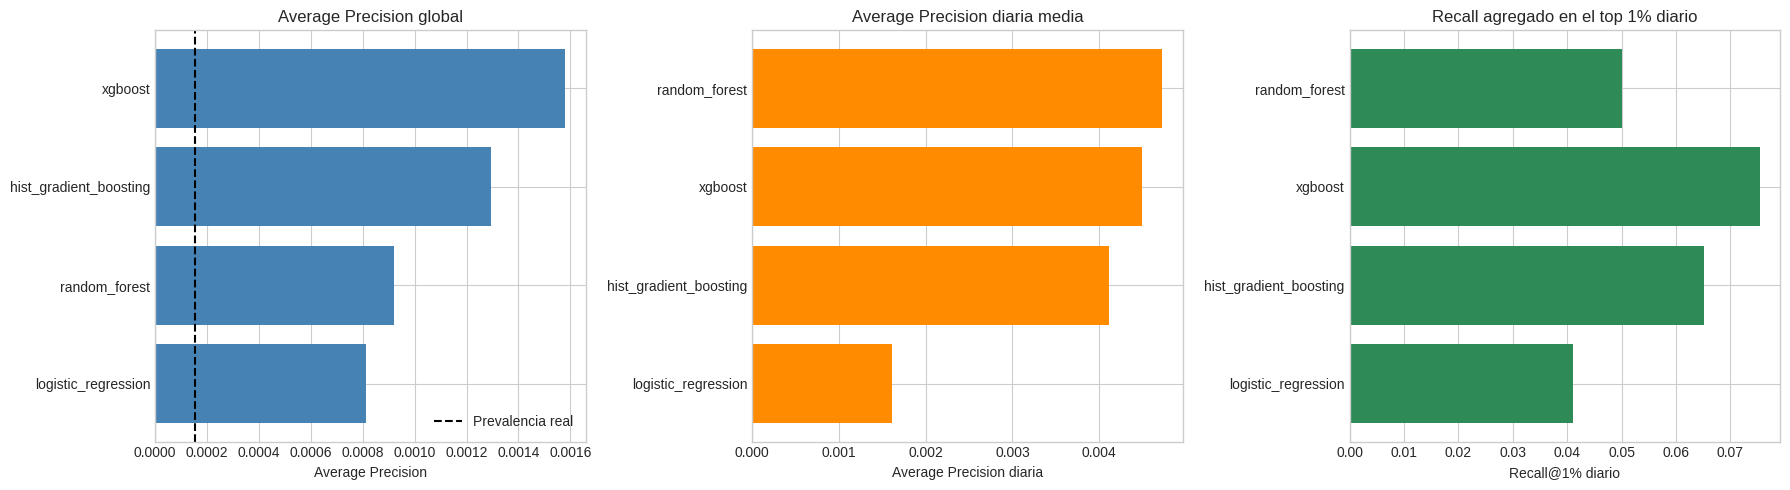


ARCHIVOS GUARDADOS
Resultados globales: /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/05_classical_models/full_validation_2022/classical_models_full_2022_global_results.csv
Resumen diario:      /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/05_classical_models/full_validation_2022/classical_models_full_2022_daily_summary.csv
Resultados diarios:  /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/05_classical_models/full_validation_2022/classical_models_full_2022_daily_results.csv
Scores:              /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/05_classical_models/full_validation_2022/scores
Contrato:            /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/05_classical_models/full_validation_2022/classical_models_full_2022_contract.json
Figura:              /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/figures/classical_models_full_2022_comparison.png

✓ Validación completa de 2022 terminada.
✓ Los scores se han guardado pe

In [13]:
# =============================================================================
# VALIDACIÓN COMPLETA DE LOS MODELOS CLÁSICOS SOBRE 2022
# =============================================================================

import gc
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import average_precision_score, roc_auc_score


# -----------------------------------------------------------------------------
# 1. Rutas
# -----------------------------------------------------------------------------

FINAL_ROOT = Path(
    "/content/drive/MyDrive/TFM/ModelingResults/FinalNotebook"
)

BASELINE_DIR = FINAL_ROOT / "04_baselines"
CLASSICAL_DIR = FINAL_ROOT / "05_classical_models"
MODEL_DIR = CLASSICAL_DIR / "models"
FULL_VALIDATION_DIR = CLASSICAL_DIR / "full_validation_2022"
SCORES_DIR = FULL_VALIDATION_DIR / "scores"
FIGURE_DIR = FINAL_ROOT / "figures"

FULL_VALIDATION_DIR.mkdir(parents=True, exist_ok=True)
SCORES_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MEMMAP_PATH = Path(
    "/content/validation_2022_compact_36_float32.dat"
)


# -----------------------------------------------------------------------------
# 2. Comprobaciones
# -----------------------------------------------------------------------------

if "datacube" not in globals():
    raise RuntimeError(
        "El datacubo no está abierto. Ejecuta primero la celda "
        "de recuperación del entorno."
    )

if "SELECTED_FEATURES" not in globals():
    raise RuntimeError(
        "No se encuentra SELECTED_FEATURES."
    )

if len(SELECTED_FEATURES) != 36:
    raise ValueError(
        f"Se esperaban 36 variables y se encontraron "
        f"{len(SELECTED_FEATURES)}."
    )

VALIDATION_START = "2022-01-01"
VALIDATION_END = "2022-12-31"

validation_cube = datacube.sel(
    time=slice(VALIDATION_START, VALIDATION_END)
)

validation_dates = pd.DatetimeIndex(
    validation_cube["time"].values
)

galicia_mask = (
    datacube["is_galicia"]
    .transpose("y", "x")
    .values
    .astype(bool)
)

number_of_days = len(validation_dates)
number_of_cells = int(galicia_mask.sum())
number_of_cases = number_of_days * number_of_cells
number_of_features = len(SELECTED_FEATURES)

if number_of_days != 365:
    raise ValueError(
        f"Se esperaban 365 días de 2022 y se encontraron "
        f"{number_of_days}."
    )

print("=" * 80)
print("VALIDACIÓN COMPLETA DE MODELOS CLÁSICOS — 2022")
print("=" * 80)

print(
    f"Periodo:              "
    f"{validation_dates.min().date()} → "
    f"{validation_dates.max().date()}"
)
print(f"Días:                 {number_of_days:,}")
print(f"Celdas de Galicia:    {number_of_cells:,}")
print(f"Casos:                {number_of_cases:,}")
print(f"Variables:            {number_of_features}")
print(
    f"Tamaño de la matriz: "
    f"{number_of_cases * number_of_features * 4 / 1024**3:.2f} GB"
)


# -----------------------------------------------------------------------------
# 3. Clasificación de variables
# -----------------------------------------------------------------------------

static_features = [
    feature
    for feature in SELECTED_FEATURES
    if "time" not in datacube[feature].dims
]

dynamic_features = [
    feature
    for feature in SELECTED_FEATURES
    if "time" in datacube[feature].dims
]

print("\nVariables estáticas:", len(static_features))
print("Variables dinámicas:", len(dynamic_features))


# -----------------------------------------------------------------------------
# 4. Construcción de la matriz completa mediante memmap
# -----------------------------------------------------------------------------

print("\nCreando matriz completa de 2022...")
matrix_start_time = time.time()

X_validation_full = np.memmap(
    MEMMAP_PATH,
    dtype=np.float32,
    mode="w+",
    shape=(number_of_cases, number_of_features),
)

feature_positions = {
    feature: position
    for position, feature in enumerate(SELECTED_FEATURES)
}


# Variables estáticas
print("\nEscribiendo variables estáticas...")

static_matrix = np.column_stack([
    datacube[feature]
    .transpose("y", "x")
    .values[galicia_mask]
    .astype(np.float32)
    for feature in static_features
])

static_positions = [
    feature_positions[feature]
    for feature in static_features
]

for day_index in range(number_of_days):
    start = day_index * number_of_cells
    end = start + number_of_cells

    X_validation_full[
        start:end,
        static_positions
    ] = static_matrix

print(f"✓ {len(static_features)} variables estáticas escritas")


# Variables dinámicas
print("\nEscribiendo variables dinámicas...")

for feature_number, feature in enumerate(
    dynamic_features,
    start=1,
):
    start_time = time.time()

    values = (
        validation_cube[feature]
        .transpose("time", "y", "x")
        .values[:, galicia_mask]
        .astype(np.float32)
    )

    X_validation_full[
        :,
        feature_positions[feature]
    ] = values.reshape(-1)

    del values
    gc.collect()

    elapsed = time.time() - start_time

    print(
        f"[{feature_number:2d}/{len(dynamic_features)}] "
        f"{feature:40s} {elapsed:6.1f} s"
    )

X_validation_full.flush()

matrix_seconds = time.time() - matrix_start_time

print(
    f"\n✓ Matriz terminada en "
    f"{matrix_seconds / 60:.2f} minutos."
)


# -----------------------------------------------------------------------------
# 5. Target completo de 2022
# -----------------------------------------------------------------------------

print("\nExtrayendo target completo...")

y_validation_full_matrix = (
    validation_cube["target_ignicion"]
    .transpose("time", "y", "x")
    .values[:, galicia_mask]
    .astype(np.uint8)
)

y_validation_full = y_validation_full_matrix.reshape(-1)

number_of_positives = int(y_validation_full.sum())
full_prevalence = float(y_validation_full.mean())

print(f"Forma de la matriz:   {X_validation_full.shape}")
print(f"Positivos:            {number_of_positives:,}")
print(f"Negativos:            {number_of_cases-number_of_positives:,}")
print(f"Prevalencia real:     {full_prevalence:.8%}")

if number_of_positives != 1659:
    raise ValueError(
        f"Se esperaban 1.659 positivos y se encontraron "
        f"{number_of_positives:,}."
    )


# -----------------------------------------------------------------------------
# 6. Carga de los modelos
# -----------------------------------------------------------------------------

model_paths = {
    "logistic_regression": (
        BASELINE_DIR
        / "logistic_regression_compact_36.joblib"
    ),
    "random_forest": (
        MODEL_DIR
        / "random_forest_compact_36.joblib"
    ),
    "hist_gradient_boosting": (
        MODEL_DIR
        / "hist_gradient_boosting_compact_36.joblib"
    ),
    "xgboost": (
        MODEL_DIR
        / "xgboost_compact_36.joblib"
    ),
}

for model_name, model_path in model_paths.items():
    if not model_path.exists():
        raise FileNotFoundError(
            f"No se encontró el modelo {model_name}:\n"
            f"{model_path}"
        )

models = {
    model_name: joblib.load(model_path)
    for model_name, model_path in model_paths.items()
}

print("\nModelos cargados:")
for model_name in models:
    print(f"  ✓ {model_name}")


# -----------------------------------------------------------------------------
# 7. Predicción por bloques
# -----------------------------------------------------------------------------

PREDICTION_BATCH_SIZE = 250_000

full_scores = {}
prediction_times = {}

print("\n" + "=" * 80)
print("GENERACIÓN DE PREDICCIONES")
print("=" * 80)

for model_name, model in models.items():
    print(f"\nModelo: {model_name}")

    scores = np.empty(
        number_of_cases,
        dtype=np.float32,
    )

    prediction_start_time = time.time()

    for start in range(
        0,
        number_of_cases,
        PREDICTION_BATCH_SIZE,
    ):
        end = min(
            start + PREDICTION_BATCH_SIZE,
            number_of_cases,
        )

        scores[start:end] = model.predict_proba(
            X_validation_full[start:end]
        )[:, 1].astype(np.float32)

        if (
            end == number_of_cases
            or end % 1_000_000 < PREDICTION_BATCH_SIZE
        ):
            print(
                f"  {end:>10,}/{number_of_cases:,} casos"
            )

    prediction_seconds = (
        time.time() - prediction_start_time
    )

    prediction_times[model_name] = prediction_seconds
    full_scores[model_name] = scores

    score_path = (
        SCORES_DIR
        / f"{model_name}_2022_full_scores.npy"
    )

    np.save(score_path, scores)

    print(
        f"✓ Predicción terminada en "
        f"{prediction_seconds:.1f} s"
    )
    print(f"✓ Scores guardados en {score_path}")


# -----------------------------------------------------------------------------
# 8. Métricas globales
# -----------------------------------------------------------------------------

def top_fraction_metrics_full(y_true, scores, fraction):
    number_selected = max(
        1,
        int(np.floor(len(y_true) * fraction)),
    )

    selected_indices = np.argpartition(
        scores,
        -number_selected,
    )[-number_selected:]

    positive_cases = int(
        y_true[selected_indices].sum()
    )

    return {
        "selected_cases": number_selected,
        "positive_cases": positive_cases,
        "recall": positive_cases / y_true.sum(),
        "precision": positive_cases / number_selected,
    }


global_results = []

for model_name, scores in full_scores.items():
    result = {
        "model": model_name,
        "number_of_features": number_of_features,
        "average_precision_full": (
            average_precision_score(
                y_validation_full,
                scores,
            )
        ),
        "roc_auc_full": roc_auc_score(
            y_validation_full,
            scores,
        ),
        "prediction_seconds": prediction_times[model_name],
    }

    result["ap_lift_over_random"] = (
        result["average_precision_full"]
        / full_prevalence
    )

    for label, fraction in [
        ("0_1pct", 0.001),
        ("1pct", 0.01),
        ("5pct", 0.05),
    ]:
        metrics = top_fraction_metrics_full(
            y_validation_full,
            scores,
            fraction,
        )

        result[f"recall_at_{label}"] = metrics["recall"]
        result[f"precision_at_{label}"] = metrics["precision"]
        result[f"positives_at_{label}"] = (
            metrics["positive_cases"]
        )
        result[f"selected_at_{label}"] = (
            metrics["selected_cases"]
        )

    global_results.append(result)

global_results = pd.DataFrame(global_results)

global_results = global_results.sort_values(
    "average_precision_full",
    ascending=False,
).reset_index(drop=True)

global_results.insert(
    0,
    "rank_by_global_average_precision",
    np.arange(1, len(global_results) + 1),
)


# -----------------------------------------------------------------------------
# 9. Métricas con ranking independiente cada día
# -----------------------------------------------------------------------------

DAILY_FRACTIONS = {
    "0_1pct": 0.001,
    "1pct": 0.01,
    "5pct": 0.05,
}

positive_days = (
    y_validation_full_matrix.sum(axis=1) > 0
)

number_of_positive_days = int(positive_days.sum())

daily_rows = []
daily_summary_rows = []

for model_name, scores in full_scores.items():
    score_matrix = scores.reshape(
        number_of_days,
        number_of_cells,
    )

    total_hits = {
        label: 0 for label in DAILY_FRACTIONS
    }

    detected_positive_days = {
        label: 0 for label in DAILY_FRACTIONS
    }

    daily_ap_values = []

    for day_index, date in enumerate(validation_dates):
        y_day = y_validation_full_matrix[day_index]
        scores_day = score_matrix[day_index]

        positives_day = int(y_day.sum())

        if positives_day > 0:
            daily_ap = average_precision_score(
                y_day,
                scores_day,
            )
            daily_ap_values.append(daily_ap)
        else:
            daily_ap = np.nan

        day_result = {
            "date": date.strftime("%Y-%m-%d"),
            "model": model_name,
            "positive_cells": positives_day,
            "daily_average_precision": daily_ap,
        }

        for label, fraction in DAILY_FRACTIONS.items():
            number_selected = max(
                1,
                int(np.floor(number_of_cells * fraction)),
            )

            selected_indices = np.argpartition(
                scores_day,
                -number_selected,
            )[-number_selected:]

            hits = int(y_day[selected_indices].sum())

            total_hits[label] += hits

            if positives_day > 0 and hits > 0:
                detected_positive_days[label] += 1

            day_result[f"hits_at_{label}"] = hits
            day_result[f"selected_at_{label}"] = number_selected

            day_result[f"recall_at_{label}"] = (
                hits / positives_day
                if positives_day > 0
                else np.nan
            )

            day_result[f"precision_at_{label}"] = (
                hits / number_selected
            )

        daily_rows.append(day_result)

    mean_daily_ap = float(
        np.mean(daily_ap_values)
    )

    median_daily_ap = float(
        np.median(daily_ap_values)
    )

    random_daily_ap_reference = float(
        np.mean(
            y_validation_full_matrix[
                positive_days
            ].mean(axis=1)
        )
    )

    summary = {
        "model": model_name,
        "mean_daily_ap_positive_days": mean_daily_ap,
        "median_daily_ap_positive_days": median_daily_ap,
        "mean_daily_ap_lift": (
            mean_daily_ap
            / random_daily_ap_reference
        ),
        "number_of_positive_days": number_of_positive_days,
    }

    for label, fraction in DAILY_FRACTIONS.items():
        selected_per_day = max(
            1,
            int(np.floor(number_of_cells * fraction)),
        )

        summary[f"pooled_recall_at_{label}"] = (
            total_hits[label] / number_of_positives
        )

        summary[f"precision_at_{label}"] = (
            total_hits[label]
            / (selected_per_day * number_of_days)
        )

        summary[
            f"positive_days_detected_at_{label}"
        ] = (
            detected_positive_days[label]
            / number_of_positive_days
        )

        summary[f"positives_at_{label}"] = (
            total_hits[label]
        )

    daily_summary_rows.append(summary)

daily_results = pd.DataFrame(daily_rows)
daily_summary = pd.DataFrame(daily_summary_rows)

daily_summary = daily_summary.sort_values(
    "mean_daily_ap_positive_days",
    ascending=False,
).reset_index(drop=True)

daily_summary.insert(
    0,
    "rank_by_mean_daily_ap",
    np.arange(1, len(daily_summary) + 1),
)


# -----------------------------------------------------------------------------
# 10. Presentación de resultados
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("RESULTADOS GLOBALES SOBRE 2022 COMPLETO")
print("=" * 80)

global_display = global_results.copy()

global_display["average_precision_full"] = (
    global_display["average_precision_full"]
    .map(lambda value: f"{value:.6f}")
)

global_display["ap_lift_over_random"] = (
    global_display["ap_lift_over_random"]
    .map(lambda value: f"{value:.2f}×")
)

global_display["roc_auc_full"] = (
    global_display["roc_auc_full"]
    .map(lambda value: f"{value:.4f}")
)

for column in [
    "recall_at_0_1pct",
    "precision_at_0_1pct",
    "recall_at_1pct",
    "precision_at_1pct",
    "recall_at_5pct",
    "precision_at_5pct",
]:
    global_display[column] = (
        global_display[column]
        .map(lambda value: f"{value:.2%}")
    )

display(global_display)


print("\n" + "=" * 80)
print("RESULTADOS CON RANKING INDEPENDIENTE CADA DÍA")
print("=" * 80)

daily_display = daily_summary.copy()

daily_display["mean_daily_ap_positive_days"] = (
    daily_display["mean_daily_ap_positive_days"]
    .map(lambda value: f"{value:.6f}")
)

daily_display["median_daily_ap_positive_days"] = (
    daily_display["median_daily_ap_positive_days"]
    .map(lambda value: f"{value:.6f}")
)

daily_display["mean_daily_ap_lift"] = (
    daily_display["mean_daily_ap_lift"]
    .map(lambda value: f"{value:.2f}×")
)

for column in daily_display.columns:
    if (
        column.startswith("pooled_recall")
        or column.startswith("precision_at")
        or column.startswith("positive_days_detected")
    ):
        daily_display[column] = (
            daily_display[column]
            .map(lambda value: f"{value:.2%}")
        )

display(daily_display)


# -----------------------------------------------------------------------------
# 11. Guardado permanente
# -----------------------------------------------------------------------------

GLOBAL_RESULTS_PATH = (
    FULL_VALIDATION_DIR
    / "classical_models_full_2022_global_results.csv"
)

DAILY_SUMMARY_PATH = (
    FULL_VALIDATION_DIR
    / "classical_models_full_2022_daily_summary.csv"
)

DAILY_RESULTS_PATH = (
    FULL_VALIDATION_DIR
    / "classical_models_full_2022_daily_results.csv"
)

CONTRACT_PATH = (
    FULL_VALIDATION_DIR
    / "classical_models_full_2022_contract.json"
)

global_results.to_csv(
    GLOBAL_RESULTS_PATH,
    index=False,
)

daily_summary.to_csv(
    DAILY_SUMMARY_PATH,
    index=False,
)

daily_results.to_csv(
    DAILY_RESULTS_PATH,
    index=False,
)

full_validation_contract = {
    "validation_period": "2022-01-01/2022-12-31",
    "test_2023_used": False,
    "number_of_days": number_of_days,
    "number_of_cells_per_day": number_of_cells,
    "number_of_cases": number_of_cases,
    "number_of_positive_cases": number_of_positives,
    "prevalence": full_prevalence,
    "number_of_positive_days": number_of_positive_days,
    "feature_set": "compact_36",
    "number_of_features": number_of_features,
    "features": SELECTED_FEATURES,
    "daily_ranking": True,
    "top_fraction_rounding": "floor",
    "prediction_batch_size": PREDICTION_BATCH_SIZE,
    "models": list(models.keys()),
    "score_files": {
        model_name: str(
            SCORES_DIR
            / f"{model_name}_2022_full_scores.npy"
        )
        for model_name in models
    },
}

with open(
    CONTRACT_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        full_validation_contract,
        file,
        indent=2,
        ensure_ascii=False,
    )


# -----------------------------------------------------------------------------
# 12. Figura comparativa
# -----------------------------------------------------------------------------

global_plot = global_results.sort_values(
    "average_precision_full",
    ascending=True,
)

daily_plot = daily_summary.sort_values(
    "mean_daily_ap_positive_days",
    ascending=True,
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)

axes[0].barh(
    global_plot["model"],
    global_plot["average_precision_full"],
    color="steelblue",
)

axes[0].axvline(
    full_prevalence,
    color="black",
    linestyle="--",
    label="Prevalencia real",
)

axes[0].set_title("Average Precision global")
axes[0].set_xlabel("Average Precision")
axes[0].legend()

axes[1].barh(
    daily_plot["model"],
    daily_plot["mean_daily_ap_positive_days"],
    color="darkorange",
)

axes[1].set_title("Average Precision diaria media")
axes[1].set_xlabel("Average Precision diaria")

axes[2].barh(
    daily_plot["model"],
    daily_plot["pooled_recall_at_1pct"],
    color="seagreen",
)

axes[2].set_title("Recall agregado en el top 1% diario")
axes[2].set_xlabel("Recall@1% diario")

plt.tight_layout()

FIGURE_PATH = (
    FIGURE_DIR
    / "classical_models_full_2022_comparison.png"
)

plt.savefig(
    FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# -----------------------------------------------------------------------------
# 13. Resumen
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("ARCHIVOS GUARDADOS")
print("=" * 80)

print(f"Resultados globales: {GLOBAL_RESULTS_PATH}")
print(f"Resumen diario:      {DAILY_SUMMARY_PATH}")
print(f"Resultados diarios:  {DAILY_RESULTS_PATH}")
print(f"Scores:              {SCORES_DIR}")
print(f"Contrato:            {CONTRACT_PATH}")
print(f"Figura:              {FIGURE_PATH}")

print("\n✓ Validación completa de 2022 terminada.")
print("✓ Los scores se han guardado permanentemente en Drive.")
print("✓ 2023 continúa completamente fuera del análisis.")

## 5.3. Conclusiones de la evaluación completa de 2022

La evaluación completa se realizó sobre 10.804.365 celdas-día, incluyendo 1.659 casos positivos. La prevalencia real fue únicamente del 0,01535491%, lo que confirma el elevado desequilibrio del problema y justifica el uso de Average Precision y métricas de ranking.

### Evaluación global

XGBoost obtuvo el mejor rendimiento global:

- Average Precision: 0,001580.
- Lift sobre el clasificador aleatorio: 10,29.
- ROC-AUC: 0,8676.
- Recall@0,1%: 3,25%.
- Recall@1%: 14,77%.
- Recall@5%: 38,46%.

Esto significa que el modelo identificó 245 de las 1.659 igniciones dentro del 1% de celdas-día con mayor puntuación y 638 dentro del 5%.

HistGradientBoosting obtuvo una Average Precision inferior, de 0,001296, aunque presentó un ROC-AUC prácticamente idéntico y el mayor recall global dentro del top 5%:

- ROC-AUC: 0,8677.
- Recall@1%: 13,62%.
- Recall@5%: 39,60%.

Por tanto, XGBoost concentra mejor los positivos en las primeras posiciones del ranking, mientras que HistGradientBoosting recupera ligeramente más igniciones cuando se amplía el área seleccionada al 5%.

Random Forest y la regresión logística quedaron claramente por debajo:

| Modelo | AP global | Lift | Recall@1% | Recall@5% |
|---|---:|---:|---:|---:|
| XGBoost | 0,001580 | 10,29× | 14,77% | 38,46% |
| HistGradientBoosting | 0,001296 | 8,44× | 13,62% | 39,60% |
| Random Forest | 0,000921 | 6,00× | 9,28% | 31,53% |
| Regresión logística | 0,000813 | 5,30× | 9,04% | 29,29% |

Los resultados completos confirman la ventaja observada en la validación muestreada y respaldan la selección de los algoritmos de boosting como modelos clásicos principales.

### Evaluación con ranking diario

Para representar un uso operativo, también se construyó un ranking independiente para cada uno de los 365 días de 2022.

XGBoost obtuvo el comportamiento más equilibrado:

- AP diaria media: 0,004496.
- AP diaria mediana: 0,001147.
- Recall agregado diario@0,1%: 1,69%.
- Recall agregado diario@1%: 7,53%.
- Recall agregado diario@5%: 22,00%.
- Días positivos detectados en el top 1%: 38,36%.

Dentro del 1% diario de mayor riesgo, correspondiente a unas 296 celdas por jornada, XGBoost identificó 125 igniciones. En el top 5% identificó 365.

Random Forest alcanzó la mayor AP diaria media, con 0,004729, pero presentó una mediana considerablemente menor, de 0,000801. Además, sus recalls diarios fueron inferiores a los de los modelos de boosting. Esto indica que su media está probablemente influida por un número reducido de días con resultados especialmente altos, mientras que su comportamiento habitual es menos estable.

HistGradientBoosting presentó resultados próximos a XGBoost, aunque inferiores en los principales umbrales operativos:

- AP diaria media: 0,004116.
- Recall agregado diario@1%: 6,51%.
- Recall agregado diario@5%: 21,52%.

La regresión logística obtuvo nuevamente el rendimiento más bajo entre los modelos multivariantes, lo que confirma la importancia de las relaciones no lineales.

### Decisión provisional

XGBoost se selecciona como modelo clásico principal porque:

1. obtiene la mayor Average Precision global;
2. presenta el mayor lift sobre la prevalencia real;
3. consigue el mejor recall agregado en el top 0,1% y 1% diario;
4. mantiene un rendimiento diario más estable que Random Forest;
5. ofrece el menor tiempo de predicción entre los modelos basados en árboles evaluados.

HistGradientBoosting se conserva como segundo modelo porque presenta resultados competitivos y podría aportar información complementaria en un ensemble.

Random Forest no se descarta todavía, pero no se considera modelo principal debido a su menor rendimiento operativo, su menor estabilidad diaria y su mayor coste de entrenamiento.

### Estado del experimento

Quedan guardados permanentemente en Drive:

- los cuatro modelos entrenados;
- las predicciones completas de 2022;
- las métricas globales;
- el resumen de métricas diarias;
- los resultados individuales de cada día;
- el contrato experimental;
- las figuras comparativas.

La matriz completa de predictores almacenada temporalmente en `/content` no necesita conservarse, ya que puede reconstruirse a partir del datacubo definitivo.

El periodo de 2023 continúa completamente fuera del análisis.

### Próximo paso

La siguiente sesión comenzará con la sección 6, dedicada a las redes neuronales. Primero se prepararán los tensores normalizados con las 36 variables seleccionadas y después se entrenará una CNN espacial 2D. Posteriormente se estudiará una arquitectura espaciotemporal que utilice ventanas de varios días.

## Mapas complementarios de riesgo sobre 2022

Como material gráfico adicional se representan los tres días de 2022 con mayor número de celdas con ignición.

Para cada día se muestran:

1. las igniciones observadas;
2. las zonas de prioridad estimadas por XGBoost;
3. las zonas de prioridad estimadas por HistGradientBoosting.

Las puntuaciones de los modelos no se interpretan como probabilidades calibradas. Por esta razón, los mapas utilizan percentiles calculados independientemente para cada día:

- prioridad moderada: top 10–5%;
- prioridad alta: top 5–1%;
- prioridad muy alta: top 1–0,1%;
- prioridad extrema: top 0,1%.

Esta representación muestra qué zonas del territorio serían priorizadas diariamente bajo distintos niveles de capacidad operativa.

MAPAS COMPLEMENTARIOS DE RIESGO

Días seleccionados:
  2022-07-14: 55 igniciones
  2022-07-15: 42 igniciones
  2022-08-10: 29 igniciones


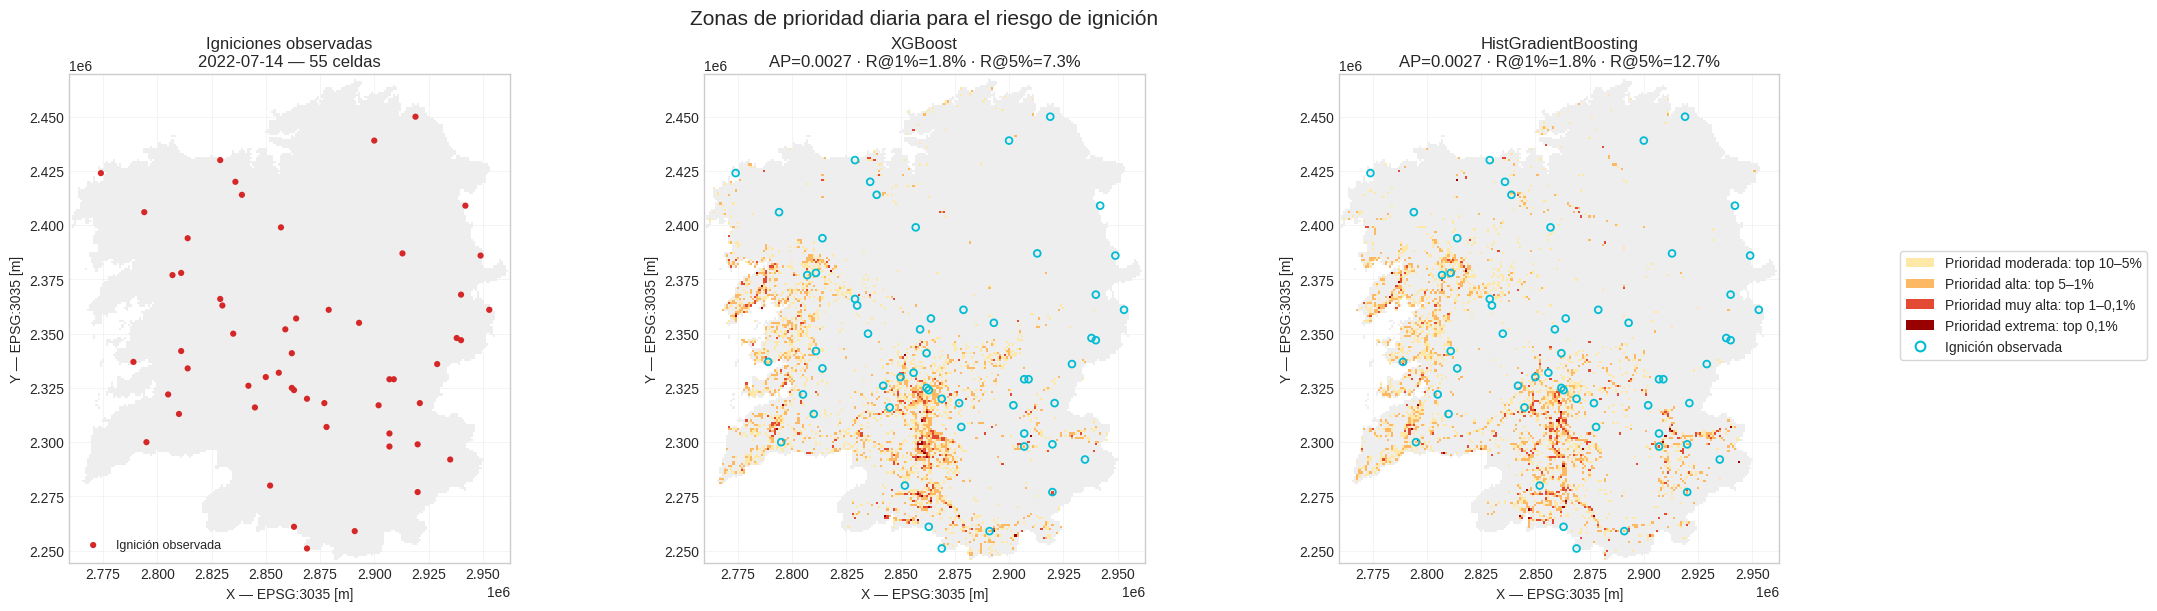

✓ Mapa guardado: /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/05_classical_models/full_validation_2022/risk_maps/classical_risk_map_2022-07-14.png


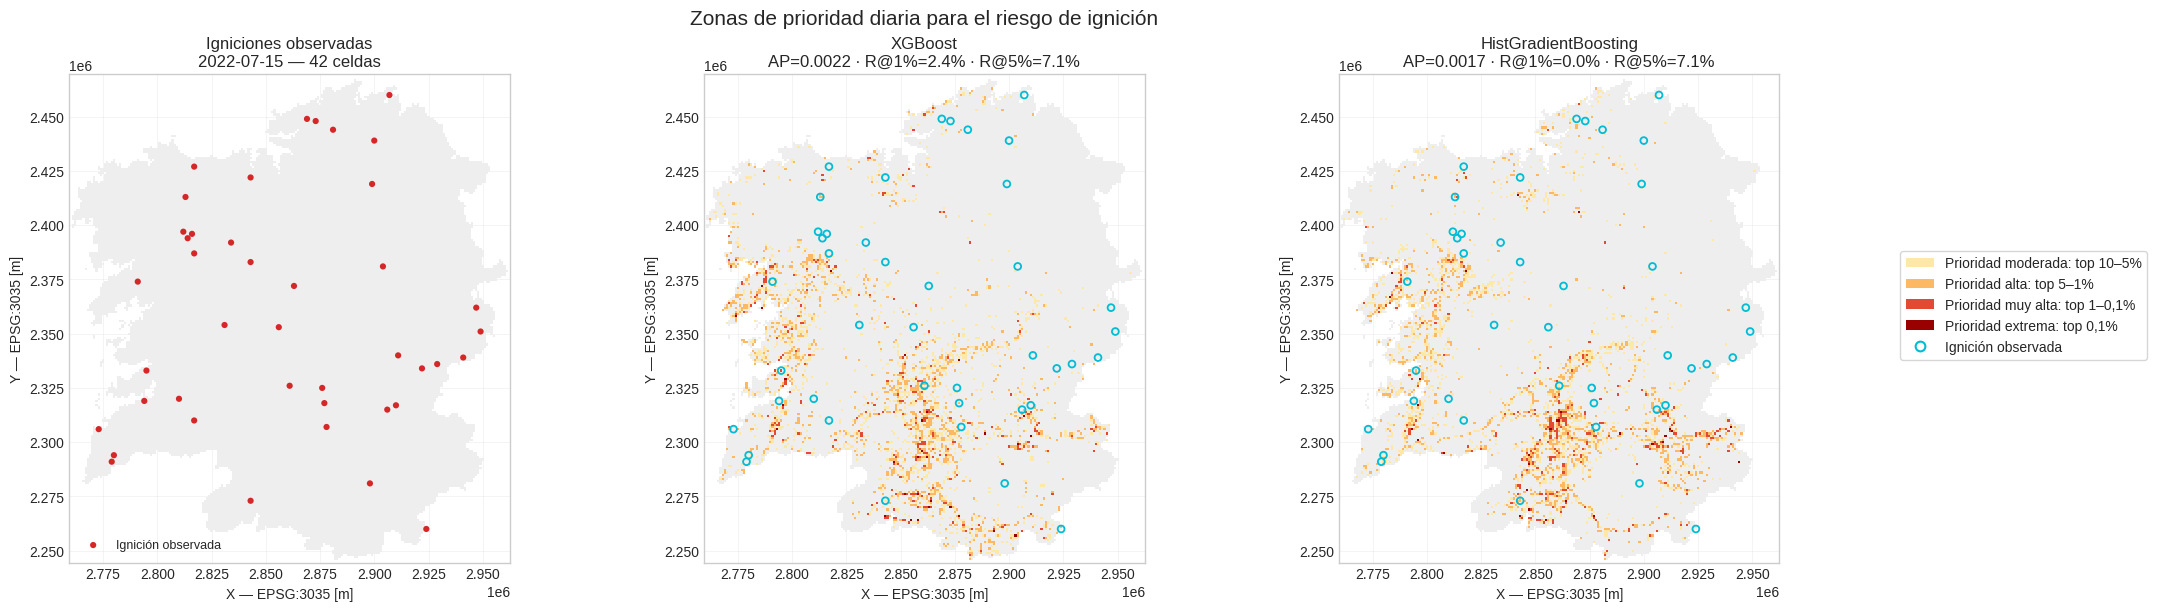

✓ Mapa guardado: /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/05_classical_models/full_validation_2022/risk_maps/classical_risk_map_2022-07-15.png


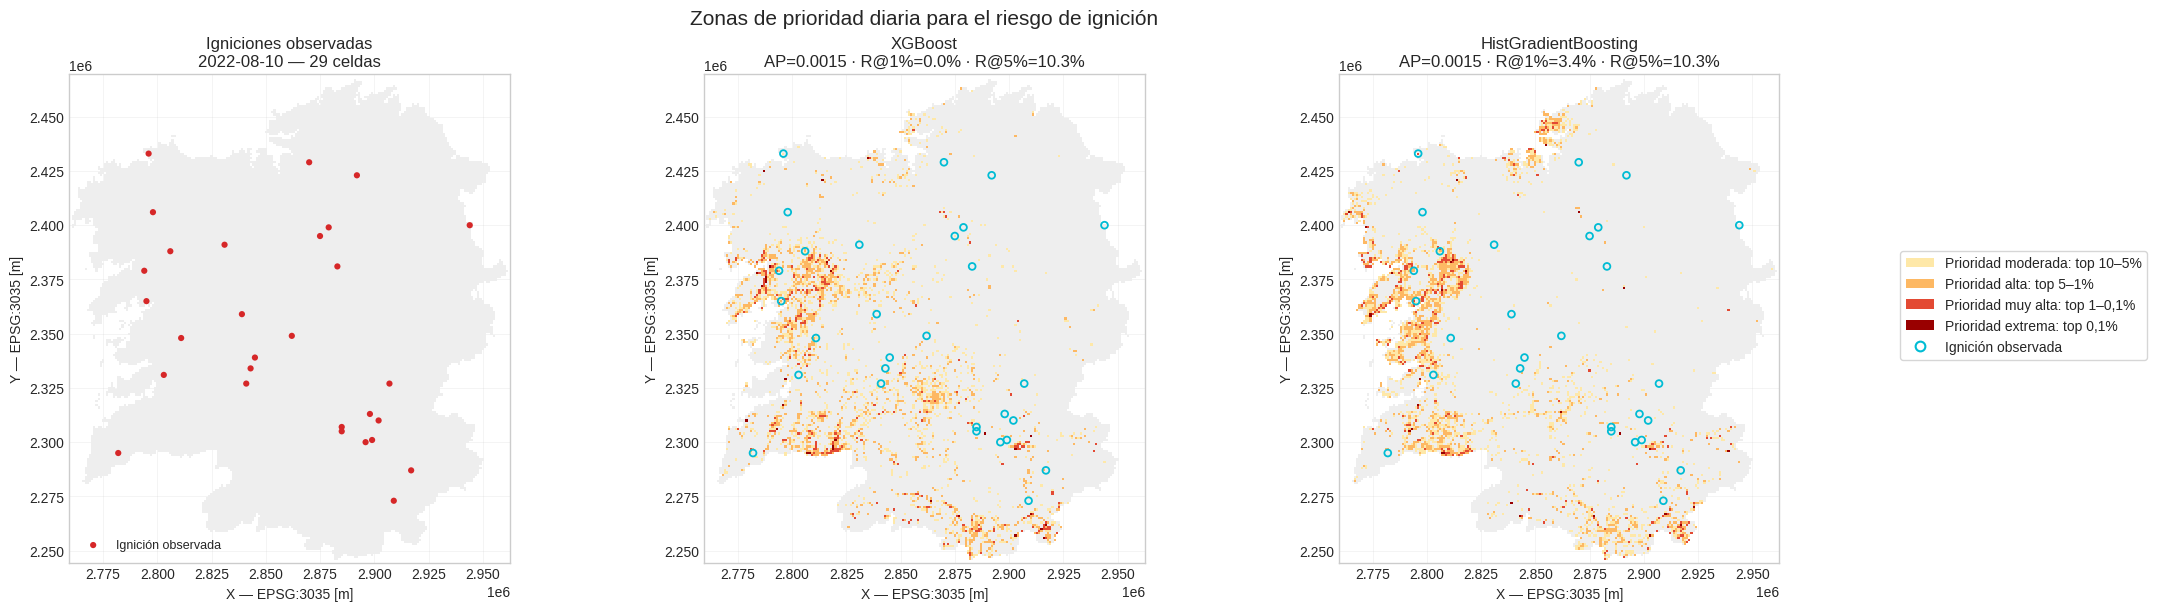

✓ Mapa guardado: /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/05_classical_models/full_validation_2022/risk_maps/classical_risk_map_2022-08-10.png

RESUMEN DE LOS DÍAS REPRESENTADOS


,date,model,observed_ignitions,daily_average_precision,hits_at_1pct,recall_at_1pct,precision_at_1pct,hits_at_5pct,recall_at_5pct,precision_at_5pct
0,2022-07-14,XGBoost,55,0.0027,1,1.82%,0.34%,4,7.27%,0.27%
1,2022-07-14,HistGradientBoosting,55,0.0027,1,1.82%,0.34%,7,12.73%,0.47%
2,2022-07-15,XGBoost,42,0.0022,1,2.38%,0.34%,3,7.14%,0.20%
3,2022-07-15,HistGradientBoosting,42,0.0017,0,0.00%,0.00%,3,7.14%,0.20%
4,2022-08-10,XGBoost,29,0.0015,0,0.00%,0.00%,3,10.34%,0.20%
5,2022-08-10,HistGradientBoosting,29,0.0015,1,3.45%,0.34%,3,10.34%,0.20%



Archivos guardados:
  Mapas:   /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/05_classical_models/full_validation_2022/risk_maps
  Resumen: /content/drive/MyDrive/TFM/ModelingResults/FinalNotebook/05_classical_models/full_validation_2022/risk_maps/classical_risk_maps_high_activity_summary.csv

✓ Mapas de riesgo guardados permanentemente en Drive.
✓ Se han utilizado únicamente datos de validación de 2022.
✓ 2023 continúa completamente fuera del análisis.


In [14]:
# =============================================================================
# MAPAS COMPLEMENTARIOS DE RIESGO — MODELOS CLÁSICOS
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.metrics import average_precision_score


# -----------------------------------------------------------------------------
# 1. Rutas
# -----------------------------------------------------------------------------

FINAL_ROOT = Path(
    "/content/drive/MyDrive/TFM/ModelingResults/FinalNotebook"
)

FULL_VALIDATION_DIR = (
    FINAL_ROOT
    / "05_classical_models"
    / "full_validation_2022"
)

SCORES_DIR = FULL_VALIDATION_DIR / "scores"
MAP_DIR = FULL_VALIDATION_DIR / "risk_maps"

MAP_DIR.mkdir(parents=True, exist_ok=True)

XGB_SCORES_PATH = (
    SCORES_DIR / "xgboost_2022_full_scores.npy"
)

HGB_SCORES_PATH = (
    SCORES_DIR
    / "hist_gradient_boosting_2022_full_scores.npy"
)


# -----------------------------------------------------------------------------
# 2. Comprobaciones y carga
# -----------------------------------------------------------------------------

if "datacube" not in globals():
    raise RuntimeError(
        "El datacubo no está abierto."
    )

for path in [XGB_SCORES_PATH, HGB_SCORES_PATH]:
    if not path.exists():
        raise FileNotFoundError(
            f"No se encontró el archivo:\n{path}"
        )

validation_cube = datacube.sel(
    time=slice("2022-01-01", "2022-12-31")
)

validation_dates = pd.DatetimeIndex(
    validation_cube["time"].values
)

galicia_mask = (
    datacube["is_galicia"]
    .transpose("y", "x")
    .values
    .astype(bool)
)

x_coordinates = datacube["x"].values
y_coordinates = datacube["y"].values

x_grid, y_grid = np.meshgrid(
    x_coordinates,
    y_coordinates,
)

number_of_days = len(validation_dates)
number_of_cells = int(galicia_mask.sum())

target_matrix = (
    validation_cube["target_ignicion"]
    .transpose("time", "y", "x")
    .values[:, galicia_mask]
    .astype(np.uint8)
)

xgb_scores = np.load(
    XGB_SCORES_PATH,
    mmap_mode="r",
).reshape(number_of_days, number_of_cells)

hgb_scores = np.load(
    HGB_SCORES_PATH,
    mmap_mode="r",
).reshape(number_of_days, number_of_cells)

if xgb_scores.shape != target_matrix.shape:
    raise ValueError(
        "La forma de los scores de XGBoost no coincide "
        "con el target."
    )

if hgb_scores.shape != target_matrix.shape:
    raise ValueError(
        "La forma de los scores de HGB no coincide "
        "con el target."
    )


# -----------------------------------------------------------------------------
# 3. Selección de los tres días con más igniciones
# -----------------------------------------------------------------------------

daily_positive_cells = target_matrix.sum(axis=1)

top_day_indices = np.argsort(
    daily_positive_cells
)[-3:][::-1]

selected_dates = validation_dates[top_day_indices]

print("=" * 80)
print("MAPAS COMPLEMENTARIOS DE RIESGO")
print("=" * 80)

print("\nDías seleccionados:")

for day_index in top_day_indices:
    print(
        f"  {validation_dates[day_index].date()}: "
        f"{int(daily_positive_cells[day_index])} igniciones"
    )


# -----------------------------------------------------------------------------
# 4. Funciones auxiliares
# -----------------------------------------------------------------------------

def daily_percentiles(scores):
    """
    Transforma las puntuaciones de un día en percentiles.
    El valor 100 corresponde a la mayor puntuación.
    """
    scores = np.asarray(scores)

    order = np.argsort(scores)

    ranks = np.empty(
        len(scores),
        dtype=np.int32,
    )

    ranks[order] = np.arange(
        1,
        len(scores) + 1,
    )

    return (
        100.0 * ranks / len(scores)
    )


def priority_categories(percentiles):
    """
    Convierte los percentiles en categorías operativas.
    """
    categories = np.zeros(
        len(percentiles),
        dtype=np.uint8,
    )

    categories[percentiles >= 90.0] = 1
    categories[percentiles >= 95.0] = 2
    categories[percentiles >= 99.0] = 3
    categories[percentiles >= 99.9] = 4

    return categories


def vector_to_grid(values):
    """
    Reconstruye una variable vectorial sobre la rejilla de Galicia.
    """
    grid = np.full(
        galicia_mask.shape,
        np.nan,
        dtype=np.float32,
    )

    grid[galicia_mask] = values

    return grid


def calculate_daily_hits(y_true, scores, fraction):
    """
    Calcula aciertos y recall en una fracción superior del ranking.
    """
    number_selected = max(
        1,
        int(np.floor(len(scores) * fraction)),
    )

    selected_indices = np.argpartition(
        scores,
        -number_selected,
    )[-number_selected:]

    hits = int(y_true[selected_indices].sum())

    recall = (
        hits / y_true.sum()
        if y_true.sum() > 0
        else np.nan
    )

    precision = hits / number_selected

    return number_selected, hits, recall, precision


# -----------------------------------------------------------------------------
# 5. Configuración gráfica
# -----------------------------------------------------------------------------

priority_colors = [
    "#eeeeee",  # Resto del territorio
    "#fee8a8",  # Top 10–5%
    "#fdb863",  # Top 5–1%
    "#e34a33",  # Top 1–0,1%
    "#990000",  # Top 0,1%
]

priority_cmap = ListedColormap(priority_colors)

priority_norm = BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5],
    priority_cmap.N,
)

legend_elements = [
    Patch(
        facecolor=priority_colors[1],
        label="Prioridad moderada: top 10–5%",
    ),
    Patch(
        facecolor=priority_colors[2],
        label="Prioridad alta: top 5–1%",
    ),
    Patch(
        facecolor=priority_colors[3],
        label="Prioridad muy alta: top 1–0,1%",
    ),
    Patch(
        facecolor=priority_colors[4],
        label="Prioridad extrema: top 0,1%",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="none",
        markeredgecolor="#00bcd4",
        markeredgewidth=1.5,
        markersize=7,
        label="Ignición observada",
    ),
]


# -----------------------------------------------------------------------------
# 6. Creación de los mapas
# -----------------------------------------------------------------------------

map_summary_rows = []

model_scores = {
    "XGBoost": xgb_scores,
    "HistGradientBoosting": hgb_scores,
}

for day_index in top_day_indices:
    selected_date = validation_dates[day_index]
    date_string = selected_date.strftime("%Y-%m-%d")

    y_day = target_matrix[day_index]
    number_of_ignitions = int(y_day.sum())

    observed_grid = vector_to_grid(y_day)

    observed_locations = observed_grid == 1

    figure, axes = plt.subplots(
        1,
        3,
        figsize=(19, 6),
        constrained_layout=True,
    )

    # -------------------------------------------------------------------------
    # Mapa de observaciones
    # -------------------------------------------------------------------------

    galicia_background = np.full(
        galicia_mask.shape,
        np.nan,
        dtype=np.float32,
    )

    galicia_background[galicia_mask] = 1

    axes[0].pcolormesh(
        x_coordinates,
        y_coordinates,
        galicia_background,
        shading="auto",
        cmap=ListedColormap(["#eeeeee"]),
    )

    axes[0].scatter(
        x_grid[observed_locations],
        y_grid[observed_locations],
        s=20,
        c="#d62728",
        edgecolors="none",
        label="Ignición observada",
        zorder=3,
    )

    axes[0].set_title(
        "Igniciones observadas\n"
        f"{date_string} — {number_of_ignitions} celdas"
    )

    axes[0].legend(
        loc="lower left",
        fontsize=9,
    )

    # -------------------------------------------------------------------------
    # Mapas de riesgo
    # -------------------------------------------------------------------------

    for axis, (model_name, scores_matrix) in zip(
        axes[1:],
        model_scores.items(),
    ):
        scores_day = np.asarray(
            scores_matrix[day_index]
        )

        percentiles = daily_percentiles(
            scores_day
        )

        categories = priority_categories(
            percentiles
        )

        category_grid = vector_to_grid(
            categories
        )

        axis.pcolormesh(
            x_coordinates,
            y_coordinates,
            category_grid,
            shading="auto",
            cmap=priority_cmap,
            norm=priority_norm,
        )

        axis.scatter(
            x_grid[observed_locations],
            y_grid[observed_locations],
            s=24,
            facecolors="none",
            edgecolors="#00bcd4",
            linewidths=1.3,
            zorder=3,
        )

        daily_ap = average_precision_score(
            y_day,
            scores_day,
        )

        _, hits_1pct, recall_1pct, precision_1pct = (
            calculate_daily_hits(
                y_day,
                scores_day,
                0.01,
            )
        )

        _, hits_5pct, recall_5pct, precision_5pct = (
            calculate_daily_hits(
                y_day,
                scores_day,
                0.05,
            )
        )

        axis.set_title(
            f"{model_name}\n"
            f"AP={daily_ap:.4f} · "
            f"R@1%={recall_1pct:.1%} · "
            f"R@5%={recall_5pct:.1%}"
        )

        map_summary_rows.append({
            "date": date_string,
            "model": model_name,
            "observed_ignitions": number_of_ignitions,
            "daily_average_precision": daily_ap,
            "hits_at_1pct": hits_1pct,
            "recall_at_1pct": recall_1pct,
            "precision_at_1pct": precision_1pct,
            "hits_at_5pct": hits_5pct,
            "recall_at_5pct": recall_5pct,
            "precision_at_5pct": precision_5pct,
        })

    # -------------------------------------------------------------------------
    # Formato común
    # -------------------------------------------------------------------------

    for axis in axes:
        axis.set_aspect("equal")
        axis.set_xlabel("X — EPSG:3035 [m]")
        axis.set_ylabel("Y — EPSG:3035 [m]")
        axis.grid(
            alpha=0.25,
            linewidth=0.6,
        )

    figure.legend(
        handles=legend_elements,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=True,
    )

    figure.suptitle(
        "Zonas de prioridad diaria para el riesgo de ignición",
        fontsize=15,
    )

    map_path = (
        MAP_DIR
        / f"classical_risk_map_{date_string}.png"
    )

    figure.savefig(
        map_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    print(f"✓ Mapa guardado: {map_path}")


# -----------------------------------------------------------------------------
# 7. Tabla resumen
# -----------------------------------------------------------------------------

map_summary = pd.DataFrame(map_summary_rows)

SUMMARY_PATH = (
    MAP_DIR
    / "classical_risk_maps_high_activity_summary.csv"
)

map_summary.to_csv(
    SUMMARY_PATH,
    index=False,
)

print("\n" + "=" * 80)
print("RESUMEN DE LOS DÍAS REPRESENTADOS")
print("=" * 80)

display_summary = map_summary.copy()

display_summary["daily_average_precision"] = (
    display_summary["daily_average_precision"]
    .map(lambda value: f"{value:.4f}")
)

for column in [
    "recall_at_1pct",
    "precision_at_1pct",
    "recall_at_5pct",
    "precision_at_5pct",
]:
    display_summary[column] = (
        display_summary[column]
        .map(lambda value: f"{value:.2%}")
    )

display(display_summary)

print("\nArchivos guardados:")
print(f"  Mapas:   {MAP_DIR}")
print(f"  Resumen: {SUMMARY_PATH}")

print("\n✓ Mapas de riesgo guardados permanentemente en Drive.")
print("✓ Se han utilizado únicamente datos de validación de 2022.")
print("✓ 2023 continúa completamente fuera del análisis.")